In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import matplotlib
%matplotlib inline
import seaborn as sns
import missingno as msno
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [2]:
!pip install missingno

### 결측치 점검

In [3]:
df_raw = pd.read_csv("C:\\Users\\user\\Desktop\\0822_H_data.csv")

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14956 entries, 0 to 14955
Columns: 254 entries, id to hm_01_rel_t
dtypes: float64(178), int64(74), object(2)
memory usage: 29.0+ MB


In [4]:
df = df_raw.drop(['emp_keep_a', 'hazard_phy_d','hazard_phy_a','hazard_phy_c','hazard_phy_e','hazard_phy_f','hazard_phy_g','hazard_phy_h', 'hazard_phy_i', 'ch_downsizing', 'job_c1_r', 'job_c1', 'emp_pay_type', 'skillmat', 'emp_comp_com_a','emp_comp_com_b','emp_comp_com_c','ch_ic','ch_restruct','wplace_sl','emp_noncon', 'wcomback'], axis = 1)

In [5]:
# 널값 개수와 비율 계산
null_summary = (
    df.isnull().sum()
      .to_frame("널값 개수")
      .assign(널값비율 = lambda x: (x["널값 개수"] / len(df_raw) * 100).round(2))
      .reset_index()
      .rename(columns={'index': '컬럼명'})
)

# 널값 있는 열만 필터링 & 비율 기준 내림차순 정렬
null_summary = (
    null_summary[null_summary["널값 개수"] > 0]
    .sort_values(by="널값비율", ascending=False)
    .reset_index(drop=True)
)

print(null_summary)

                  컬럼명  널값 개수  널값비율
0         comp_size_b    870  5.82
1        wtime_ftwork    584  3.90
2            emp_keep    581  3.88
3          emo_manual    307  2.05
4    wtime_resilience    279  1.87
..                ...    ...   ...
150       wsituation7      2  0.01
151      wsituation13      1  0.01
152            wstat1      1  0.01
153         winten2_a      2  0.01
154     wtime_length3      2  0.01

[155 rows x 3 columns]


In [6]:
# start 파일
# df.to_csv("2PD_v1_0822.csv", encoding="CP949")

### 중복 피쳐 삭제/8,9->결측치 수정

In [7]:
# 불필요한 피쳐 삭제하기 (14개)
df = df.drop(columns=["ptime_r", "stratification", "district", "household", "target", "mode", "hh_num", "eli_num", "hm_01_gender", "hm_01_year", "hm_01_estat", "hm_01_rel_t","wtime_week", "earning1_r"])

print(df)

              id burnout60  area  gender  age  wduration_y  earning1  \
0      1000042_1       lv1     1       1   49           10       500   
1      1000051_1       lv2     1       1   31            2       300   
2      1000056_1       lv1     1       1   32            2       300   
3      1000069_1       lv1     1       1   38            2       390   
4      1000069_2       lv1     1       2   37            5       330   
...          ...       ...   ...     ...  ...          ...       ...   
14951  2010124_1       lv1     7       1   37            6       450   
14952  2010133_1       lv2     7       2   46            3       230   
14953  2010134_2       lv1     7       2   34            5       320   
14954  2010137_1       lv1     7       1   57            5       450   
14955  2010137_2       lv1     7       2   29            3       350   

       earning2_r  wtime_r  woutside4_a  ...  edu  marital  children  \
0               6     40.0            1  ...  5.0      1.0     

In [8]:
# 전처리: 8, 9 NULL (5개)
cols = ["hazard_erg_a", "hazard_erg_b", "hazard_erg_c", "hazard_erg_d", "hazard_erg_e"]

df[cols] = df[cols].replace([8, 9], pd.NA)

print(df['hazard_erg_a'].unique())
print(df['hazard_erg_b'].unique())
print(df['hazard_erg_c'].unique())
print(df['hazard_erg_d'].unique())
print(df['hazard_erg_e'].unique())


[6 2 1 7 5 4 3 <NA>]
[1 5 6 3 4 7 2 <NA>]
[ 7.  6.  2.  5.  4.  3.  1. nan]
[ 7.  2.  5.  4.  6.  3. nan  1.]
[ 7.  3.  5.  6.  4.  2.  1. nan]


In [9]:
# 잘못 변경된 변수명 복원
df.rename(columns={
    "wsituation": "wsituation8",
    "wsituation.1": "wsituation9",
    "disc": "disc9",
    "disc.1": "disc8"
}, inplace=True)

### 긍/부정 변경

In [10]:
df["wstat4"].head(10) 

0    2
1    2
2    2
3    3
4    5
5    5
6    5
7    5
8    5
9    5
Name: wstat4, dtype: int64

In [11]:
# 긍/부정 변경
# 5점 척도

cols = [
    "wstat4", "wstat6",
    "wwa1", "wwa2", "wwa3", "wwa4", "wwa5",
    "sleep1", "sleep2", "sleep3",
    "wsituation12", "wsituation14"
]

# 변환 딕셔너리 (5점 척도 역코딩)
reverse_map = {1: 5, 2: 4, 3: 3, 4: 2, 5: 1}

# 여러 열에 적용
for col in cols:
    df[col] = df[col].map(reverse_map).fillna(df[col])

df["wstat4"].head(10) 

0    4
1    4
2    4
3    3
4    1
5    1
6    1
7    1
8    1
9    1
Name: wstat4, dtype: int64

In [12]:
# 3점 척도 
cols_2 = [
   "heal_lim1"
]

# 변환 딕셔너리 (3점 척도 역코딩)
reverse_map = {1: 3, 2: 2, 3: 1}

# 여러 열에 적용
for col in cols_2:
    df[col] = df[col].map(reverse_map).fillna(df[col])


#%%
print(df.columns.tolist())
#%%
print(df[cols_2].head())
#%%
df["heal_lim1"].head(10) 
#%%


['id', 'burnout60', 'area', 'gender', 'age', 'wduration_y', 'earning1', 'earning2_r', 'wtime_r', 'woutside4_a', 'wtime_length5', 'age_group', 'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group', 'compsize_group_a', 'wday_week_group_a', 'woutside4_group_a', 'occ_t2_group_a', 'earning2_group_b', 'occ_group_a', 'emp_stat', 'emp_con_term', 'emp_keep', 'emp_own_mgmt', 'emp_fptime', 'emp_wage', 'emp_stat_sp', 'income_pos_a', 'income_pos_b', 'income_pos_c', 'income_pos_d', 'income_pos_e', 'income_pos_f', 'income_pos_g', 'income_pos_h', 'income_pos_i', 'income_pos_j', 'emp_place', 'emp_suggest_a', 'emp_suggest_b', 'emp_boss_gender', 'emp_manaqual_a', 'emp_manaqual_b', 'emp_manaqual_c', 'emp_manaqual_d', 'emp_manaqual_e', 'emp_comp_ass_a', 'emp_comp_ass_b', 'emp_comp_ass_c', 'emp_comp_ass_d', 'emp_comp_ass_e', 'emp_comp_ass_f', 'emp_rep', 'emp_winflu_a', 'emp_winflu_b', 'emp_winflu_c', 'emp_tra_b', 'emp_tra_c', 'emp_tra_d', 'wsector', 'comp_size_a', 'comp_size_b', 'comp_female

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
Name: heal_lim1, dtype: float64

In [13]:
# 4점 척도
cols_1 = [
    "imte1", "imte2", "imte3", "imte4", "imte5",
]

# 변환 딕셔너리 (4점 척도 역코딩)
reverse_map = {1: 4, 2: 3, 3: 2, 4: 1}

# 여러 열에 적용
for col in cols_1:
    df[col] = df[col].map(reverse_map).fillna(df[col])


#%%
print(df.columns.tolist())
#%%
print(df[cols_1].head())
#%%
df["imte1"].head(10) 
#%%

['id', 'burnout60', 'area', 'gender', 'age', 'wduration_y', 'earning1', 'earning2_r', 'wtime_r', 'woutside4_a', 'wtime_length5', 'age_group', 'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group', 'compsize_group_a', 'wday_week_group_a', 'woutside4_group_a', 'occ_t2_group_a', 'earning2_group_b', 'occ_group_a', 'emp_stat', 'emp_con_term', 'emp_keep', 'emp_own_mgmt', 'emp_fptime', 'emp_wage', 'emp_stat_sp', 'income_pos_a', 'income_pos_b', 'income_pos_c', 'income_pos_d', 'income_pos_e', 'income_pos_f', 'income_pos_g', 'income_pos_h', 'income_pos_i', 'income_pos_j', 'emp_place', 'emp_suggest_a', 'emp_suggest_b', 'emp_boss_gender', 'emp_manaqual_a', 'emp_manaqual_b', 'emp_manaqual_c', 'emp_manaqual_d', 'emp_manaqual_e', 'emp_comp_ass_a', 'emp_comp_ass_b', 'emp_comp_ass_c', 'emp_comp_ass_d', 'emp_comp_ass_e', 'emp_comp_ass_f', 'emp_rep', 'emp_winflu_a', 'emp_winflu_b', 'emp_winflu_c', 'emp_tra_b', 'emp_tra_c', 'emp_tra_d', 'wsector', 'comp_size_a', 'comp_size_b', 'comp_female

0    3.0
1    3.0
2    3.0
3    1.0
4    2.0
5    2.0
6    2.0
7    3.0
8    2.0
9    2.0
Name: imte1, dtype: float64

### 연속형 변수 재범주화

In [14]:
df['heal_abs1'].value_counts()

heal_abs1
0.0      14127
2.0        181
1.0        127
3.0        113
5.0         80
7.0         65
10.0        31
8.0         25
4.0         24
6.0         10
15.0         9
20.0         6
30.0         6
14.0         5
13.0         5
12.0         4
90.0         3
60.0         2
11.0         1
180.0        1
120.0        1
50.0         1
21.0         1
Name: count, dtype: int64

In [15]:
# 범주화 

df["heal_abs1_group"] = np.where(df["heal_abs1"] == 0, 0, 1)
df['heal_abs1_group'] = df['heal_abs1_group'].map({0: 1, 1: 2})
#%%
print(df["heal_abs1_group"].head())
#%%
df["heal_abs1_group"].value_counts()


0    1
1    1
2    1
3    1
4    1
Name: heal_abs1_group, dtype: int64


heal_abs1_group
1    14127
2      829
Name: count, dtype: int64

In [16]:
# 구간 (0~60, 61~120, 121 이상)
bins = [0, 60, 120, float("inf")]
labels = [1, 2, 3]

df["ctime_group"] = pd.cut(df["ctime"], bins=bins, labels=labels, right=True)
#%%
print(df["ctime_group"].head())
#%%
df["ctime_group"].value_counts()
#%%

0      1
1      1
2      1
3      2
4    NaN
Name: ctime_group, dtype: category
Categories (3, int64): [1 < 2 < 3]


ctime_group
1    12582
2     1150
3      328
Name: count, dtype: int64

In [17]:
# 파생변수로 대체된 컬럼 삭제
df = df.drop(['heal_abs1','ctime'], axis = 1)
print(df)

              id burnout60  area  gender  age  wduration_y  earning1  \
0      1000042_1       lv1     1       1   49           10       500   
1      1000051_1       lv2     1       1   31            2       300   
2      1000056_1       lv1     1       1   32            2       300   
3      1000069_1       lv1     1       1   38            2       390   
4      1000069_2       lv1     1       2   37            5       330   
...          ...       ...   ...     ...  ...          ...       ...   
14951  2010124_1       lv1     7       1   37            6       450   
14952  2010133_1       lv2     7       2   46            3       230   
14953  2010134_2       lv1     7       2   34            5       320   
14954  2010137_1       lv1     7       1   57            5       450   
14955  2010137_2       lv1     7       2   29            3       350   

       earning2_r  wtime_r  woutside4_a  ...  children  panel_survey  ind  \
0               6     40.0            1  ...       1.0    

### 중복 피쳐 삭제

In [18]:
# 1차 프로젝트에서 파생변수 만들었던 변수 삭제
df = df.drop(['occ', 'occ2', 'age', 'earning2_r', 'wday_week', 'woutside4', 'wtime_r', 'wduration_y'], axis = 1)

### 상관관계 매트릭스 분석

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
# sns.heatmap(corr, cmap="coolwarm", center=0)
# plt.show()

In [20]:
# 상관계수 절댓값이 0.8 이상인 쌍만 추출 (자기 자신 제외)
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  
        .stack()                                               
        .reset_index()
        .rename(columns={'level_0': '변수1', 'level_1': '변수2', 0: '상관계수'})
)

# 조건 필터링
high_corr = high_corr[high_corr['상관계수'].abs() >= 0.8]

print(high_corr.sort_values(by='상관계수', ascending=False).head(20))

                    변수1           변수2      상관계수
10060       comp_size_b  comp_sizeb_r  1.000000
10059       comp_size_b  comp_sizea_r  1.000000
15552             disc3         disc4  0.988628
20492               ind          ind2  0.985571
15452             disc2         disc3  0.984493
15453             disc2         disc4  0.982562
1780     compsize_group  comp_sizeb_r  0.975227
1636     compsize_group   comp_size_b  0.969841
15351             disc8         disc2  0.962101
15353             disc8         disc4  0.956305
15352             disc8         disc3  0.954483
15249             disc7         disc8  0.944109
15250             disc7         disc2  0.920967
20499      comp_sizea_r  comp_sizeb_r  0.920086
2165   compsize_group_a  comp_sizeb_r  0.916659
15252             disc7         disc4  0.913893
15251             disc7         disc3  0.913422
1779     compsize_group  comp_sizea_r  0.910546
2021   compsize_group_a   comp_size_b  0.893071
15146             disc6         disc7  0

In [21]:
unique_vars = set(high_corr['변수1']).union(set(high_corr['변수2']))
print("조건 충족하는 변수 개수:", len(unique_vars))
print("변수 목록:", unique_vars)

조건 충족하는 변수 개수: 23
변수 목록: {'comp_sizea_r', 'woutside_group', 'disc7', 'disc8', 'compsize_group', 'winten2_b', 'comp_size_b', 'woutside4_a', 'winten2_a', 'disc6', 'disc4', 'disc2', 'winten3_c', 'winten3_d', 'earning2_group_b', 'ind2', 'ind', 'decla_b', 'disc3', 'earning1', 'compsize_group_a', 'decla_a', 'comp_sizeb_r'}


In [22]:
# 상관분석 결과 필요없는 변수 삭제
df = df.drop(['comp_size_b', 'comp_sizea_r', 'comp_sizeb_r', 'ind', 'ind2', 'earning1', 'woutside4_a'], axis = 1)

In [23]:
# disc 변수 : 차별 유/무로 파생변수 생성
cols = ['disc1','disc2','disc3','disc4','disc5',
        'disc6','disc7','disc8','disc9','disc10','disc11']

# 하나라도 1이 있으면 1, 아니면 0
df['disc_group'] = (df[cols].sum(axis=1) > 0).astype(int)

df['disc_group'] = df['disc_group'].map({0: 1, 1: 2})

print(df['disc_group'].unique())

[2 1]


In [24]:
# decla 변수 : 작업선택의 가능성 유/무로 파생변수 생성
cols = ['decla_a','decla_b']

# 하나라도 1이 있으면 1, 아니면 0
df['decla_group'] = (df[cols].sum(axis=1) > 0).astype(int)

df['decla_group'] = df['decla_group'].map({0: 1, 1: 2})

print(df['decla_group'].unique())

[2 1]


In [25]:
# winten2 변수 : 작업 강도가 세다로 파생변수 생성(7점 척도)
cols = ['winten2_a','winten2_b']

# 둘 중 하나라도 있으면 최대값
df['winten2_group'] = df[cols].max(axis=1, skipna=True)

print(df['winten2_group'].unique())

[ 5.  6.  7.  1.  4.  3.  2. nan]


In [26]:
# winten3 변수 : 작업선택의 가능성 유/무로 파생변수 생성
cols = ['winten3_c','winten3_d', 'winten3_a', 'winten3_b', 'winten3_e']

# 하나라도 1이 있으면 1, 아니면 0
df['winten3_group'] = (df[cols].sum(axis=1) > 0).astype(int)

df['winten3_group'] = df['winten3_group'].map({0: 1, 1: 2})

print(df['winten3_group'].unique())

[2 1]


In [27]:
# 파생변수로 대체된 컬럼 삭제
df = df.drop(['disc1','disc2','disc3','disc4','disc5',
              'disc6','disc7','disc8','disc9','disc10','disc11','decla_a','decla_b','winten2_a','winten2_b', 'winten3_c','winten3_d', 'winten3_a', 'winten3_b', 'winten3_e'], axis = 1)

### 조작적 정의에 사용된 변수 삭제

In [28]:
df = df.drop(['weng1','weng2','weng3','wsituation14','wwa2','sleep2','sleep3','weng4','weng5','wsituation1','wstat4','wsituation2','wsituation12', 'wsituation10','wsituation9'], axis = 1)

### 널값 삭제

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14956 entries, 0 to 14955
Columns: 172 entries, id to winten3_group
dtypes: category(1), float64(133), int64(34), object(4)
memory usage: 19.5+ MB


In [30]:
df_new = df.dropna()

In [31]:
df_new

,id,burnout60,area,gender,wtime_length5,age_group,emp_period_group,wtime_group,compsize_group,woutside_group,...,edu,marital,children,panel_survey,heal_abs1_group,ctime_group,disc_group,decla_group,winten2_group,winten3_group
0,1000042_1,lv1,1,1,2,4,5,2,4,0,...,5.0,1.0,1.0,2,1,1,2,2,5.0,2
1,1000051_1,lv2,1,1,2,3,2,2,11,0,...,6.0,2.0,2.0,2,1,1,2,2,6.0,2
2,1000056_1,lv1,1,1,2,3,2,2,1,0,...,5.0,2.0,2.0,2,1,1,2,2,5.0,2
3,1000069_1,lv1,1,1,2,3,2,2,10,0,...,6.0,1.0,1.0,2,1,2,2,2,7.0,2
5,1000077_1,lv1,1,1,2,3,2,2,10,0,...,6.0,1.0,2.0,2,1,1,2,2,6.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14949,2009922_1,lv1,13,1,1,3,5,2,12,1,...,6.0,2.0,2.0,2,1,1,2,2,4.0,2
14952,2010133_1,lv2,7,2,2,4,3,2,4,0,...,5.0,2.0,2.0,2,1,1,2,2,4.0,2
14953,2010134_2,lv1,7,2,2,3,4,2,4,0,...,6.0,2.0,2.0,2,1,1,2,2,5.0,2
14954,2010137_1,lv1,7,1,2,5,4,2,4,0,...,6.0,1.0,1.0,2,1,1,2,2,5.0,2


### AutoML

In [32]:
df_new['burnout60'].unique()

array(['lv1', 'lv2', 'lv3'], dtype=object)

In [33]:
# 타겟 클래스번호 전처리
df_new['burnout60'] = df_new['burnout60'].replace("lv1", 1)
df_new['burnout60'] = df_new['burnout60'].replace("lv2", 2)
df_new['burnout60'] = df_new['burnout60'].replace("lv3", 3)
df_new['burnout60'].unique()

C:\Users\user\AppData\Local\Temp\ipykernel_5964\1668657739.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['burnout60'] = df_new['burnout60'].replace("lv1", 1)
C:\Users\user\AppData\Local\Temp\ipykernel_5964\1668657739.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['burnout60'] = df_new['burnout60'].replace("lv2", 2)
C:\Users\user\AppData\Local\Temp\ipykernel_5964\1668657739.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

array([1, 2, 3], dtype=int64)

In [34]:
df_new['burnout60'] = df_new['burnout60'].astype('category')
print(df_new["burnout60"])

0        1
1        2
2        1
3        1
5        1
        ..
14949    1
14952    2
14953    1
14954    1
14955    1
Name: burnout60, Length: 11243, dtype: category
Categories (3, int64): [1, 2, 3]


C:\Users\user\AppData\Local\Temp\ipykernel_5964\2922573805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['burnout60'] = df_new['burnout60'].astype('category')


In [35]:
# categories.values

In [36]:
categories = df_new.drop(columns=['id', 'burnout60']).columns

In [37]:
categories = categories.tolist()

In [38]:
from pycaret.classification import *
from sklearn.preprocessing import *
# import imblearn
setup_clf = setup(df_new, target = 'burnout60',
                  train_size = 0.8,
                  # ignore_features = ['pclass', 'adult_male', 'deck', 'embark_town', 'alive'],
                  # numeric_features = [],
                  categorical_features = categories,
                  # encoding_method = None,
                #   normalize = True,
                #   normalize_method = 'zscore',
                  # remove_outliers = True,
                #   feature_selection = True,
                  # feature_selection_method = 'classic',
                  # fix_imbalance = True,
                  # fix_imbalance_method = 'SMOTE',
                  fold=5,
                  n_jobs = - 1,
                  session_id = 1234)

,Description,Value
0,Session id,1234
1,Target,burnout60
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2"
4,Original data shape,"(11243, 172)"
5,Transformed data shape,"(11243, 554)"
6,Transformed train set shape,"(8994, 554)"
7,Transformed test set shape,"(2249, 554)"
8,Categorical features,170
9,Preprocess,True


In [39]:
X_train_transformed = get_config('X_train_transformed')
print(X_train_transformed)

              id  area_15.0  area_9.0  area_1.0  area_2.0  area_5.0  \
13039  1263166_1        1.0       0.0       0.0       0.0       0.0   
8216   1146807_1        0.0       1.0       0.0       0.0       0.0   
1529   1025402_2        0.0       0.0       1.0       0.0       0.0   
1971   1034083_1        0.0       0.0       1.0       0.0       0.0   
2748   1046201_1        0.0       0.0       0.0       1.0       0.0   
...          ...        ...       ...       ...       ...       ...   
12863  1254489_1        0.0       0.0       0.0       0.0       0.0   
6917   1125201_1        0.0       0.0       0.0       0.0       0.0   
5985   1103941_1        0.0       0.0       0.0       0.0       1.0   
12451  1243720_1        0.0       0.0       0.0       0.0       0.0   
10791  1192682_1        0.0       0.0       0.0       0.0       0.0   

       area_10.0  area_12.0  area_3.0  area_17.0  ...  disc_group  \
13039        0.0        0.0       0.0        0.0  ...         1.0   
8216     

In [40]:
# !pip install lightgbm

In [41]:
# best = compare_models(fold=10, sort='AUC')

In [42]:
lgbm_model = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8777,0.8913,0.8777,0.8523,0.8556,0.3720,0.4045
1,0.8733,0.8789,0.8733,0.8491,0.8522,0.3626,0.3875
2,0.8733,0.8416,0.8733,0.8463,0.8471,0.3246,0.3651
3,0.8766,0.8849,0.8766,0.8529,0.8565,0.3853,0.4103
4,0.8710,0.8739,0.8710,0.8470,0.8525,0.3679,0.3872
Mean,0.8744,0.8741,0.8744,0.8495,0.8528,0.3625,0.3909
Std,0.0025,0.0173,0.0025,0.0027,0.0033,0.0204,0.0158


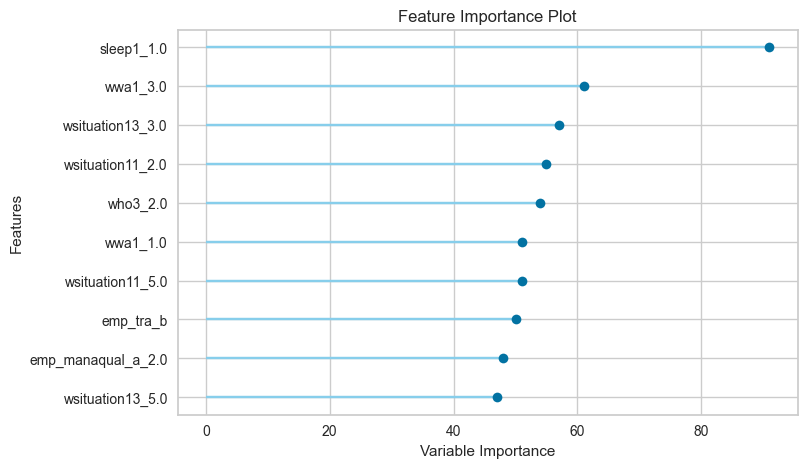

In [43]:
plot_model(lgbm_model, plot='feature')

In [44]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [45]:
### 파이프라인 준비
df_new.columns

Index(['id', 'burnout60', 'area', 'gender', 'wtime_length5', 'age_group',
       'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group',
       ...
       'edu', 'marital', 'children', 'panel_survey', 'heal_abs1_group',
       'ctime_group', 'disc_group', 'decla_group', 'winten2_group',
       'winten3_group'],
      dtype='object', length=172)

In [46]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11243 entries, 0 to 14955
Columns: 172 entries, id to winten3_group
dtypes: category(2), float64(133), int64(34), object(3)
memory usage: 14.9+ MB


In [47]:
df_new['burnout60'].unique()

[1, 2, 3]
Categories (3, int64): [1, 2, 3]

In [48]:
df_new['burnout60'] = df_new['burnout60'].map({1: 0, 2: 1, 3: 2})


In [49]:
df_new['burnout60'].unique()

[0, 1, 2]
Categories (3, int64): [0, 1, 2]

In [50]:
# 데이터 분할
# 전체 데이터
X = df_new.drop(columns=['id','burnout60','area']).values
y = df_new['burnout60'].values

print("X 데이터: ", X.shape)
print("y 데이터: ", y.shape)

X 데이터:  (11243, 169)
y 데이터:  (11243,)


In [51]:
# 데이터 분할 = 훈련 데이터 / 테스트 데이터 = 8:2
from sklearn.model_selection import train_test_split

# y가 NaN인 인덱스 제거
not_nan_mask = ~pd.isnull(y)
X_clean = X[not_nan_mask]
y_clean = y[not_nan_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    stratify=y_clean,  # 클래스 분포 비율 맞추기
    random_state=42
)
print("train 데이터: ", X_train.shape)
print("test 데이터: ", X_test.shape)

train 데이터:  (8994, 169)
test 데이터:  (2249, 169)


In [52]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1, 2], dtype=int64), array([7693, 1129,  172], dtype=int64))
(array([0, 1, 2], dtype=int64), array([1924,  282,   43], dtype=int64))


In [53]:
print(pd.Series(y_train).value_counts(normalize=True))
print(pd.Series(y_test).value_counts(normalize=True))

0    0.855348
1    0.125528
2    0.019124
Name: proportion, dtype: float64
0    0.855491
1    0.125389
2    0.019120
Name: proportion, dtype: float64


## K-겹 교차 검증

In [54]:
### K-겹 교차 검증

from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits = 10).split(X_train, y_train)

scores = []
for k, (train, test) in enumerate(kfold):
    print("k =", k)
    print("train =", train)
    print("test =", test)

k = 0
train = [ 883  884  885 ... 8991 8992 8993]
test = [   0    1    2    3    4    5    6    7    8    9   10   11   12   13
   14   15   16   17   18   19   20   21   22   23   24   25   26   27
   28   29   30   31   32   33   34   35   36   37   38   39   40   41
   42   43   44   45   46   47   48   49   50   51   52   53   54   55
   56   57   58   59   60   61   62   63   64   65   66   67   68   69
   70   71   72   73   74   75   76   77   78   79   80   81   82   83
   84   85   86   87   88   89   90   91   92   93   94   95   96   97
   98   99  100  101  102  103  104  105  106  107  108  109  110  111
  112  113  114  115  116  117  118  119  120  121  122  123  124  125
  126  127  128  129  130  131  132  133  134  135  136  137  138  139
  140  141  142  143  144  145  146  147  148  149  150  151  152  153
  154  155  156  157  158  159  160  161  162  163  164  165  166  167
  168  169  170  171  172  173  174  175  176  177  178  179  180  181
  182  183  184  185

In [55]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components = 3),
                        LogisticRegression(random_state = 42))

kfold = StratifiedKFold(n_splits = 10).split(X_train, y_train)

scores = []
for k, (train, test) in enumerate(kfold):
    y_fold = y_train[train]
    unique_classes = np.unique(y_fold)
    if len(unique_classes) < 2:
        print(f"폴드: {k+1}, 클래스 분포: {np.bincount(y_fold.astype(int))} -> SKIP (단일 클래스: {unique_classes})")
        continue
    pipe_lr.fit(X_train[train], y_fold)
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)
    print('폴드: %2d, 클래스 분포: %s, 정확도: %.3f' % (k+1,
          np.bincount(y_fold.astype(int)), score))

print('\nCV 정확도: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

폴드:  1, 클래스 분포: [6923 1016  155], 정확도: 0.872
폴드:  2, 클래스 분포: [6923 1016  155], 정확도: 0.874
폴드:  3, 클래스 분포: [6923 1017  154], 정확도: 0.871
폴드:  4, 클래스 분포: [6924 1016  154], 정확도: 0.873
폴드:  5, 클래스 분포: [6924 1016  155], 정확도: 0.870
폴드:  6, 클래스 분포: [6924 1016  155], 정확도: 0.865
폴드:  7, 클래스 분포: [6924 1016  155], 정확도: 0.863
폴드:  8, 클래스 분포: [6924 1016  155], 정확도: 0.873
폴드:  9, 클래스 분포: [6924 1016  155], 정확도: 0.871
폴드: 10, 클래스 분포: [6924 1016  155], 정확도: 0.865

CV 정확도: 0.870 +/- 0.004


In [56]:
# cross_val_score
scores = cross_val_score(estimator = pipe_lr, X = X_train, y = y_train, cv = 10, n_jobs = -1)
print('CV 정확도 점수: %s' % scores)
print('CV 정확도: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

CV 정확도 점수: [0.87222222 0.87444444 0.87111111 0.87333333 0.86985539 0.86540601
 0.86318131 0.87319244 0.87096774 0.86540601]
CV 정확도: 0.870 +/- 0.004


In [57]:
# cross_validate
scores = cross_validate(estimator = pipe_lr, X = X_train, y = y_train, scoring=['accuracy'],
                        cv = 10, n_jobs = -1)
print('CV 정확도 점수: %s' % scores['test_accuracy'])
print('CV 정확도: %.3f +/- %.3f' % (np.mean(scores['test_accuracy']), np.std(scores['test_accuracy'])))

CV 정확도 점수: [0.87222222 0.87444444 0.87111111 0.87333333 0.86985539 0.86540601
 0.86318131 0.87319244 0.87096774 0.86540601]
CV 정확도: 0.870 +/- 0.004


## 스태킹(Stacking)

In [58]:
### 스태킹(Stacking)

# cross_val_predict => 스태킹(Stacking) 앙상블(Ensemble) 방법처럼 다른 모델에 주입할 훈련 데이터를 만들기 위해 사용
from sklearn.model_selection import cross_val_predict
# 분류값
preds = cross_val_predict(estimator=pipe_lr,
                          X=X_train,
                          y=y_train,
                          cv=10,
                          n_jobs=-1)
preds[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [59]:
from sklearn.model_selection import cross_val_predict
# 확률값
preds = cross_val_predict(estimator=pipe_lr,
                          X=X_train,
                          y=y_train,
                          cv=10,
                          method='predict_proba',
                          n_jobs=-1)
preds[:10]

array([[9.67369608e-01, 3.22712406e-02, 3.59151215e-04],
       [9.77284963e-01, 2.25012012e-02, 2.13836103e-04],
       [9.66042022e-01, 3.34901209e-02, 4.67857094e-04],
       [9.49748133e-01, 4.93986481e-02, 8.53218484e-04],
       [9.32324034e-01, 6.59265421e-02, 1.74942383e-03],
       [9.28481528e-01, 6.98134604e-02, 1.70501210e-03],
       [9.90772762e-01, 9.18752184e-03, 3.97160606e-05],
       [9.83990088e-01, 1.59001279e-02, 1.09784020e-04],
       [9.86715381e-01, 1.32032605e-02, 8.13582993e-05],
       [9.83835466e-01, 1.60689354e-02, 9.55987077e-05]])

In [60]:
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier


# 기본 모델 정의
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Lgb', LGBMClassifier(n_estimators=100, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42))
]

# 메타 모델 정의
meta_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# 스태킹 모델 구성
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=True  # 원본 특성도 메타모델에 전달
)

# 학습
stack_model.fit(X_train, y_train)

# 예측 및 평가
y_pred = stack_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"스태킹 모델 정확도: {acc:.4f}")

  File "c:\Users\user\anaconda3\envs\python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\user\anaconda3\envs\python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\user\anaconda3\envs\python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\user\anaconda3\envs\python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003981 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 751
[LightGBM] [Info] Number of data points in the train set: 8994, number of used features: 161
[LightGBM] [Info] Start training from score -0.156247
[LightGBM] [Info] Start training from score -2.075225
[LightGBM] [Info] Start training from score -3.956818
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 750
[LightGBM] [Info] Number of data points in the train set: 7195, number of used features: 161
[LightGBM] [Info] Start training from score -0.156284
[LightGBM] [Info] Start training from score -2.075419
[LightGBM] [Info] Start tr

In [61]:
### confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
confmat = confusion_matrix(y_true = y_test, y_pred = y_pred)
print(confmat)

[[1884   40    0]
 [ 220   61    1]
 [  14   26    3]]


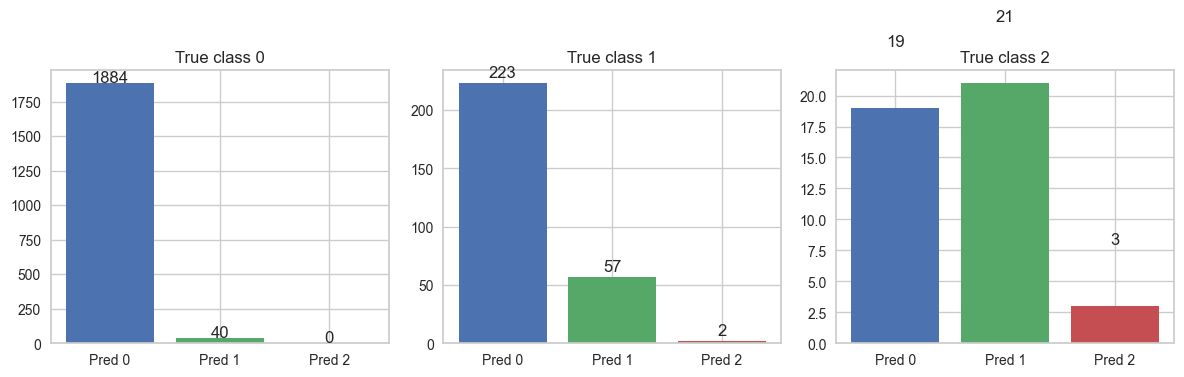

In [62]:
# 시각화
confmat = np.array([[1884, 40, 0],
                    [223, 57, 2],
                    [19, 21, 3]])

classes = [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, cls in enumerate(classes):
    # 한 클래스만 뽑아서 시각화
    row = confmat[cls, :]
    ax = axes[idx]
    ax.bar(range(len(classes)), row, color=['#4c72b0', '#55a868', '#c44e52'])
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels([f"Pred {c}" for c in classes])
    ax.set_title(f"True class {cls}")
    for i, val in enumerate(row):
        ax.text(i, val+5, str(val), ha='center')

plt.tight_layout()
plt.show()


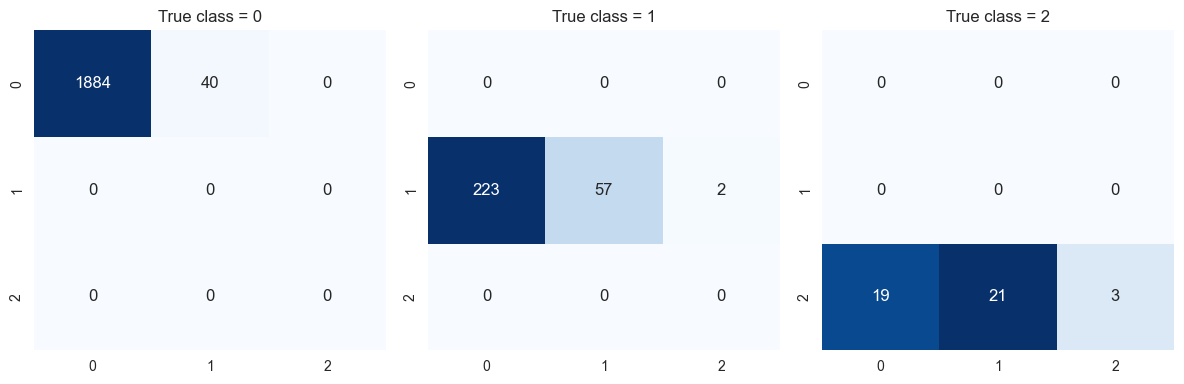

In [63]:

# 원래 confusion matrix
confmat = np.array([[1884, 40, 0],
                    [223, 57, 2],
                    [19, 21, 3]])

classes = [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, cls in enumerate(classes):
    # 해당 클래스 행(row)만 추출
    row = np.zeros_like(confmat)
    row[cls, :] = confmat[cls, :]
    
    sns.heatmap(row, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=classes, yticklabels=classes, ax=axes[idx])
    axes[idx].set_title(f"True class = {cls}")

plt.tight_layout()
plt.show()


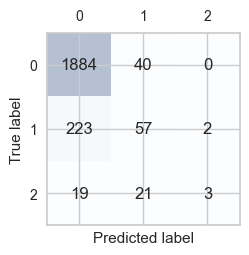

In [64]:
# confusion_matrix로
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap = plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x = j, y = i, s = confmat[i, j], va = 'center', ha = 'center')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

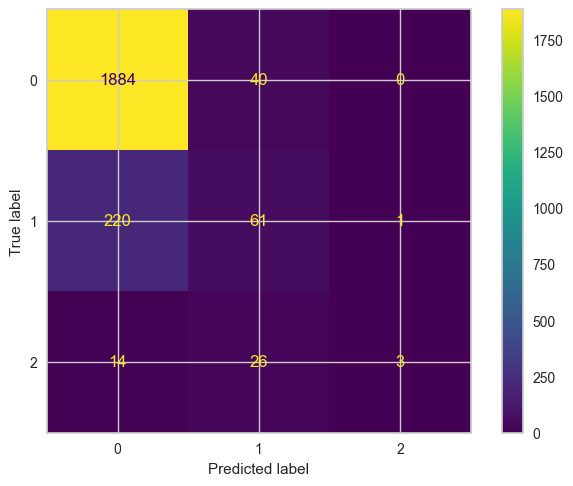

In [65]:
# 테스트 데이터로
ConfusionMatrixDisplay.from_estimator(pipe_lr, X_test, y_test)
plt.show()

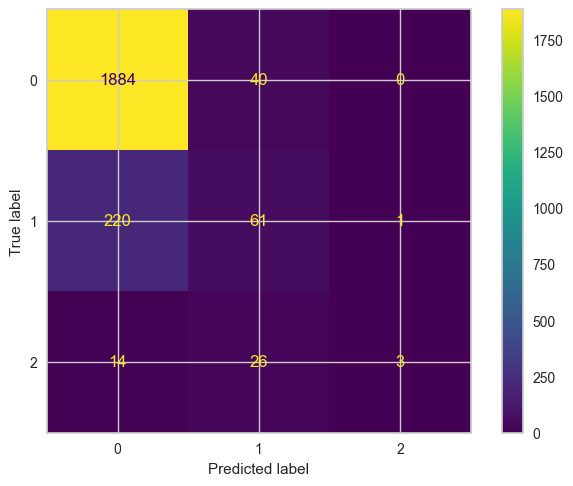

In [66]:
# 실제값, 분류값으로
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

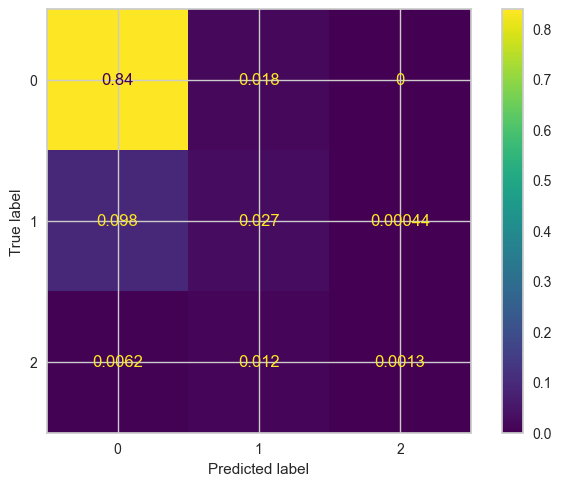

In [67]:
# 비율로 확인하기
ConfusionMatrixDisplay.from_estimator(pipe_lr, X_test, y_test,
                                      normalize = 'all')
plt.savefig('./confusion_matrix_normalize.png', dpi=300)
plt.show()

In [68]:
### Matrics 'macro'

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# y_test, y_pred가 이미 있다고 가정
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))

# 클래스별 상세 리포트
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.866162738995109
Precision (macro): 0.7066111247425516
Recall (macro): 0.42176315926934427
F1-score (macro): 0.4527199531246282

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      1924
           1       0.48      0.22      0.30       282
           2       0.75      0.07      0.13        43

    accuracy                           0.87      2249
   macro avg       0.71      0.42      0.45      2249
weighted avg       0.84      0.87      0.84      2249



## 불균형한 클래스 오버 샘플링

In [69]:
### 불균형한 클래스 오버 샘플링

from sklearn.utils import resample

# 클래스 0과 1의 샘플 수 확인
print('샘플링 전 클래스 0 샘플 수:', y_train[y_train == 0].shape[0])
print('샘플링 전 클래스 1 샘플 수:', y_train[y_train == 1].shape[0])
print('샘플링 전 클래스 2 샘플 수:', y_train[y_train == 2].shape[0])

# 클래스 0과 1 분리
X_train_0 = X_train[y_train == 0]
y_train_0 = y_train[y_train == 0]

X_train_1 = X_train[y_train == 1]
y_train_1 = y_train[y_train == 1]

X_train_2 = X_train[y_train == 2]
y_train_2 = y_train[y_train == 2]

# 다수 클래스 크기에 맞춰 목표 샘플 수 설정(여기선 0번 크기)
target_n = len(y_train_0)



# 1번, 2번 오버샘플링
X_train_1_upsampled, y_train_1_upsampled = resample(
    X_train_1, y_train_1, replace=True, n_samples=target_n, random_state=42
)
X_train_2_upsampled, y_train_2_upsampled = resample(
    X_train_2, y_train_2, replace=True, n_samples=target_n, random_state=42
)

# 합치기 (0 + 1_up + 2_up)
X_train_balanced = np.vstack((X_train_0, X_train_1_upsampled, X_train_2_upsampled))
y_train_balanced = np.hstack((y_train_0, y_train_1_upsampled, y_train_2_upsampled))

# 확인
print('샘플링 후 클래스 0:', np.sum(y_train_balanced == 0))
print('샘플링 후 클래스 1:', np.sum(y_train_balanced == 1))
print('샘플링 후 클래스 2:', np.sum(y_train_balanced == 2))

샘플링 전 클래스 0 샘플 수: 7693
샘플링 전 클래스 1 샘플 수: 1129
샘플링 전 클래스 2 샘플 수: 172
샘플링 후 클래스 0: 7693
샘플링 후 클래스 1: 7693
샘플링 후 클래스 2: 7693


In [70]:
# X_train_balanced, y_train_balanced 는 네가 만든 오버샘플링 결과 (0+1_up+2_up)

# 만약 ColumnTransformer가 DataFrame을 기대한다면 컬럼 유지
if isinstance(X_train, pd.DataFrame):
    # 컬럼 개수 불일치 시, 앞에서 사용한 feature 리스트로 맞추기
    if X_train_balanced.shape[1] == len(X_train.columns):
        X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=X_train.columns)
    else:
        # 컬럼 개수 맞는 부분만 사용 (예: selected_features 등)
        # 아래 selected_features는 실제 사용한 feature 리스트로 교체
        X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=X_train.columns[:X_train_balanced.shape[1]])
else:
    X_train_balanced_df = X_train_balanced  # 이미 ndarray면 그대로

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 예시: 모든 feature에 대해 StandardScaler 적용
preprocess = StandardScaler()

from lightgbm import LGBMClassifier
clf = Pipeline(steps=[
    ('pre', preprocess),                          # 수치/범주 impute + OHE 등
    ('model', LGBMClassifier(random_state=42))
])

# ⬇️ 오버샘플링된 train으로 학습
clf.fit(X_train_balanced_df, y_train_balanced)

# ⬇️ 원본 test로 예측 (절대 test는 오버샘플링 X)
y_pred = clf.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 762
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


Confusion Matrix (counts)
 [[1727  194    3]
 [ 106  160   16]
 [   4   20   19]]


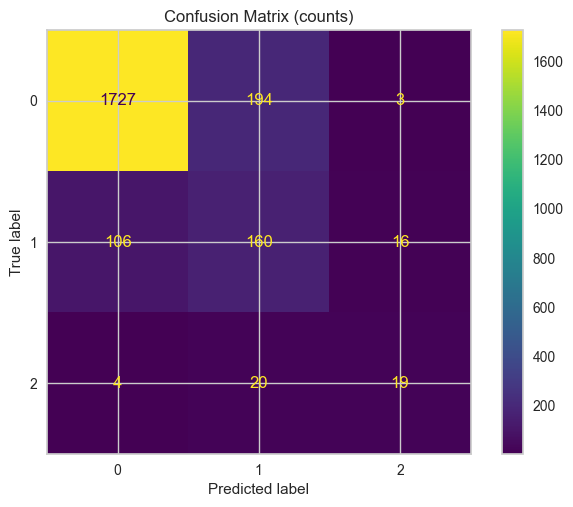

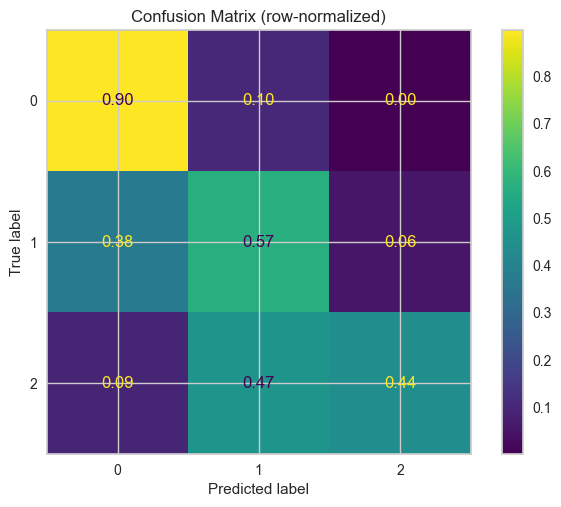

In [71]:
# 라벨 순서를 고정하고 싶으면 labels=[0,1,2] 지정
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_train))
print("Confusion Matrix (counts)\n", cm)

# 시각화 (matplotlib)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_train))
disp.plot(values_format='d')
plt.title("Confusion Matrix (counts)")
plt.show()

# 비율로도 보고 싶다면 (행 기준 정규화: 실제 클래스별 정확 분포)
cm_norm = confusion_matrix(y_test, y_pred, labels=np.unique(y_train), normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=np.unique(y_train))
disp2.plot(values_format='.2f')
plt.title("Confusion Matrix (row-normalized)")
plt.show()


In [72]:
print("\nClassification report (macro avg 강조)")
print(classification_report(y_test, y_pred, digits=3))

# 직접 f1 비교
from sklearn.metrics import f1_score
print("F1 macro   :", f1_score(y_test, y_pred, average='macro'))
print("F1 weighted:", f1_score(y_test, y_pred, average='weighted'))



Classification report (macro avg 강조)
              precision    recall  f1-score   support

           0      0.940     0.898     0.918      1924
           1      0.428     0.567     0.488       282
           2      0.500     0.442     0.469        43

    accuracy                          0.847      2249
   macro avg      0.623     0.636     0.625      2249
weighted avg      0.867     0.847     0.856      2249

F1 macro   : 0.6251044845721778
F1 weighted: 0.8557950336816669


## 오버 샘플링+ 언더 샘플링

In [73]:
### 오버 샘플링+ 언더 샘플링

from sklearn.utils import resample
import numpy as np
import pandas as pd

# X_train, y_train 준비 (DataFrame/ndarray 아무거나 OK)
# labels 순서: [0,1,2]로 가정(다르면 수정)
labels = [0, 1, 2]

# --- 편의: DataFrame이면 ndarray로 변환(그대로 써도 무방) ---
X_arr = X_train.values if hasattr(X_train, "values") else np.asarray(X_train)
y_arr = y_train.values if hasattr(y_train, "values") else np.asarray(y_train)

# === 분포 확인(샘플링 전) ===
print("샘플링 전 클래스 0 샘플 수:", np.sum(y_arr == 0))
print("샘플링 전 클래스 1 샘플 수:", np.sum(y_arr == 1))
print("샘플링 전 클래스 2 샘플 수:", np.sum(y_arr == 2))

# === 클래스별 분리 ===
X_by_c = {c: X_arr[y_arr == c] for c in labels}
y_by_c = {c: y_arr[y_arr == c] for c in labels}
n_by_c = {c: len(y_by_c[c]) for c in labels}

# --- 타깃 크기 결정 ---
#   기본: 소수 클래스들(0을 제외한 최대 다수라 가정 x) 중 더 큰 쪽에 맞춤
minor_counts = [n_by_c[c] for c in labels if c != max(n_by_c, key=n_by_c.get)]
target_n = max(minor_counts)                       # 예: max(n1, n2)
target_n = min(target_n, n_by_c[0])                # 0보다 크게 잡히지 않도록(불필요한 과샘플 방지)
# 필요 시 직접 지정 가능: target_n = 1000

print(f"\n타깃 크기(target_n) = {target_n}")

# === 하이브리드 리샘플링 ===
X_parts, y_parts = [], []
for c in labels:
    n = n_by_c[c]
    if n < target_n:
        # 오버샘플링 (네가 보낸 사진과 동일: replace=True)
        X_res, y_res = resample(
            X_by_c[c], y_by_c[c],
            replace=True, n_samples=target_n, random_state=42
        )
    elif n > target_n:
        # 언더샘플링 (지금 첨부한 코드와 동일: replace=False)
        X_res, y_res = resample(
            X_by_c[c], y_by_c[c],
            replace=False, n_samples=target_n, random_state=42
        )
    else:
        X_res, y_res = X_by_c[c], y_by_c[c]

    X_parts.append(X_res)
    y_parts.append(y_res)

# === 합치기 + 셔플 ===
X_train_balanced = np.vstack(X_parts)
y_train_balanced = np.hstack(y_parts)

rng = np.random.RandomState(42)
perm = rng.permutation(len(y_train_balanced))
X_train_balanced = X_train_balanced[perm]
y_train_balanced = y_train_balanced[perm]

# === 결과 확인 ===
print("\n샘플링 후 클래스 0 샘플 수:", np.sum(y_train_balanced == 0))
print("샘플링 후 클래스 1 샘플 수:", np.sum(y_train_balanced == 1))
print("샘플링 후 클래스 2 샘플 수:", np.sum(y_train_balanced == 2))

# 보기 좋게 표로
before = pd.Series([n_by_c[c] for c in labels], index=labels, name="before")
after  = pd.Series([np.sum(y_train_balanced == c) for c in labels], index=labels, name="after")
print("\n분포 변화:\n", pd.concat([before, after], axis=1))


샘플링 전 클래스 0 샘플 수: 7693
샘플링 전 클래스 1 샘플 수: 1129
샘플링 전 클래스 2 샘플 수: 172

타깃 크기(target_n) = 1129

샘플링 후 클래스 0 샘플 수: 1129
샘플링 후 클래스 1 샘플 수: 1129
샘플링 후 클래스 2 샘플 수: 1129

분포 변화:
    before  after
0    7693   1129
1    1129   1129
2     172   1129


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 739
[LightGBM] [Info] Number of data points in the train set: 3387, number of used features: 158
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Confusion Matrix (counts)
 [[1483  437    4]
 [  55  213   14]
 [   2   22   19]]


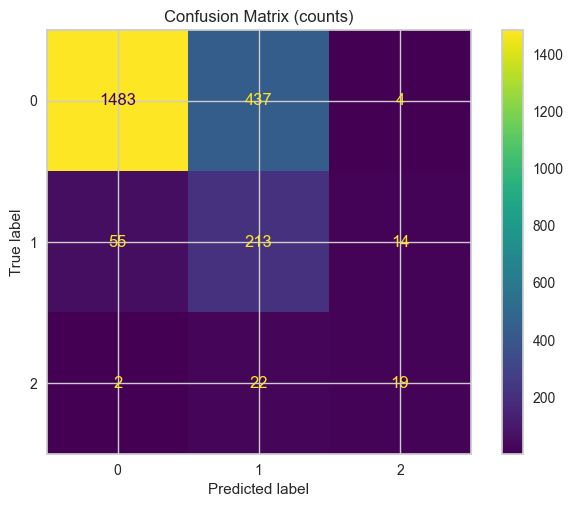

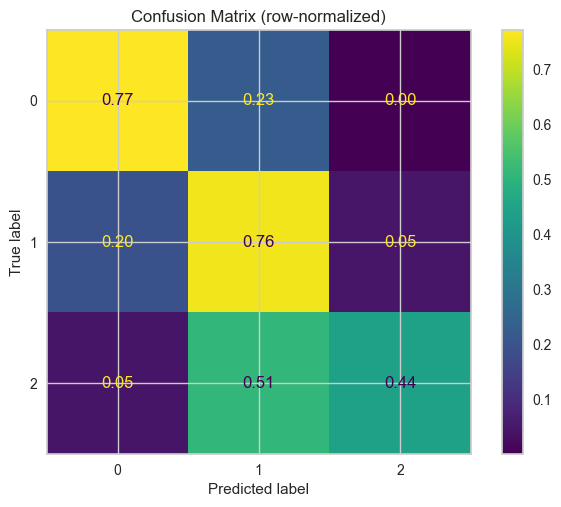

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from lightgbm import LGBMClassifier

# 1) (앞에서) 오버+언더 샘플링 완료했다고 가정
#    X_train_balanced, y_train_balanced 가 만들어져 있음
model = LGBMClassifier(random_state=42)

# 2) 모델 학습은 '밸런싱된' 데이터로
model.fit(X_train_balanced, y_train_balanced)

# 3) 테스트셋 예측은 원본 테스트셋으로
y_pred = model.predict(X_test)   # <= 이걸 네 코드의 y_pred 자리에 사용

# 4) 라벨 순서 고정(추천)
labels = [0, 1, 2]               # 또는 np.unique(y_train_balanced)

# =========== Confusion Matrix (counts) ===========
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion Matrix (counts)\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d')
plt.title("Confusion Matrix (counts)")
plt.show()

# =========== Confusion Matrix (row-normalized, %) ===========
cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp2.plot(values_format='.2f')
plt.title("Confusion Matrix (row-normalized)")
plt.show()


In [77]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

# (앞에서) model.fit(X_train_balanced, y_train_balanced)
# 예측
y_pred_test = model.predict(X_test)

# 라벨 고정(선택)
labels = [0, 1, 2]
target_names = ["0","1","2"]  # 필요하면 ["Normal","Borderline","Risk"] 등으로 변경

print("\nClassification report (macro avg 강조)")
print(classification_report(
    y_test, y_pred_test,
    labels=labels,            # 고정 라벨 순서
    target_names=target_names, 
    digits=3,
    zero_division=0           # 분모가 0인 경우 경고 대신 0으로 처리
))

print("F1 macro   :", f1_score(y_test, y_pred_test, average='macro'))
print("F1 weighted:", f1_score(y_test, y_pred_test, average='weighted'))



Classification report (macro avg 강조)
              precision    recall  f1-score   support

           0      0.963     0.771     0.856      1924
           1      0.317     0.755     0.447       282
           2      0.514     0.442     0.475        43

    accuracy                          0.763      2249
   macro avg      0.598     0.656     0.593      2249
weighted avg      0.873     0.763     0.798      2249

F1 macro   : 0.5925921487743353
F1 weighted: 0.7975752587546909


## 스케일링/SMOTE/LGBM (DA code: recall값 높음)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33040
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

Classification Report
              precision    recall  f1-score   support

           0      0.914     0.966     0.939      1924
           1      0.544     0.351     0.427       282
           2      0.562     0.419     0.480        43

    accuracy                          0.879      2249
   macro avg      0.673     0.579     0.615      2249
weighted avg      0.860     0.879     0.866      2249

F1 macro   : 0.6152833932869383
F1 weighted: 0.8660981376475985


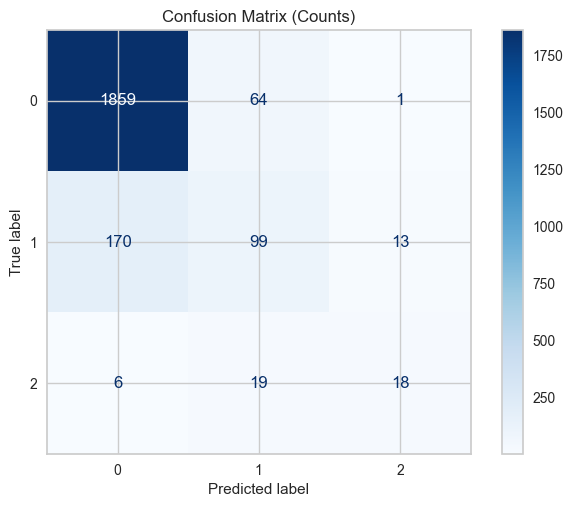

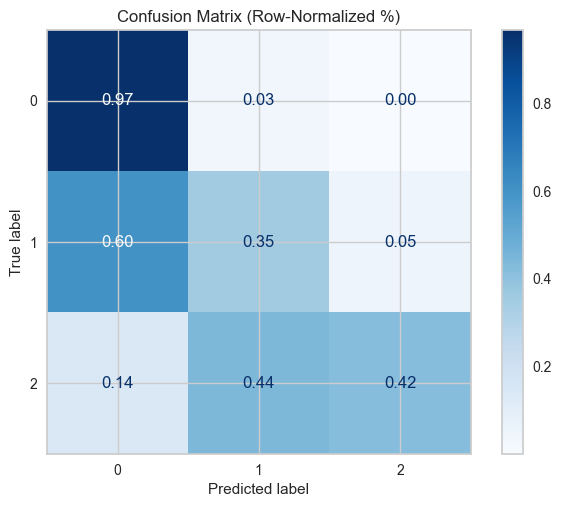

In [78]:
### 스케일링/SMOTE/LGBM

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1) 파이프라인 정의 (표준화 + SMOTE + LGBM)
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),            
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('lgbm',   LGBMClassifier(random_state=42, class_weight='balanced'))
])

# 2) 학습
pipe.fit(X_train, y_train)

# 3) 예측
y_pred = pipe.predict(X_test)

# 4) 성능 리포트 출력
print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=3))

print("F1 macro   :", f1_score(y_test, y_pred, average='macro'))
print("F1 weighted:", f1_score(y_test, y_pred, average='weighted'))

# 5) 혼동행렬 (Counts)
labels = np.unique(y_train)   # 실제 클래스 라벨 (예: 0,1,2)
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d', cmap='Blues')
plt.title("Confusion Matrix (Counts)")
plt.show()

# 6) 혼동행렬 (Row-Normalized: %)
cmn = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cmn, display_labels=labels)
disp2.plot(values_format='.2f', cmap='Blues')
plt.title("Confusion Matrix (Row-Normalized %)")
plt.show()


ROC AUC (per class): {0: 0.8856884695346234, 1: 0.8555654108391292, 2: 0.9542052330852432}
ROC AUC (macro): 0.8984863711529986


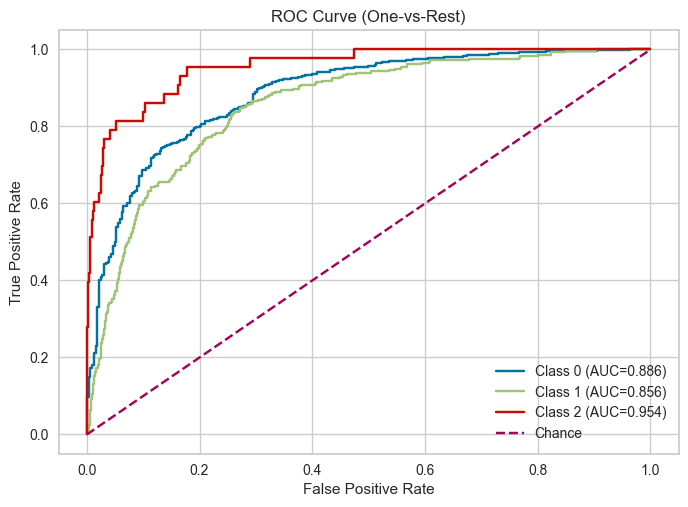

In [79]:
### ROC Curve (One-vs-Rest, 클래스별 + macro AUC)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1) 확률 예측
y_proba = pipe.predict_proba(X_test)          # shape: (n_samples, n_classes)
classes = np.unique(y_train)                  # 예: array([0,1,2])
y_test_bin = label_binarize(y_test, classes=classes)

# 2) 클래스별 ROC 곡선과 AUC
fpr, tpr, roc_auc = {}, {}, {}
for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

# 3) macro-average (간단 평균)
macro_auc = np.mean(list(roc_auc.values()))
print("ROC AUC (per class):", roc_auc)
print("ROC AUC (macro):", macro_auc)

# 4) 플롯 (각 클래스 곡선 한 장에)
plt.figure()
for c in classes:
    plt.plot(fpr[c], tpr[c], label=f"Class {c} (AUC={roc_auc[c]:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()



[5-Fold OOF: classification report on X_train]
              precision    recall  f1-score   support

           0      0.904     0.971     0.936      7693
           1      0.537     0.314     0.396      1129
           2      0.671     0.308     0.422       172

    accuracy                          0.875      8994
   macro avg      0.704     0.531     0.585      8994
weighted avg      0.854     0.875     0.859      8994

F1_macro (OOF):    0.585
F1_weighted (OOF): 0.859


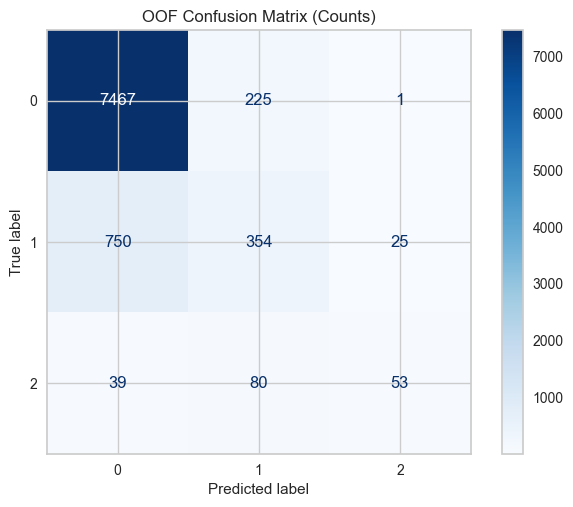

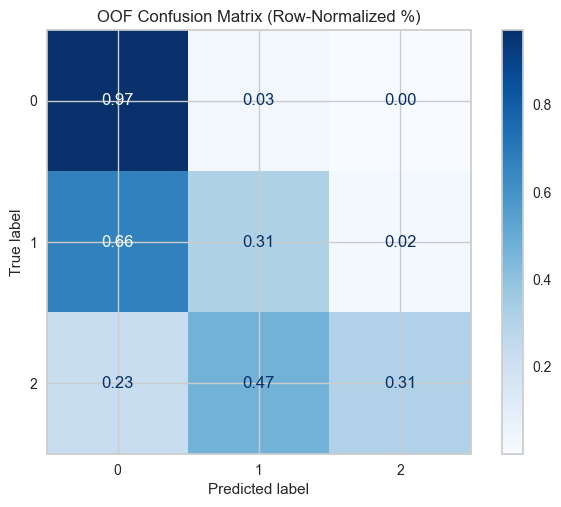

[CV-mean] Acc=0.875  F1_macro=0.585  F1_weighted=0.859
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33040
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

[Holdout: classification report on X_test]
              precision    recall  f1-score   support

           0      0.914     0.966     0.939      1924
           1      0.544     0.351     0.427       282
           2      0.562     0.419     0.480        43

    accuracy                          0.879      2249
   macro avg      0.673     0.579     0.615      2249
weighted avg      0.860     0.879     0.866      2249



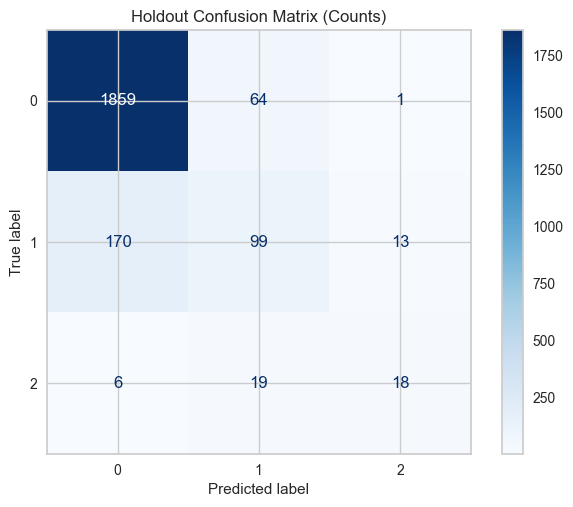

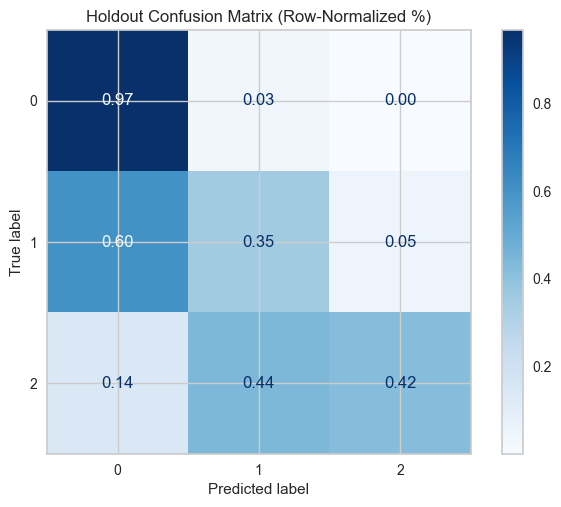

In [80]:
### 내코드 + 5fold 교차검증
# ① (권장) X_train에서 5-Fold OoF 예측으로 평가 + 혼동행렬(Counts/Row%)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.base import clone

# --- 5-fold 세팅 ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 5-fold OoF 예측(훈련 세트 기준) ---
y_pred_oof = cross_val_predict(pipe, X_train, y_train, cv=cv,
                               n_jobs=-1, method='predict')

print("\n[5-Fold OOF: classification report on X_train]")
print(classification_report(y_train, y_pred_oof, digits=3))

print(f"F1_macro (OOF):    {f1_score(y_train, y_pred_oof, average='macro'):.3f}")
print(f"F1_weighted (OOF): {f1_score(y_train, y_pred_oof, average='weighted'):.3f}")

# --- 혼동행렬 (Counts / Row-Normalized) ---
labels = np.unique(y_train)

cm = confusion_matrix(y_train, y_pred_oof, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    cmap='Blues', values_format='d'
)
plt.title("OOF Confusion Matrix (Counts)")
plt.show()

cmn = confusion_matrix(y_train, y_pred_oof, labels=labels, normalize='true')
ConfusionMatrixDisplay(cmn, display_labels=labels).plot(
    cmap='Blues', values_format='.2f'
)
plt.title("OOF Confusion Matrix (Row-Normalized %)")
plt.show()

# --- 폴드별 평균 점수(참고) ---
scores = cross_validate(
    pipe, X_train, y_train, cv=cv, n_jobs=-1,
    scoring={'acc':'accuracy','f1_macro':'f1_macro','f1_weighted':'f1_weighted'},
    return_train_score=False
)
print(f"[CV-mean] Acc={scores['test_acc'].mean():.3f}  "
      f"F1_macro={scores['test_f1_macro'].mean():.3f}  "
      f"F1_weighted={scores['test_f1_weighted'].mean():.3f}")

# --- 원래대로 홀드아웃 X_test 평가도 수행 ---
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\n[Holdout: classification report on X_test]")
print(classification_report(y_test, y_pred, digits=3))

cm_test = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(cm_test, display_labels=labels).plot(
    cmap='Blues', values_format='d'
)
plt.title("Holdout Confusion Matrix (Counts)")
plt.show()

cmn_test = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
ConfusionMatrixDisplay(cmn_test, display_labels=labels).plot(
    cmap='Blues', values_format='.2f'
)
plt.title("Holdout Confusion Matrix (Row-Normalized %)")
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32251
[LightGBM] [Info] Number of data points in the train set: 18462, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


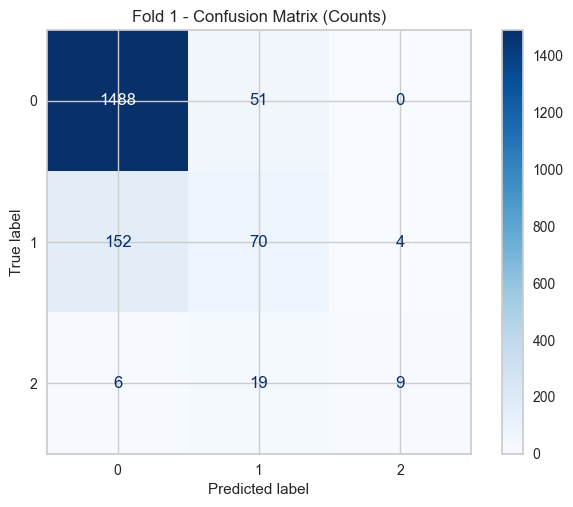

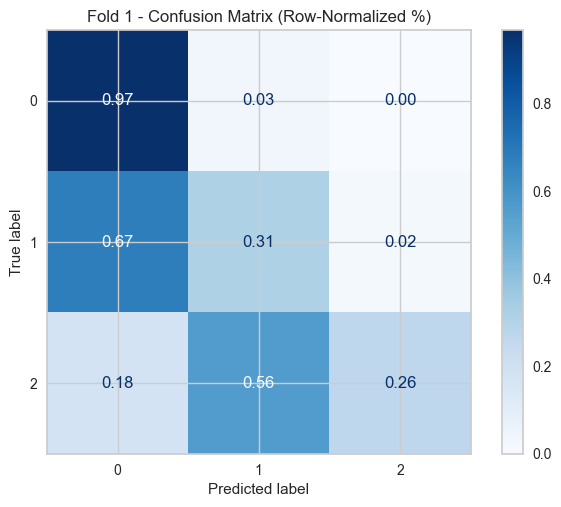

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007986 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32281
[LightGBM] [Info] Number of data points in the train set: 18462, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


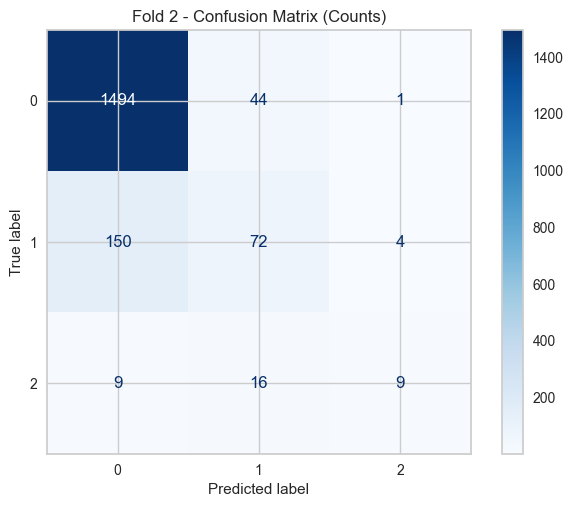

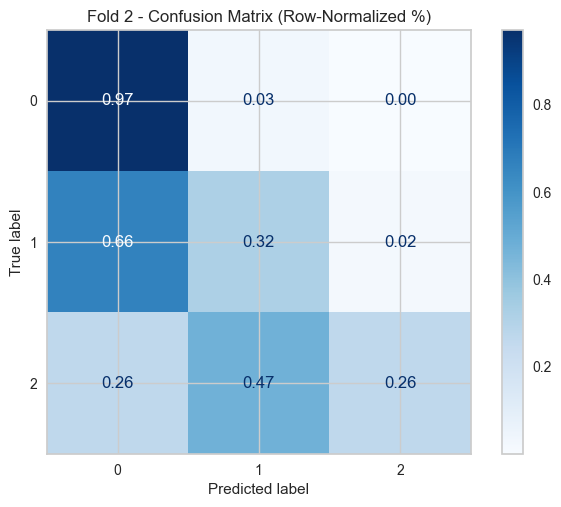

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32614
[LightGBM] [Info] Number of data points in the train set: 18462, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


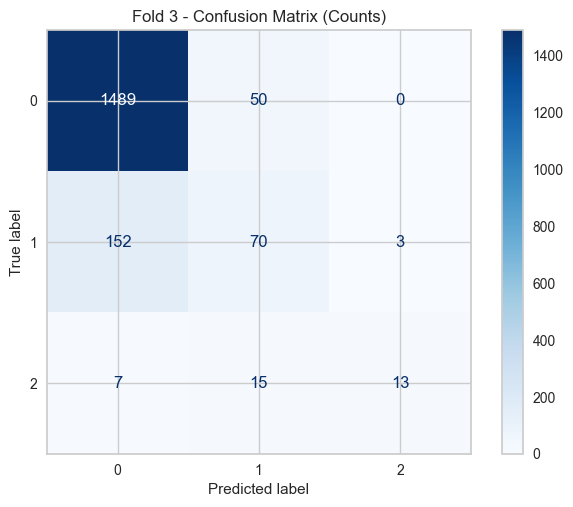

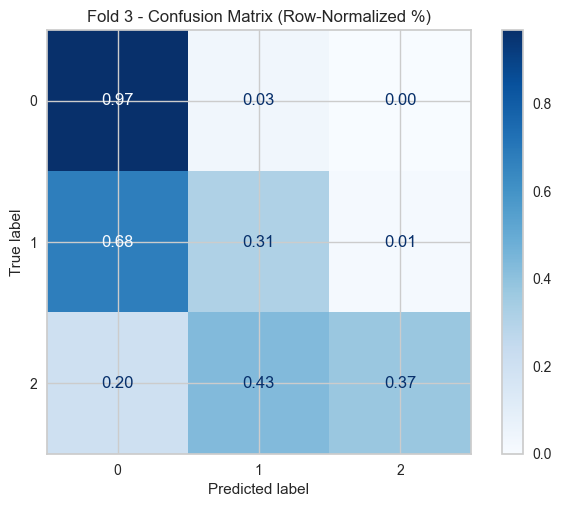

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32462
[LightGBM] [Info] Number of data points in the train set: 18465, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


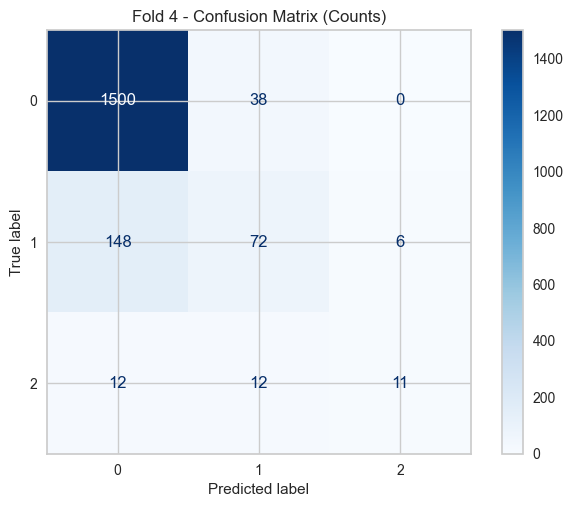

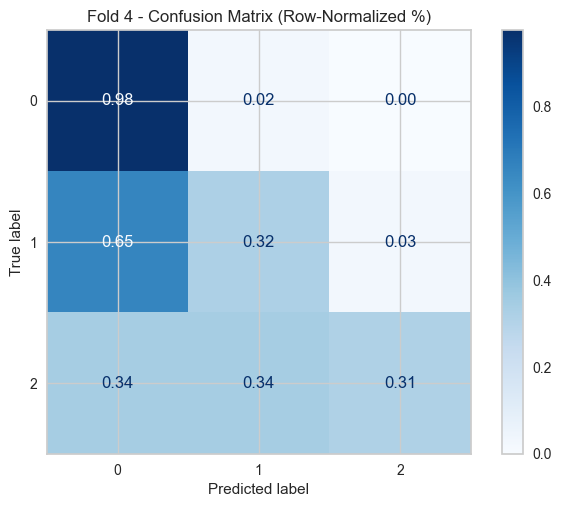

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32241
[LightGBM] [Info] Number of data points in the train set: 18465, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


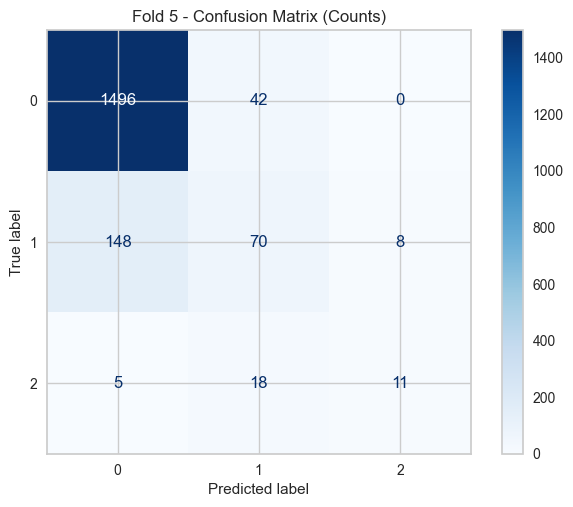

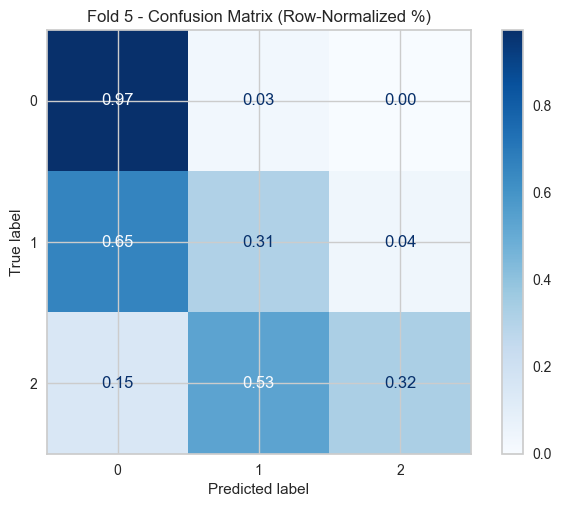

In [81]:
### ② 폴드별로 하나씩 보고 싶다면(각 폴드마다 혼동행렬)

for fold, (tr_idx, te_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr = X_train.iloc[tr_idx] if hasattr(X_train, "iloc") else X_train[tr_idx]
    y_tr = y_train.iloc[tr_idx] if hasattr(y_train, "iloc") else y_train[tr_idx]
    X_te = X_train.iloc[te_idx] if hasattr(X_train, "iloc") else X_train[te_idx]
    y_te = y_train.iloc[te_idx] if hasattr(y_train, "iloc") else y_train[te_idx]

    model_cv = clone(pipe)         # 파이프라인 복제
    model_cv.fit(X_tr, y_tr)
    y_pred = model_cv.predict(X_te)

    cm = confusion_matrix(y_te, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        cmap='Blues', values_format='d'
    )
    plt.title(f"Fold {fold} - Confusion Matrix (Counts)")
    plt.show()

    cmn = confusion_matrix(y_te, y_pred, labels=labels, normalize='true')
    ConfusionMatrixDisplay(cmn, display_labels=labels).plot(
        cmap='Blues', values_format='.2f'
    )
    plt.title(f"Fold {fold} - Confusion Matrix (Row-Normalized %)")
    plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32251
[LightGBM] [Info] Number of data points in the train set: 18462, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


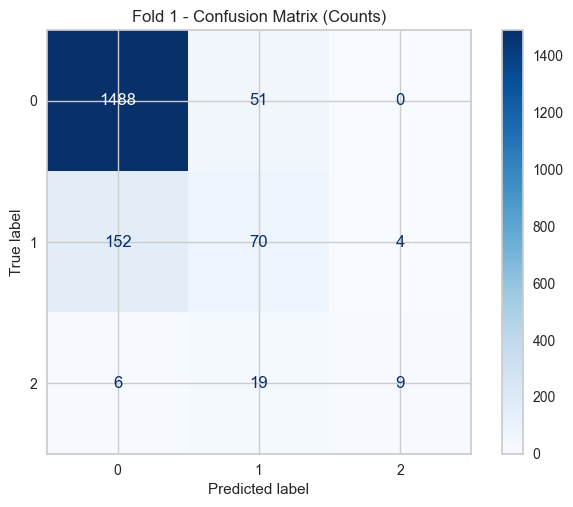

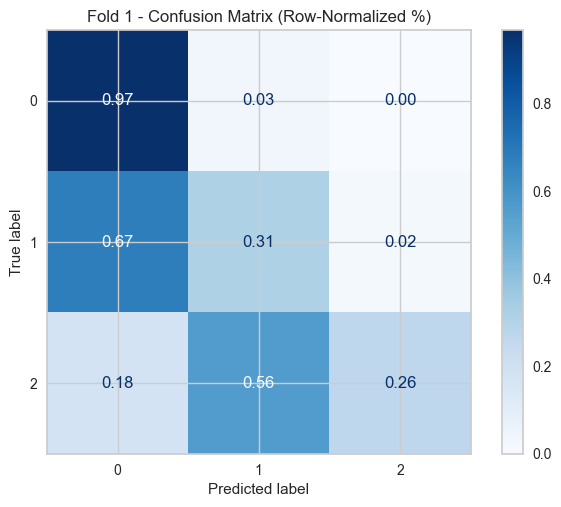

[Fold 1] Acc=0.871  F1(macro)=0.567  F1(weighted)=0.855
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32281
[LightGBM] [Info] Number of data points in the train set: 18462, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


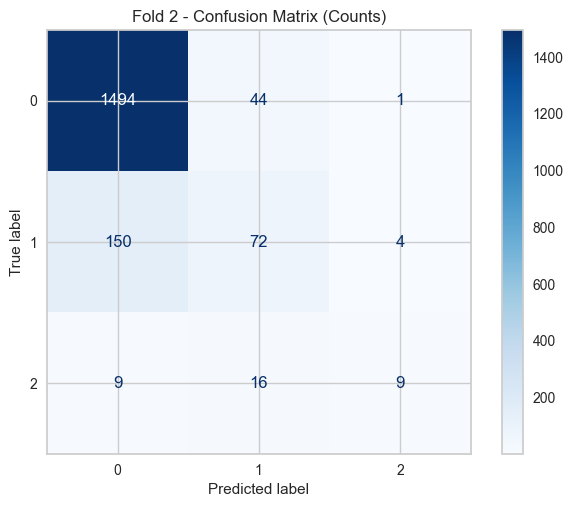

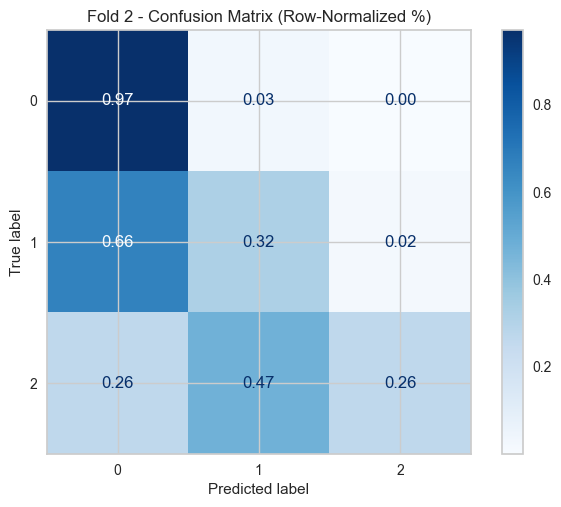

[Fold 2] Acc=0.875  F1(macro)=0.571  F1(weighted)=0.858
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009716 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32614
[LightGBM] [Info] Number of data points in the train set: 18462, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


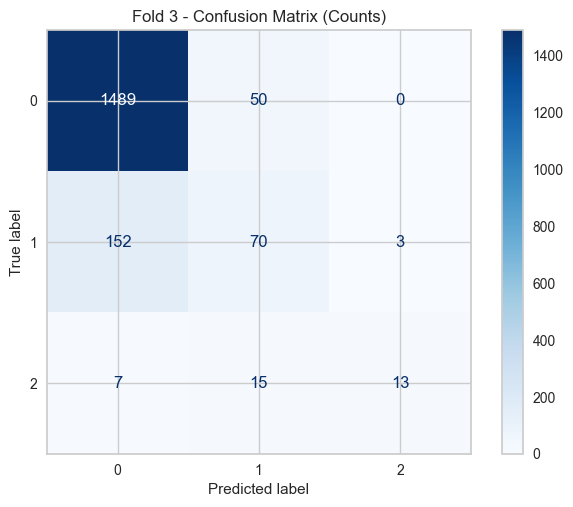

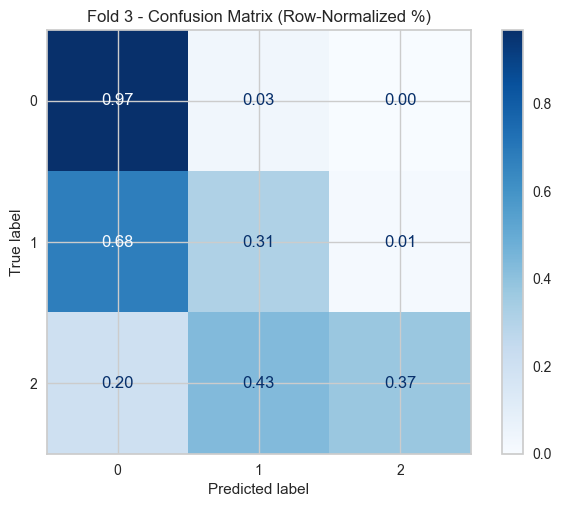

[Fold 3] Acc=0.874  F1(macro)=0.611  F1(weighted)=0.858
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32462
[LightGBM] [Info] Number of data points in the train set: 18465, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


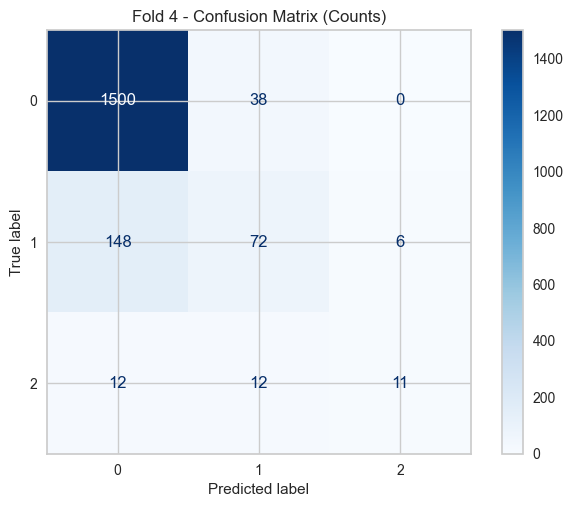

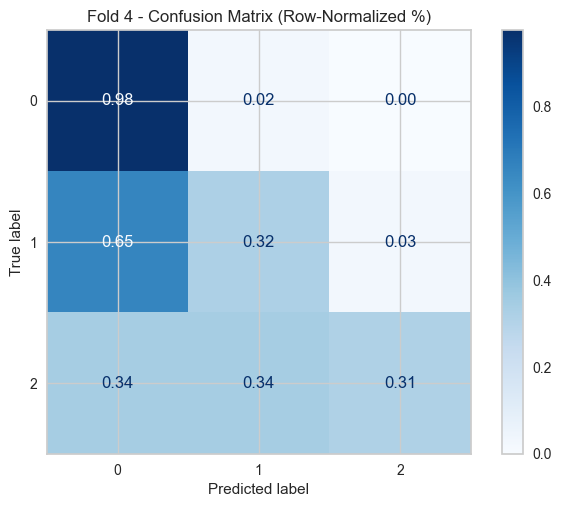

[Fold 4] Acc=0.880  F1(macro)=0.592  F1(weighted)=0.862
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32241
[LightGBM] [Info] Number of data points in the train set: 18465, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


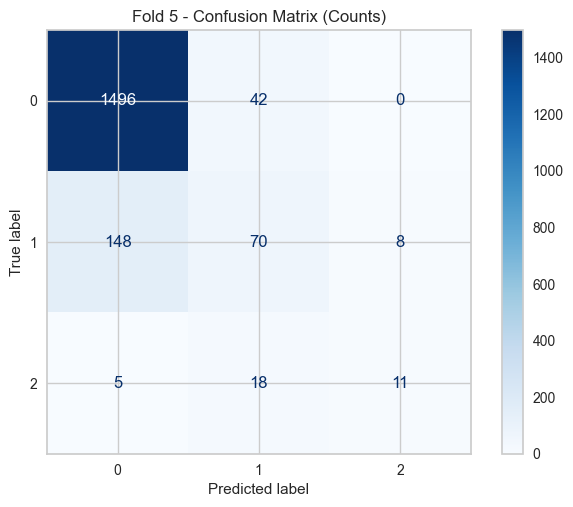

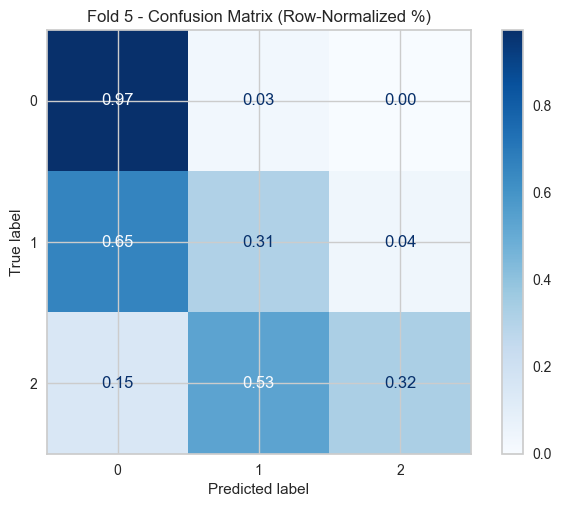

[Fold 5] Acc=0.877  F1(macro)=0.582  F1(weighted)=0.860


In [82]:
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
labels = np.unique(y_train)

def take(a, idx):
    return a.iloc[idx] if hasattr(a, "iloc") else a[idx]

for fold, (tr_idx, te_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, y_tr = take(X_train, tr_idx), take(y_train, tr_idx)
    X_te, y_te = take(X_train, te_idx), take(y_train, te_idx)

    model_cv = clone(pipe)
    model_cv.fit(X_tr, y_tr)
    y_pred = model_cv.predict(X_te)

    cm = confusion_matrix(y_te, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', values_format='d')
    plt.title(f"Fold {fold} - Confusion Matrix (Counts)")
    plt.show()

    cmn = confusion_matrix(y_te, y_pred, labels=labels, normalize='true')
    ConfusionMatrixDisplay(cmn, display_labels=labels).plot(cmap='Blues', values_format='.2f')
    plt.title(f"Fold {fold} - Confusion Matrix (Row-Normalized %)")
    plt.show()

    print(f"[Fold {fold}] Acc={accuracy_score(y_te, y_pred):.3f}  "
          f"F1(macro)={f1_score(y_te, y_pred, average='macro'):.3f}  "
          f"F1(weighted)={f1_score(y_te, y_pred, average='weighted'):.3f}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32765
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

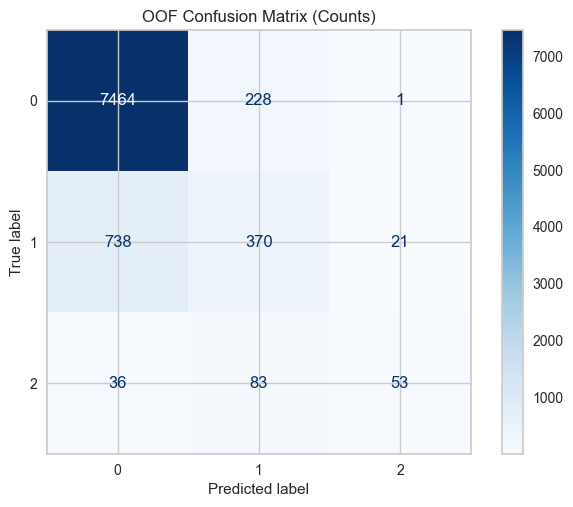

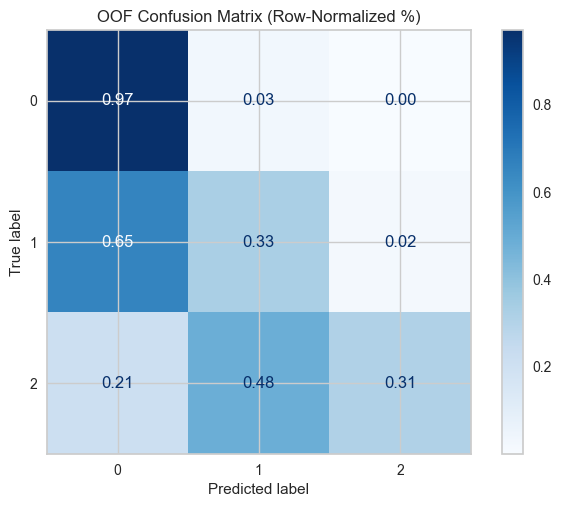

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32765
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

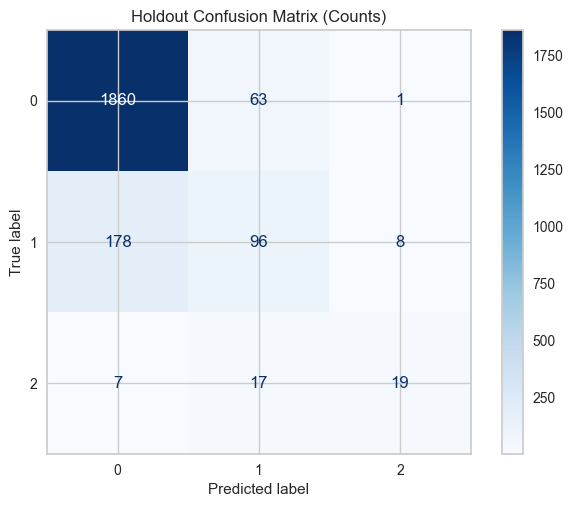

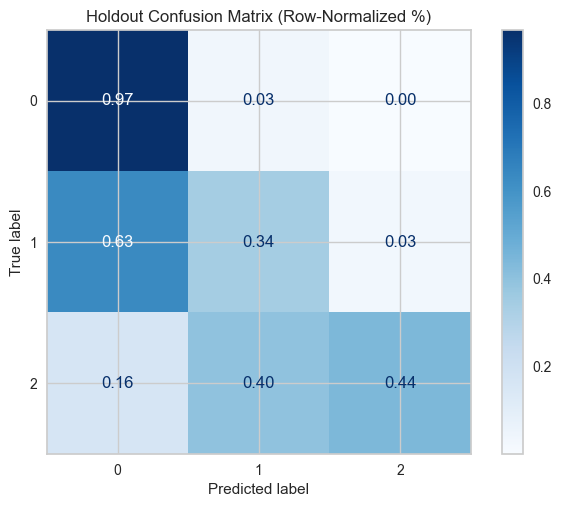

In [83]:
### 내코드+ 5 fold +  하리퍼파라미터

# ==== 0) Imports ====
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

# ==== 1) 네 파이프라인 (class_weight는 그리드에서 비교) ====
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('lgbm',   LGBMClassifier(random_state=42))
])

# ==== 2) 5-fold CV 세팅 ====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==== 3) 하이퍼파라미터 탐색 공간 (안전한 범위) ====
#  - 멀티클래스에서는 SMOTE sampling_strategy는 'auto' 권장
#  - 소수 클래스 샘플 수 <= k_neighbors면 에러 → 필요시 k_neighbors를 더 작게
param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    'lgbm__n_estimators': [300, 600, 1000],
    'lgbm__learning_rate': [0.03, 0.05, 0.1],
    'lgbm__num_leaves': [31, 63, 127],
    'lgbm__max_depth': [-1, 6, 8, 10],
    'lgbm__min_child_samples': [10, 20, 40, 80],
    'lgbm__subsample': [0.7, 0.9, 1.0],
    'lgbm__colsample_bytree': [0.6, 0.8, 1.0],
    'lgbm__reg_lambda': [0.0, 0.5, 1.0],
    'lgbm__reg_alpha': [0.0, 0.5, 1.0],
    'lgbm__class_weight': [None, 'balanced']   # 이중보정 여부 비교
}

# ==== 4) RandomizedSearchCV (빠르고 튜닝 용이) ====
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=40,                        # 시간 여유되면 60~100으로 ↑
    scoring={'f1_macro':'f1_macro', 'f1_weighted':'f1_weighted', 'recall_macro':'recall_macro'},
    refit='f1_macro',                 # 최종 모델 선택 기준 (원하면 'recall_macro'로 바꿔도 됨)
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# ==== 5) 학습 (X_train, y_train 가정) ====
search.fit(X_train, y_train)
best_pipe = search.best_estimator_
print("[Best params]")
print(search.best_params_)
print(f"[CV best f1_macro]: {search.best_score_:.3f}")

# ==== 6) 5-fold OOF 평가 (훈련세트에서의 교차검증 예측) ====
y_pred_oof = cross_val_predict(best_pipe, X_train, y_train, cv=cv, n_jobs=-1, method='predict')

print("\n[OOF on X_train] classification report")
print(classification_report(y_train, y_pred_oof, digits=3))
print(f"OOF F1_macro    : {f1_score(y_train, y_pred_oof, average='macro'):.3f}")
print(f"OOF F1_weighted : {f1_score(y_train, y_pred_oof, average='weighted'):.3f}")

labels = np.unique(y_train)

cm = confusion_matrix(y_train, y_pred_oof, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', values_format='d')
plt.title("OOF Confusion Matrix (Counts)")
plt.show()

cmn = confusion_matrix(y_train, y_pred_oof, labels=labels, normalize='true')
ConfusionMatrixDisplay(cmn, display_labels=labels).plot(cmap='Blues', values_format='.2f')
plt.title("OOF Confusion Matrix (Row-Normalized %)")
plt.show()

# ==== 7) 홀드아웃 테스트셋 평가 ====
best_pipe.fit(X_train, y_train)
y_pred_test = best_pipe.predict(X_test)

print("\n[Holdout on X_test] classification report")
print(classification_report(y_test, y_pred_test, digits=3))



cm_t = confusion_matrix(y_test, y_pred_test, labels=labels)
ConfusionMatrixDisplay(cm_t, display_labels=labels).plot(cmap='Blues', values_format='d')
plt.title("Holdout Confusion Matrix (Counts)")
plt.show()

cmn_t = confusion_matrix(y_test, y_pred_test, labels=labels, normalize='true')
ConfusionMatrixDisplay(cmn_t, display_labels=labels).plot(cmap='Blues', values_format='.2f')
plt.title("Holdout Confusion Matrix (Row-Normalized %)")
plt.show()





In [84]:
# === Confusion Matrix 값(숫자) 출력 ===
import pandas as pd
import numpy as np
from sklearn.metrics import recall_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             recall_score, classification_report)

# ---------- OOF ----------
print("\n[OOF] Confusion Matrix (Counts)")
print(pd.DataFrame(cm, index=labels, columns=labels))

print("\n[OOF] Confusion Matrix (Row-Normalized, %)")
print(pd.DataFrame((cmn*100).round(2), index=labels, columns=labels))

# per-class recall (= 행정규화 대각선)
oof_recall_per_cls = np.diag(cmn)
oof_recall_macro    = recall_score(y_train, y_pred_oof, average='macro')
oof_recall_weighted = recall_score(y_train, y_pred_oof, average='weighted')

oof_table = pd.DataFrame({
    "support": cm.sum(axis=1),
    "TP":      np.diag(cm),
    "recall":  oof_recall_per_cls
}, index=labels).round(3)

print("\n[OOF] Per-class (support / TP / recall)")
print(oof_table)
print(f"[OOF] recall_macro={oof_recall_macro:.3f}  recall_weighted={oof_recall_weighted:.3f}")

# ---------- TEST ----------
print("\n[TEST] Confusion Matrix (Counts)")
print(pd.DataFrame(cm_t, index=labels, columns=labels))

print("\n[TEST] Confusion Matrix (Row-Normalized, %)")
print(pd.DataFrame((cmn_t*100).round(2), index=labels, columns=labels))

test_recall_per_cls  = np.diag(cmn_t)
test_recall_macro    = recall_score(y_test, y_pred_test, average='macro')
test_recall_weighted = recall_score(y_test, y_pred_test, average='weighted')

test_table = pd.DataFrame({
    "support": cm_t.sum(axis=1),
    "TP":      np.diag(cm_t),
    "recall":  test_recall_per_cls
}, index=labels).round(3)

print("\n[TEST] Per-class (support / TP / recall)")
print(test_table)
print(f"[TEST] recall_macro={test_recall_macro:.3f}  recall_weighted={test_recall_weighted:.3f}")






[OOF] Confusion Matrix (Counts)
      0    1   2
0  7464  228   1
1   738  370  21
2    36   83  53

[OOF] Confusion Matrix (Row-Normalized, %)
       0      1      2
0  97.02   2.96   0.01
1  65.37  32.77   1.86
2  20.93  48.26  30.81

[OOF] Per-class (support / TP / recall)
   support    TP  recall
0     7693  7464   0.970
1     1129   370   0.328
2      172    53   0.308
[OOF] recall_macro=0.535  recall_weighted=0.877

[TEST] Confusion Matrix (Counts)
      0   1   2
0  1860  63   1
1   178  96   8
2     7  17  19

[TEST] Confusion Matrix (Row-Normalized, %)
       0      1      2
0  96.67   3.27   0.05
1  63.12  34.04   2.84
2  16.28  39.53  44.19

[TEST] Per-class (support / TP / recall)
   support    TP  recall
0     1924  1860   0.967
1      282    96   0.340
2       43    19   0.442
[TEST] recall_macro=0.583  recall_weighted=0.878


## 내코드에서 Recall score 더 올려보기

In [86]:
### 내코드에서 Recall score 더 올려보기

### 1) 임계값(threshold) 낮추기 – 가장 효과적

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 1) 먼저 모델 학습
pipe.fit(X_train, y_train)

# 2) 확률 예측
proba = pipe.predict_proba(X_test)       # shape = (n_samples, n_classes)

# 3) 기본 argmax 예측
y_pred = np.argmax(proba, axis=1)


# 4) class 2 전용 임계값 적용 (예: 0.35)
t2 = 0.35
force_c2 = proba[:, 2] >= t2             # class 2 확률이 임계값 이상이면
y_pred[force_c2] = 2

print(classification_report(y_test, y_pred, digits=3))
# 팁: 임계값은 검증셋(val)에서 찾고 테스트에 고정 적용이 정석.

from sklearn.metrics import precision_recall_curve

# 이진(one-vs-rest)로 변환해서 class 2에 대한 PR-curve 계산
y_bin = (y_val == 2).astype(int)
p2 = pipe.predict_proba(X_val)[:, 2]
prec, rec, thr = precision_recall_curve(y_bin, p2)

target_recall = 0.80
idx = np.where(rec >= target_recall)[0]
t2 = thr[idx[-1]] if len(idx) > 0 else 1.0   # 목표 리콜을 만족하는 가장 낮은 threshold
print("chosen threshold for class 2:", t2)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33040
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
              precision    recall  f1-score   support

           0      0.914     0.966     0.939      1924
           1      0.554     0.344     0.425       282
           2      0.550     0.512     0.530        43

    accuracy                          0.880      2249
   macro avg      0.673     0.607     0.631      2249
weighted avg      0.862     0.880     0.867      2249

chosen threshold for class 2: 0.027519494170924474


In [87]:
### 4) 하이퍼파라미터 탐색을 “리콜 중심”으로

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler

pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
])

param_dist = {
    'smote__k_neighbors': [3, 5, 7],
    'lgbm__num_leaves': [31, 63, 127],
    'lgbm__min_child_samples': [5, 10, 20],
    'lgbm__learning_rate': [0.05, 0.1],
}

# ✅ 다중분류를 유지하면서 "클래스 2"의 리콜만 최적화
scorer_class2 = make_scorer(
    recall_score,
    labels=[2],            # <- 이 라벨만 평가(다중분류 유지)
    average='macro',
    zero_division=0        # 분모 0일 때 0으로 처리해 에러 방지
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring=scorer_class2,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

search.fit(X_train, y_train)
best_pipe = search.best_estimator_

print("Best params:", search.best_params_)
print("Best CV recall(class 2):", search.best_score_)

y_pred = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))  # 다중분류 리포트 유지


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009933 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33040
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Best params: {'smote__k_neighbors': 5, 'lgbm__num_leaves': 31, 'lgbm__min_child_samples': 20, 'lgbm__learning_rate': 0.05}
Best CV recall(class 2): 0.33731092436974786
              precision    recall  f1-score   support

           0      0.913     0.968     0.940      1924
           1      0.546     0.337     0.417       282
           2      0.528     0.442     0.481        43

    accuracy                          0.879      2249
   macro avg      0.662     0.582     0.612      2249
weighted avg      0.860     0.879     0.865      2249

## 교수님이 알려주신 코드  smote 데이터 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39327
[LightGBM] [Info] Number of data points in the train set: 22962, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39533
[LightGBM] [Info] Number of data points in the train set: 23145, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010543

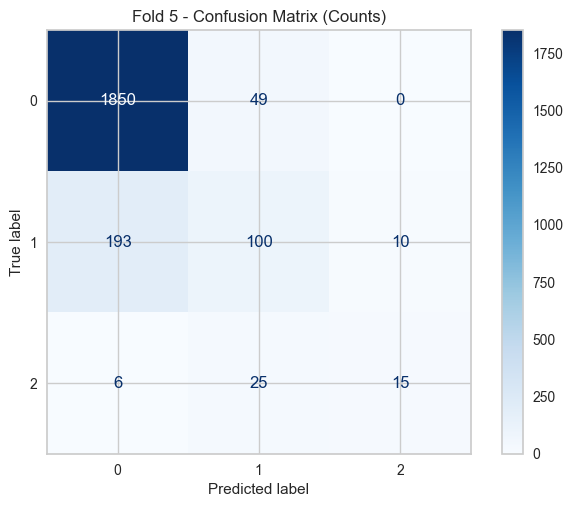

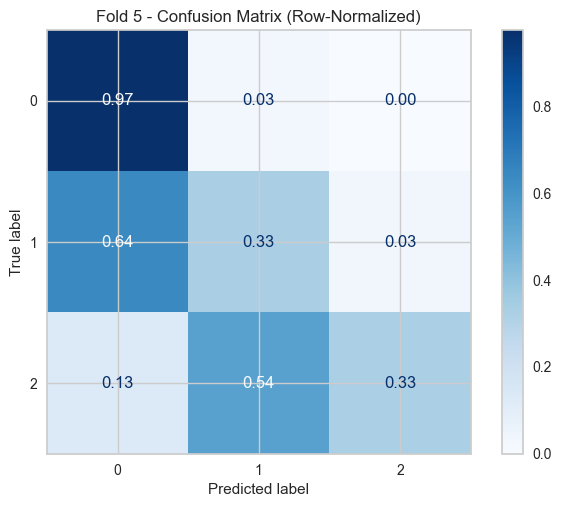

For fold 5:
Accuracy: 0.8741103202846975
Accuracy: 0.874
F1(macro): 0.593
F1(weighted): 0.857


In [89]:
### 교수님이 알려주신 코드  smote 데이터 

from sklearn.model_selection import KFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

kf = KFold(n_splits=5, random_state=42, shuffle=True)

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train = X[train_index]
    y_train = y[train_index]  # Based on your code, you might need a ravel call here, but I would look into how you're generating your y
    X_test = X[test_index]
    y_test = y[test_index]  # See comment on ravel and  y_train
    sm = SMOTE()
    X_train_oversampled, y_train_oversampled = sm.fit_resample(X_train, y_train)
    model = LGBMClassifier (random_state=42) # Choose a model here
    model.fit(X_train_oversampled, y_train_oversampled )
    y_pred = model.predict(X_test)

    # 일관된 축을 위해 모델이 학습한 클래스 순서를 사용
labels = model.classes_   # 예: array([0,1,2])

# (5) Confusion Matrix - Counts
cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    cmap="Blues", values_format="d"
)
plt.title(f"Fold {fold} - Confusion Matrix (Counts)")
plt.show()

# (6) Confusion Matrix - Row-Normalized (%)
cmn = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")
ConfusionMatrixDisplay(cmn, display_labels=labels).plot(
    cmap="Blues", values_format=".2f"
)
plt.title(f"Fold {fold} - Confusion Matrix (Row-Normalized)")
plt.show()

print(f'For fold {fold}:')
print(f'Accuracy: {model.score(X_test, y_test)}')
  
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'F1(macro): {f1_score(y_test, y_pred, average="macro"):.3f}')      # ← 수정
# 필요하면
print(f'F1(weighted): {f1_score(y_test, y_pred, average="weighted"):.3f}')

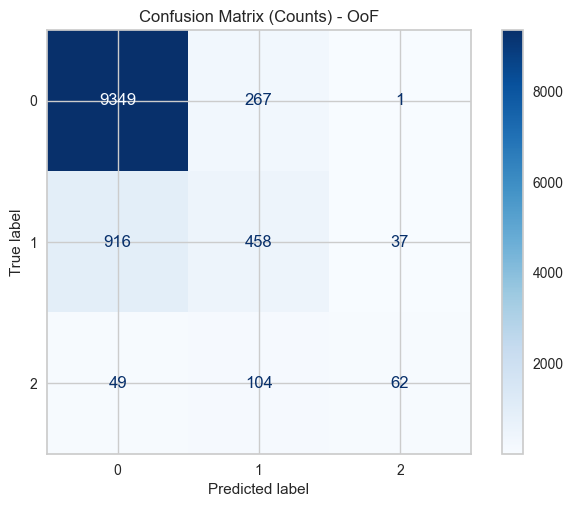

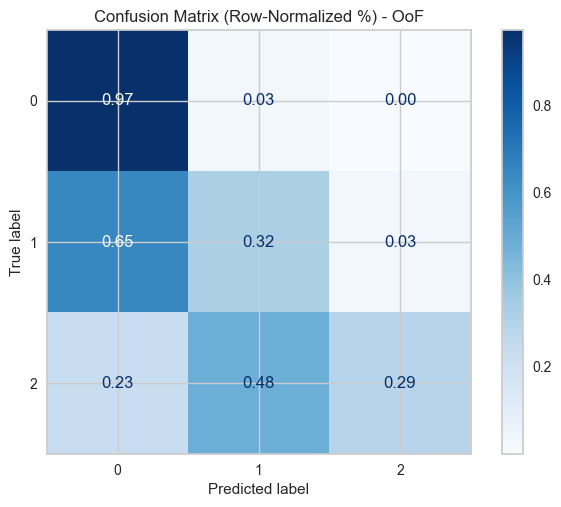

              precision    recall  f1-score   support

           0      0.906     0.972     0.938      9617
           1      0.552     0.325     0.409      1411
           2      0.620     0.288     0.394       215

    accuracy                          0.878     11243
   macro avg      0.693     0.528     0.580     11243
weighted avg      0.857     0.878     0.861     11243

0.8777908410064417 0.5795804273576285 0.8611897762195493


In [90]:
### ChatGpt 추천코드

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from lightgbm import LGBMClassifier

pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('lgbm', LGBMClassifier(random_state=42))   # 먼저 class_weight=None로
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipe, X, y,
    cv=cv,
    scoring={'acc':'accuracy','f1_macro':'f1_macro','f1_weighted':'f1_weighted'},
    n_jobs=-1, return_train_score=False
)

# OoF 예측
y_pred_oof = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1, method='predict')

# 라벨(순서 고정)
labels = np.unique(y)

# #5) 혼동행렬 (Counts)
cm_counts = confusion_matrix(y, y_pred_oof, labels=labels)
ConfusionMatrixDisplay(cm_counts, display_labels=labels).plot(
    cmap='Blues', values_format='d'
)
plt.title("Confusion Matrix (Counts) - OoF")
plt.show()

# #6) 혼동행렬 (Row-Normalized: %)
cm_row = confusion_matrix(y, y_pred_oof, labels=labels, normalize='true')
ConfusionMatrixDisplay(cm_row, display_labels=labels).plot(
    cmap='Blues', values_format='.2f'
)
plt.title("Confusion Matrix (Row-Normalized %) - OoF")
plt.show()

print(classification_report(y, y_pred_oof, digits=3))

print(scores['test_acc'].mean(), scores['test_f1_macro'].mean(), scores['test_f1_weighted'].mean())


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32980
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


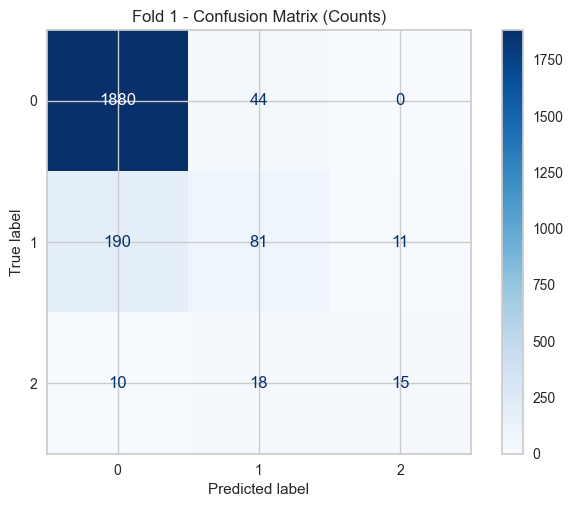

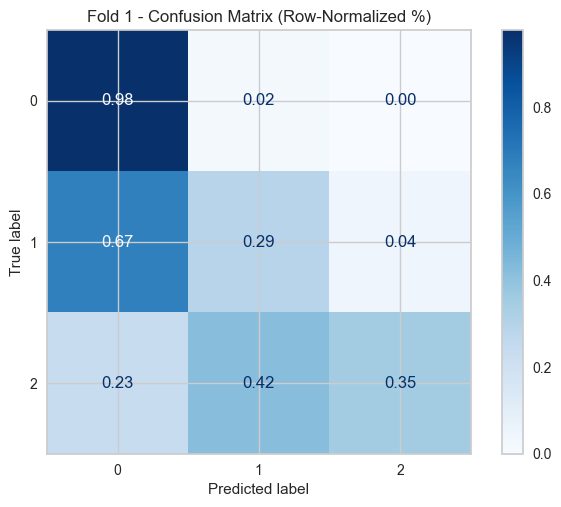

[Fold 1] Acc=0.879  F1(macro)=0.585  F1(weighted)=0.859
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008717 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32946
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


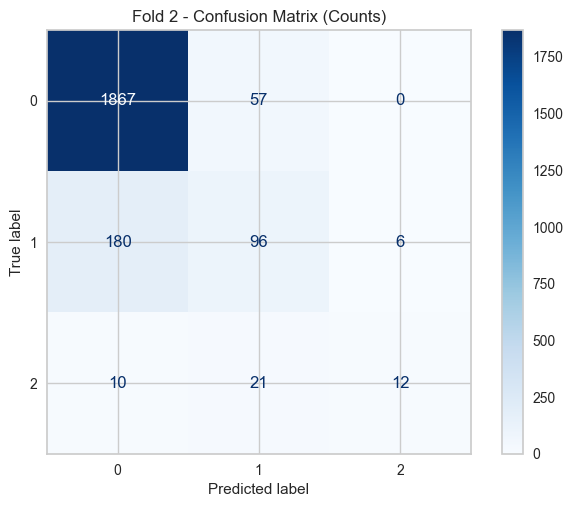

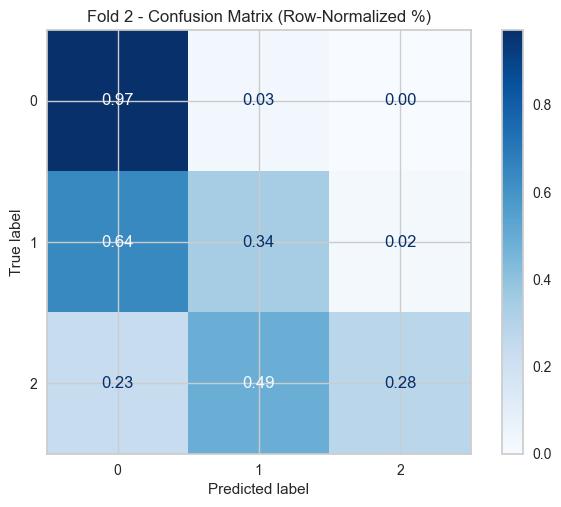

[Fold 2] Acc=0.878  F1(macro)=0.584  F1(weighted)=0.863
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009850 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33165
[LightGBM] [Info] Number of data points in the train set: 23082, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


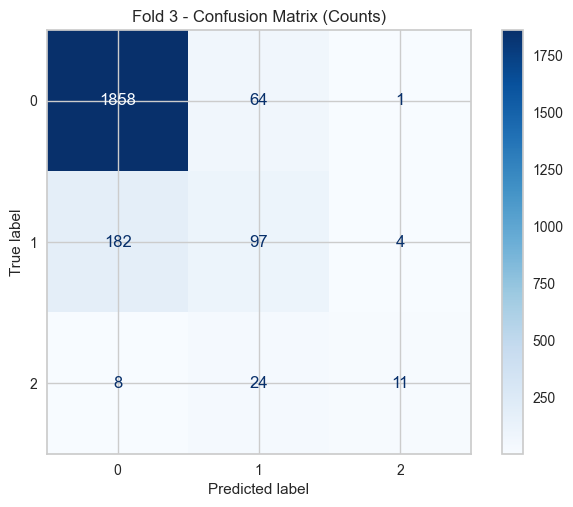

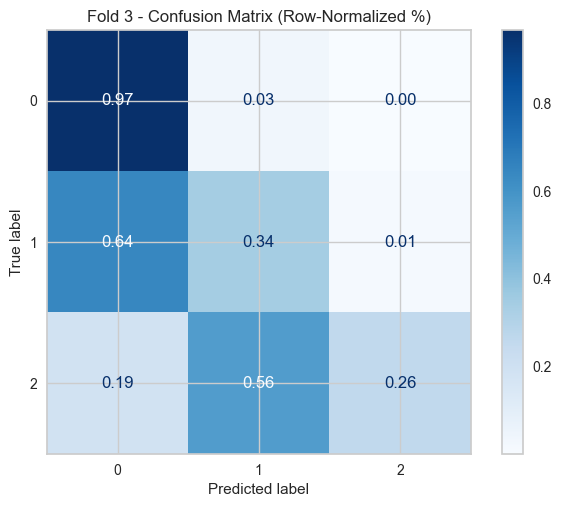

[Fold 3] Acc=0.874  F1(macro)=0.574  F1(weighted)=0.859
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32785
[LightGBM] [Info] Number of data points in the train set: 23082, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


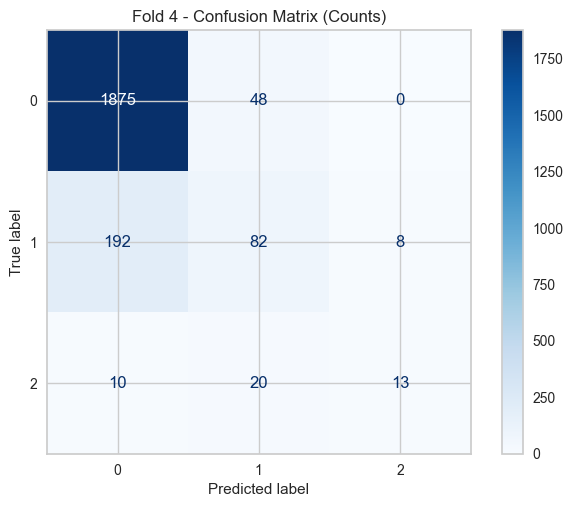

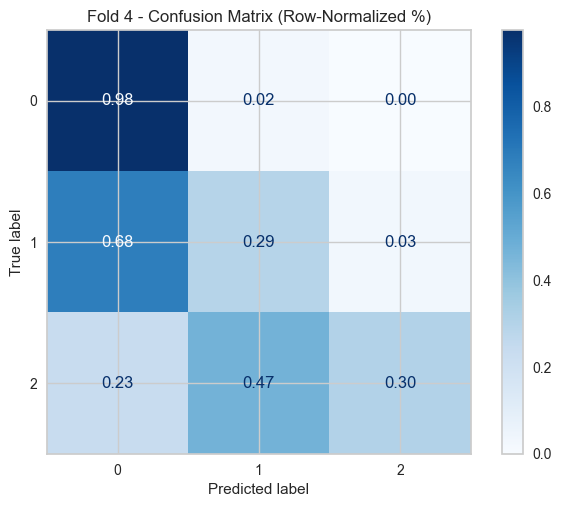

[Fold 4] Acc=0.876  F1(macro)=0.574  F1(weighted)=0.857
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010808 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33050
[LightGBM] [Info] Number of data points in the train set: 23082, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


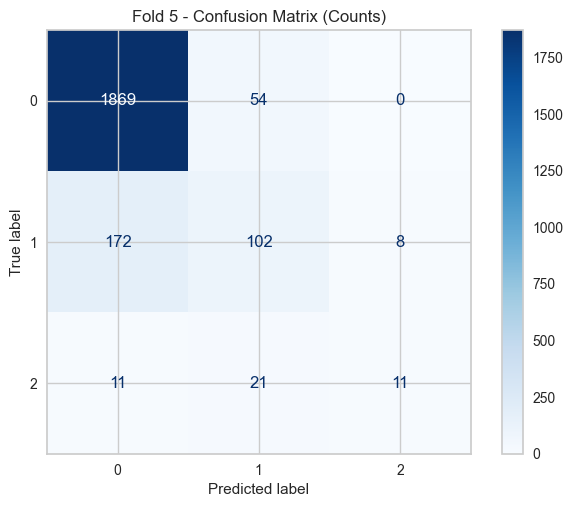

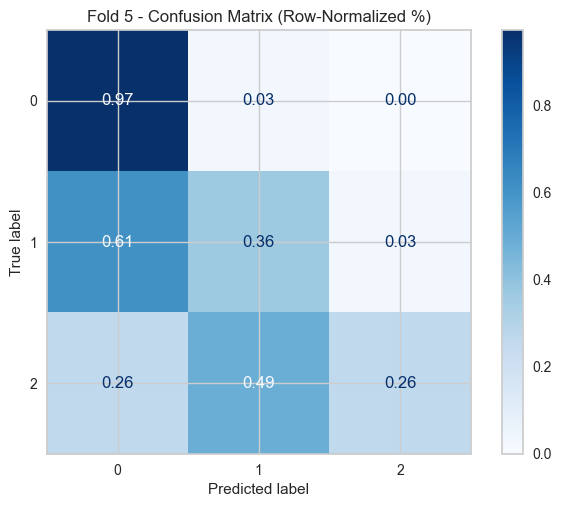

[Fold 5] Acc=0.882  F1(macro)=0.580  F1(weighted)=0.867


In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
labels = np.unique(y)

# DataFrame/ndarray 모두 지원하는 인덱싱 헬퍼
def take(a, idx):
    return a.iloc[idx] if hasattr(a, "iloc") else a[idx]

for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = take(X, tr_idx), take(X, te_idx)
    y_tr, y_te = take(y, tr_idx), take(y, te_idx)

    model_cv = clone(pipe)        # 파이프라인을 폴드마다 새로 복제
    model_cv.fit(X_tr, y_tr)
    y_pred = model_cv.predict(X_te)

    # #5) Counts
    cm_counts = confusion_matrix(y_te, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm_counts, display_labels=labels).plot(
        cmap='Blues', values_format='d'
    )
    plt.title(f"Fold {fold} - Confusion Matrix (Counts)")
    plt.show()

    # #6) Row-Normalized: %
    cm_row = confusion_matrix(y_te, y_pred, labels=labels, normalize='true')
    ConfusionMatrixDisplay(cm_row, display_labels=labels).plot(
        cmap='Blues', values_format='.2f'
    )
    plt.title(f"Fold {fold} - Confusion Matrix (Row-Normalized %)")
    plt.show()

    # 옵션: 점수도 보고 싶으면
    print(f"[Fold {fold}] Acc={accuracy_score(y_te, y_pred):.3f}  "
          f"F1(macro)={f1_score(y_te, y_pred, average='macro'):.3f}  "
          f"F1(weighted)={f1_score(y_te, y_pred, average='weighted'):.3f}")


## optuna 하이퍼파라미터 튜닝

In [92]:
df_new['burnout60'].unique()

[0, 1, 2]
Categories (3, int64): [0, 1, 2]

In [93]:
# (전제) df_new['burnout60']가 0/1/2 정수로 정리된 상태

from pycaret.classification import setup, create_model, get_config
import pandas as pd

# 범주형 자동 지정(타깃은 제외)
cats = df_new.select_dtypes(include=['object','category']).columns.tolist()
if 'burnout60' in cats: 
    cats.remove('burnout60')

s = setup(
    data=df_new,
    target='burnout60',
    train_size=0.8,
    # categorical_features=cats,                 # 직접 만든 categories가 있으면 그걸 넣어도 됨
    categorical_features= categories,
    # ignore_features=[c for c in ['id','area'] if c in df_new.columns],
    fold=5,
    n_jobs=-1,
    session_id=1234,
    # fix_imbalance=True,                      # 불균형이면 옵션으로 켜기
)

# (권장) 파이프라인 고정용으로 간단 모델 하나 생성
_ = create_model('lightgbm')

# 전처리된 데이터는 “새로” 꺼내 쓰기 (예전 변수/객체 재사용 X)
Xtr_df = get_config('X_train_transformed'); ytr = get_config('y_train')
Xte_df = get_config('X_test_transformed');  yte = get_config('y_test')


,Description,Value
0,Session id,1234
1,Target,burnout60
2,Target type,Multiclass
3,Original data shape,"(11243, 172)"
4,Transformed data shape,"(11243, 554)"
5,Transformed train set shape,"(8994, 554)"
6,Transformed test set shape,"(2249, 554)"
7,Categorical features,170
8,Preprocess,True
9,Imputation type,simple


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8777,0.8913,0.8777,0.8523,0.8556,0.3720,0.4045
1,0.8733,0.8789,0.8733,0.8491,0.8522,0.3626,0.3875
2,0.8733,0.8416,0.8733,0.8463,0.8471,0.3246,0.3651
3,0.8766,0.8849,0.8766,0.8529,0.8565,0.3853,0.4103
4,0.8710,0.8739,0.8710,0.8470,0.8525,0.3679,0.3872
Mean,0.8744,0.8741,0.8744,0.8495,0.8528,0.3625,0.3909
Std,0.0025,0.0173,0.0025,0.0027,0.0033,0.0204,0.0158


In [94]:
!pip install optuna

In [95]:
### optuna 하이퍼파라미터 튜닝

import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [96]:
df_new['burnout60'].unique()

[0, 1, 2]
Categories (3, int64): [0, 1, 2]

In [97]:
df['burnout60'].value_counts()

burnout60
lv1    12595
lv2     2026
lv3      335
Name: count, dtype: int64

In [98]:
df['burnout60'].value_counts(normalize = True)

burnout60
lv1    0.842137
lv2    0.135464
lv3    0.022399
Name: proportion, dtype: float64

In [99]:
df.columns

Index(['id', 'burnout60', 'area', 'gender', 'wtime_length5', 'age_group',
       'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group',
       ...
       'edu', 'marital', 'children', 'panel_survey', 'heal_abs1_group',
       'ctime_group', 'disc_group', 'decla_group', 'winten2_group',
       'winten3_group'],
      dtype='object', length=172)

In [100]:
# 데이터 분할
# 전체 데이터
X = df_new.drop(columns=['burnout60', 'id', 'area']).values
y = df_new['burnout60'].values

print("X 데이터: ", X.shape)
print("y 데이터: ", y.shape)

X 데이터:  (11243, 169)
y 데이터:  (11243,)


In [101]:
# 데이터 분할 = 훈련 데이터 / 테스트 데이터 = 8:2
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    stratify = y, # 클래스 분포 비율 맞추기
                                                    random_state = 42)
print("train 데이터: ", X_train.shape)
print("test 데이터: ", X_test.shape)

train 데이터:  (8994, 169)
test 데이터:  (2249, 169)


In [102]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True))

0    7693
1    1129
2     172
Name: count, dtype: int64
0    0.855348
1    0.125528
2    0.019124
Name: proportion, dtype: float64


In [ ]:
### 불균형이 큰 데이터에 적함한 objective 함수

import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn import svm
from lightgbm import LGBMClassifier

def objective(trial):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    k_smote = trial.suggest_int('smote_k', 3, 7)  # 소수 클래스가 매우 적으면 3 권장

    params = {
        'n_estimators': trial.suggest_int('lgbm_n_estimators', 300, 1200, step=100),
        'learning_rate': trial.suggest_float('lgbm_lr', 1e-3, 2e-1, log=True),
        'num_leaves': trial.suggest_int('lgbm_num_leaves', 31, 255, step=8),
        'max_depth': trial.suggest_int('lgbm_max_depth', -1, 16),
        'min_child_samples': trial.suggest_int('lgbm_min_child', 5, 60, step=5),
        'subsample': trial.suggest_float('lgbm_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('lgbm_colsample', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('lgbm_reg_alpha', 1e-8, 1e-1, log=True),
        'reg_lambda': trial.suggest_float('lgbm_reg_lambda', 1e-8, 1e-1, log=True),
        'class_weight': 'balanced',
        'random_state': 42, 'n_jobs': -1
    }
    clf = LGBMClassifier(**params)
    pipe = ImbPipeline([
        # ('scaler', StandardScaler()),      # LGBM엔 필수는 아니지만 수치 안정화에 무해
        ('smote', SMOTE(random_state=42, k_neighbors=k_smote)),
        ('clf', clf)
    ])

    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1).mean()


In [104]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

[I 2025-09-02 09:55:05,241] A new study created in memory with name: no-name-6460f693-8fc4-4a4a-9f30-b2169f4bdee4
[I 2025-09-02 09:55:18,152] Trial 0 finished with value: 0.5309535215231364 and parameters: {'classifier': 'SVC', 'smote_k': 6, 'svc_C': 357.10156759873985, 'svc_gamma': 'scale'}. Best is trial 0 with value: 0.5309535215231364.
[I 2025-09-02 09:55:24,852] Trial 1 finished with value: 0.5731180410252795 and parameters: {'classifier': 'LGBM', 'smote_k': 7, 'lgbm_n_estimators': 300, 'lgbm_lr': 0.10575273498942828, 'lgbm_num_leaves': 47, 'lgbm_max_depth': 5, 'lgbm_min_child': 20, 'lgbm_subsample': 0.7852964860949995, 'lgbm_colsample': 0.803527293909623, 'lgbm_reg_alpha': 5.440224056690192e-05, 'lgbm_reg_lambda': 1.0343390518939957e-06, 'lambda_l1': 1.2044288892099677e-05, 'lambda_l2': 1.5849168193269828e-07}. Best is trial 1 with value: 0.5731180410252795.
[I 2025-09-02 09:55:39,067] Trial 2 finished with value: 0.5715382143415796 and parameters: {'classifier': 'LGBM', 'smote_k

In [105]:
# 시행된 trial 중 최적의 하이퍼파라미터 반환하는 메소드
print(study.best_trial.params)

# 시행된 trial 중 가장 높은 값 반환하는 메소드
optuna_acc = study.best_trial.value
print(optuna_acc)

{'classifier': 'LGBM', 'smote_k': 4, 'lgbm_n_estimators': 700, 'lgbm_lr': 0.11980555976011092, 'lgbm_num_leaves': 215, 'lgbm_max_depth': 3, 'lgbm_min_child': 25, 'lgbm_subsample': 0.7765565286889409, 'lgbm_colsample': 0.7022872856440429, 'lgbm_reg_alpha': 2.2570787005826755e-08, 'lgbm_reg_lambda': 0.054050497421780204, 'lambda_l1': 0.00021242962300299648, 'lambda_l2': 0.0014986767040911027}
0.6065330636074909


In [106]:
# Optuna 내장 시각화 코드
# 하이퍼파라미터별 중요도를 확인할 수 있는 그래프
optuna.visualization.plot_param_importances(study)

In [107]:
# 하이퍼파라미터 최적화 과정을 확인 = 매 trial 마다 loss 가 어떻게 감소되었는지 확인
optuna.visualization.plot_optimization_history(study)

In [108]:
print('Number of finished trials: {}'.format(len(study.trials)))
print('Best trial:')
trial = study.best_trial

print('  Value: {}'.format(trial.value))
print('  Params: ')

for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))

Number of finished trials: 100
Best trial:
  Value: 0.6065330636074909
  Params: 
    classifier: LGBM
    smote_k: 4
    lgbm_n_estimators: 700
    lgbm_lr: 0.11980555976011092
    lgbm_num_leaves: 215
    lgbm_max_depth: 3
    lgbm_min_child: 25
    lgbm_subsample: 0.7765565286889409
    lgbm_colsample: 0.7022872856440429
    lgbm_reg_alpha: 2.2570787005826755e-08
    lgbm_reg_lambda: 0.054050497421780204
    lambda_l1: 0.00021242962300299648
    lambda_l2: 0.0014986767040911027


## “클래스 2의 맞춤 임계값(threshold)”을 검증셋에서 찾는 코드

In [109]:
###“클래스 2의 맞춤 임계값(threshold)”을 검증셋에서 찾는 코드

from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import f1_score

# train → (train/val)로 8:2 재분할
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# 모델/파이프라인 이름에 맞춰 사용 (예: pipe)
pipe.fit(X_tr, y_tr)

# --- 검증셋에서 클래스2 임계값 t 찾기 ---
proba_val = pipe.predict_proba(X_val)
c2 = list(pipe.classes_).index(2)

best_t, best_f1 = 0.5, -1
for t in np.linspace(0.2, 0.8, 31):
    y_hat = np.argmax(proba_val, axis=1)
    y_hat = np.where(proba_val[:, c2] >= t, 2, y_hat)
    f1_c2 = f1_score(y_val, y_hat, labels=[2], average='macro')
    if f1_c2 > best_f1:
        best_f1, best_t = f1_c2, t

print(f"Best threshold for class 2 = {best_t:.2f} (F1_cls2={best_f1:.3f})")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32419
[LightGBM] [Info] Number of data points in the train set: 18462, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Best threshold for class 2 = 0.20 (F1_cls2=0.522)


In [110]:
# 전체 train으로 재학습
pipe.fit(X_train, y_train)

# 테스트 적용
proba_test = pipe.predict_proba(X_test)
y_pred = np.argmax(proba_test, axis=1)
y_pred = np.where(proba_test[:, c2] >= best_t, 2, y_pred)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33040
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


In [111]:
### 클래스 2만 과샘플링 (SMOTE 타겟팅)

from imblearn.over_sampling import SMOTE

# y_train 에서 클래스 분포 확인 후, 2번을 원하는 수로 늘리기 (예: 2번을 1만개로)
smote = SMOTE(sampling_strategy={2: 10000}, random_state=42, k_neighbors=3)
Xtr, ytr = smote.fit_resample(X_train, y_train)


In [112]:
### 2) LGBM에 클래스 가중치 주기 (2번 가중 ↑)

from collections import Counter
import numpy as np
from lightgbm import LGBMClassifier

# 기본 가중치에서 2번만 2~5배 올려보기
counts = Counter(ytr)  # resample 후 분포 기준이 자연스러움
class_weight = {c: 1.0 for c in counts}
class_weight[2] = 3.0  # <- 튜닝 포인트

clf = LGBMClassifier(
    random_state=42,
    class_weight=class_weight,   # 멀티클래스에서도 dict 가능
    n_estimators=600,
    learning_rate=0.05
)
clf.fit(Xtr, ytr)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37933
[LightGBM] [Info] Number of data points in the train set: 18822, number of used features: 162
[LightGBM] [Info] Start training from score -1.618676
[LightGBM] [Info] Start training from score -3.537655
[LightGBM] [Info] Start training from score -0.257790


LGBMClassifier(boosting_type='gbdt', class_weight={0: 1.0, 1: 1.0, 2: 3.0},
               colsample_bytree=1.0, importance_type='split',
               learning_rate=0.05, max_depth=-1, min_child_samples=20,
               min_child_weight=0.001, min_split_gain=0.0, n_estimators=600,
               n_jobs=None, num_leaves=31, objective=None, random_state=42,
               reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [113]:
### “클래스 2 전용” 평가지표로 튜닝/보고
### 학습 뒤에 전체 평균이 아니라 2번의 Precision/Recall/F1

from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))  # 표 전체

# 클래스 2만 따로
p2, r2, f12, _ = precision_recall_fscore_support(y_test, y_pred, labels=[2], average='macro')
print(f"[Class 2] Precision={p2:.3f}  Recall={r2:.3f}  F1={f12:.3f}")


              precision    recall  f1-score   support

           0      0.909     0.971     0.939      1924
           1      0.554     0.330     0.413       282
           2      0.654     0.395     0.493        43

    accuracy                          0.880      2249
   macro avg      0.706     0.566     0.615      2249
weighted avg      0.860     0.880     0.865      2249

[Class 2] Precision=0.654  Recall=0.395  F1=0.493


In [114]:
### 목적함수를 클래스 2의 F1로 바꾸기

from sklearn.metrics import make_scorer, f1_score
scorer_f1_cls2 = make_scorer(
    f1_score, average='macro', labels=[2]
)  # 멀티클래스에서 라벨 2만 평가

# cross_val_score(..., scoring=scorer_f1_cls2) 혹은 Optuna objective에서 사용


In [115]:
import numpy as np
from sklearn.metrics import f1_score

# --- 1) 검증셋에서 클래스2 임계값 탐색 ---
proba_val = clf.predict_proba(X_val)          # 예측 확률 (n_samples, n_classes)
classes_  = clf.classes_                      # 모델이 인식한 클래스 라벨
# 클래스 2의 열 인덱스 찾기 (라벨이 문자열/정수 어떤 형태여도 동작)
c2_idx = np.where(classes_ == 2)[0][0]

best_t, best_f1 = 0.5, -1.0
for t in np.linspace(0.2, 0.8, 31):           # 임계값 탐색 범위/간격
    y_hat = np.argmax(proba_val, axis=1)      # 기본 argmax 예측
    # class2 확률이 t 이상이면 2로 강제 예측
    y_hat = np.where(proba_val[:, c2_idx] >= t, 2, y_hat)

    # ⚠️ 반드시 y_val(정답)로 평가해야 함 (X 아님!)
    f1_c2 = f1_score(y_val, y_hat, labels=[2], average='macro')

    if f1_c2 > best_f1:
        best_f1, best_t = f1_c2, t

print(f"Best threshold for class 2 = {best_t:.2f} (F1_cls2={best_f1:.3f})")

# --- 2) 최종 학습(원하면 전체 train으로 재학습) 후 테스트에 적용 ---
# clf.fit(X_train, y_train)  # 필요 시 주석 해제해 전체 train으로 재학습

proba_test = clf.predict_proba(X_test)
y_pred = np.argmax(proba_test, axis=1)
y_pred = np.where(proba_test[:, c2_idx] >= best_t, 2, y_pred)


Best threshold for class 2 = 0.20 (F1_cls2=1.000)


In [116]:
### 1) 공통 헬퍼 함수 (같은 코드 여러 번 쓰다 생기는 버그 줄임)

import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, roc_auc_score)
import matplotlib.pyplot as plt

# --- 임계값 적용 예측 (클래스 2 확률이 t 이상이면 2로 교체) ---
def predict_with_c2_threshold(clf, X, t):
    proba = clf.predict_proba(X)
    classes_ = clf.classes_
    c2_idx = np.where(classes_ == 2)[0][0]  # 라벨이 문자열이어도 자동 처리
    y_hat = np.argmax(proba, axis=1)
    y_hat = np.where(proba[:, c2_idx] >= t, 2, y_hat)
    return y_hat, proba, classes_

# --- 민감도/특이도(다중분류 → one-vs-rest) ---
def sens_spec_table(y_true, y_pred, labels=None):
    labels = np.unique(y_true) if labels is None else labels
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    total = cm.sum()
    rows = []
    for i, c in enumerate(labels):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FP - FN
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # = recall
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        rows.append([c, sensitivity, specificity, TP, FP, FN, TN])
    return pd.DataFrame(rows, columns=["class", "sensitivity(Recall)", "specificity", "TP", "FP", "FN", "TN"])

# --- ROC 곡선(다중분류) 그리기 ---
def plot_multiclass_roc(y_true, proba, classes, title="ROC (multiclass)"):
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_true, classes=classes)
    fpr, tpr, roc_auc = {}, {}, {}
    for i, c in enumerate(classes):
        fpr[c], tpr[c], _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc[c] = auc(fpr[c], tpr[c])
    # micro/macro
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    roc_auc["macro"] = np.mean([roc_auc[c] for c in classes])

    plt.figure(figsize=(7,6))
    for c in classes:
        plt.plot(fpr[c], tpr[c], label=f"{c} (AUC={roc_auc[c]:.3f})")
    plt.plot(fpr["micro"], tpr["micro"], linestyle="--", label=f"micro (AUC={roc_auc['micro']:.3f})", color="black")
    plt.plot([0,1],[0,1], linestyle=":", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()
    return roc_auc


In [117]:
### 2) 학습/테스트 예측 (클래스2 임계값 적용)

# 학습 데이터
y_pred_tr, proba_tr, classes_ = predict_with_c2_threshold(clf, X_train, best_t)
# 테스트 데이터
y_pred_te, proba_te, _        = predict_with_c2_threshold(clf, X_test,  best_t)


In [118]:
### 3) “모델 성능 비교표” 만들기 (정확도/정밀도/재현율/F1)

from sklearn.metrics import f1_score

def summary_row(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    # 클래스 2 전용 지표(관심 클래스)
    p2, r2, f12, _ = precision_recall_fscore_support(y_true, y_pred, labels=[2], average='macro', zero_division=0)
    return {
        "set": tag,
        "accuracy": acc,
        "precision_macro": p_macro, "recall_macro": r_macro, "f1_macro": f1_macro,
        "precision_weighted": p_weight, "recall_weighted": r_weight, "f1_weighted": f1_weight,
        "precision_cls2": p2, "recall_cls2": r2, "f1_cls2": f12
    }

summary = pd.DataFrame([
    summary_row(y_train, y_pred_tr, "train"),
    summary_row(y_test,  y_pred_te, "test")
])
print(summary.round(3))


     set  accuracy  precision_macro  recall_macro  f1_macro  \
0  train      1.00            1.000         1.000     1.000   
1   test      0.88            0.686         0.594     0.627   

   precision_weighted  recall_weighted  f1_weighted  precision_cls2  \
0               1.000             1.00        1.000           1.000   
1               0.861             0.88        0.866           0.583   

   recall_cls2  f1_cls2  
0        1.000    1.000  
1        0.488    0.532  


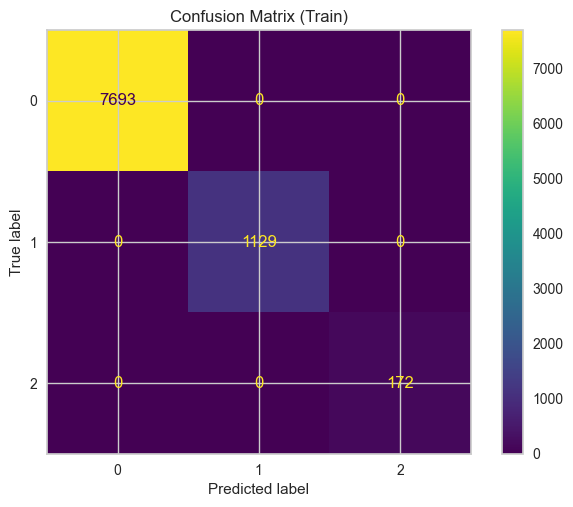

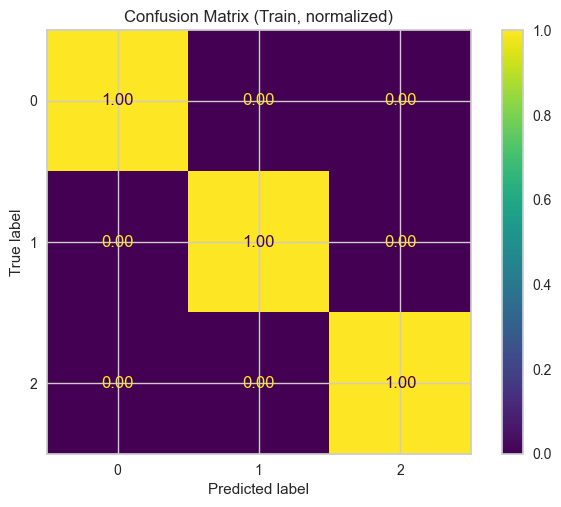

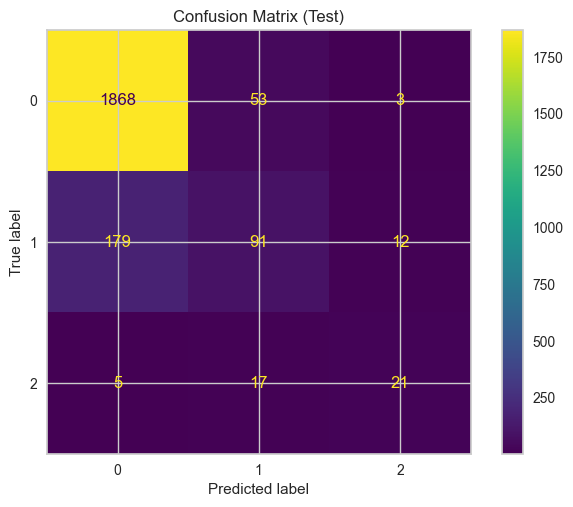

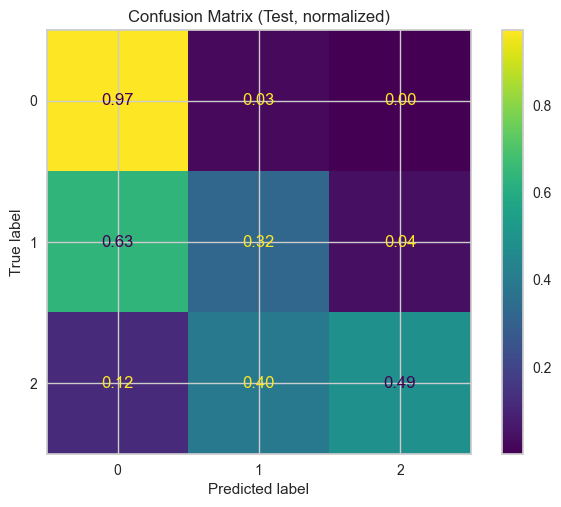

Train sensitivity/specificity by class:
    class  sensitivity(Recall)  specificity    TP  FP  FN    TN
0      0                  1.0          1.0  7693   0   0  1301
1      1                  1.0          1.0  1129   0   0  7865
2      2                  1.0          1.0   172   0   0  8822

Test sensitivity/specificity by class:
    class  sensitivity(Recall)  specificity    TP   FP   FN    TN
0      0                0.971        0.434  1868  184   56   141
1      1                0.323        0.964    91   70  191  1897
2      2                0.488        0.993    21   15   22  2191


In [119]:
### 4) 혼동행렬(카운트/정규화) + 민감도/특이도 표

# 혼동행렬 - 학습
cm_tr = confusion_matrix(y_train, y_pred_tr, labels=classes_)
ConfusionMatrixDisplay(cm_tr, display_labels=classes_).plot(values_format="d")
plt.title("Confusion Matrix (Train)")
plt.show()

cmn_tr = confusion_matrix(y_train, y_pred_tr, labels=classes_, normalize='true')
ConfusionMatrixDisplay(cmn_tr, display_labels=classes_).plot(values_format=".2f")
plt.title("Confusion Matrix (Train, normalized)")
plt.show()

# 혼동행렬 - 테스트
cm_te = confusion_matrix(y_test, y_pred_te, labels=classes_)
ConfusionMatrixDisplay(cm_te, display_labels=classes_).plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

cmn_te = confusion_matrix(y_test, y_pred_te, labels=classes_, normalize='true')
ConfusionMatrixDisplay(cmn_te, display_labels=classes_).plot(values_format=".2f")
plt.title("Confusion Matrix (Test, normalized)")
plt.show()

# 민감도/특이도
sensspec_tr = sens_spec_table(y_train, y_pred_tr, labels=classes_)
sensspec_te = sens_spec_table(y_test,  y_pred_te, labels=classes_)
print("Train sensitivity/specificity by class:\n", sensspec_tr.round(3))
print("\nTest sensitivity/specificity by class:\n", sensspec_te.round(3))


In [120]:
### 학습/테스트의 정확도·정밀도·재현율·F1과 클래스 2 전용 지표, 그리고 목표치 대비 PASS/FAIL

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# --- 임계값 적용 예측 (클래스 2 확률이 t 이상이면 2로 예측 보정) ---
def predict_with_c2_threshold(clf, X, t):
    proba = clf.predict_proba(X)
    classes_ = clf.classes_
    # 라벨이 문자열일 수도 있으니 안전하게 찾기
    c2_idx = np.where(classes_ == 2)[0][0] if 2 in set(classes_) else np.where(classes_.astype(str) == "2")[0][0]
    y_hat = np.argmax(proba, axis=1)
    y_hat = np.where(proba[:, c2_idx] >= t, 2, y_hat)
    return y_hat

# --- 한 세트의 요약 지표 ---
def summarize(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    p2, r2, f12, _   = precision_recall_fscore_support(y_true, y_pred, labels=[2], average='macro', zero_division=0)
    return {
        "set": tag,
        "accuracy": acc,
        "precision_macro": p_m, "recall_macro": r_m, "f1_macro": f1_m,
        "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f1_w,
        "precision_cls2": p2, "recall_cls2": r2, "f1_cls2": f12
    }

# --- 1) best_t 로 예측 만들기 ---
y_pred_train = predict_with_c2_threshold(clf, X_train, best_t)
y_pred_test  = predict_with_c2_threshold(clf, X_test,  best_t)

# --- 2) 표로 정리 ---
summary = pd.DataFrame([
    summarize(y_train, y_pred_train, "train"),
    summarize(y_test,  y_pred_test,  "test")
]).round(3)
print(summary)

# --- 3) 목표치 대비 PASS/FAIL ---
GOAL_F1_MACRO = 0.80      # <- 목표치 설정
GOAL_REC_C2   = 0.80      # <- (원하면 조정, 미설정이면 0.80으로 비교)

for row in summary.itertuples():
    f1_pass = "PASS" if row.f1_macro >= GOAL_F1_MACRO else "FAIL"
    r2_pass = "PASS" if row.recall_cls2 >= GOAL_REC_C2   else "FAIL"
    print(f"{row.set}: F1_macro={row.f1_macro:.3f} ({f1_pass}), "
          f"class2_recall={row.recall_cls2:.3f} ({r2_pass}), best_t={best_t:.3f}")


     set  accuracy  precision_macro  recall_macro  f1_macro  \
0  train      1.00            1.000         1.000     1.000   
1   test      0.88            0.686         0.594     0.627   

   precision_weighted  recall_weighted  f1_weighted  precision_cls2  \
0               1.000             1.00        1.000           1.000   
1               0.861             0.88        0.866           0.583   

   recall_cls2  f1_cls2  
0        1.000    1.000  
1        0.488    0.532  
train: F1_macro=1.000 (PASS), class2_recall=1.000 (PASS), best_t=0.200
test: F1_macro=0.627 (FAIL), class2_recall=0.488 (FAIL), best_t=0.200


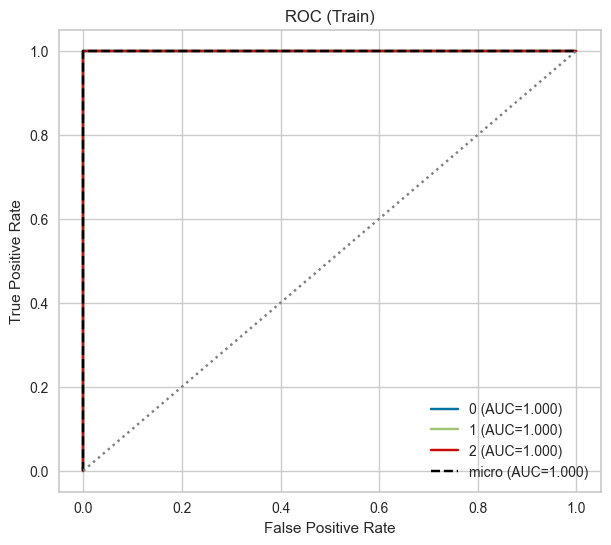

Train AUCs: {0: 1.0, 1: 1.0, 2: 1.0, 'micro': 1.0, 'macro': 1.0}


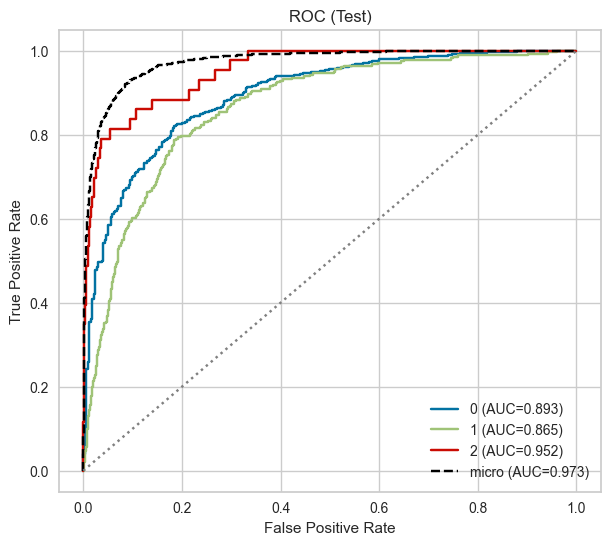

Test AUCs: {0: 0.893, 1: 0.865, 2: 0.952, 'micro': 0.973, 'macro': 0.904}


In [121]:
### 5) ROC 곡선 & AUC (학습/테스트)

# 학습 ROC
auc_tr = plot_multiclass_roc(y_train, proba_tr, classes_, title="ROC (Train)")
print("Train AUCs:", {k: round(v,3) for k,v in auc_tr.items()})

# 테스트 ROC
auc_te = plot_multiclass_roc(y_test, proba_te, classes_, title="ROC (Test)")
print("Test AUCs:", {k: round(v,3) for k,v in auc_te.items()})


## 파이프라인 준비

In [122]:
df_new.columns

Index(['id', 'burnout60', 'area', 'gender', 'wtime_length5', 'age_group',
       'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group',
       ...
       'edu', 'marital', 'children', 'panel_survey', 'heal_abs1_group',
       'ctime_group', 'disc_group', 'decla_group', 'winten2_group',
       'winten3_group'],
      dtype='object', length=172)

In [123]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11243 entries, 0 to 14955
Columns: 172 entries, id to winten3_group
dtypes: category(2), float64(133), int64(34), object(3)
memory usage: 14.9+ MB


In [124]:
df_new['burnout60'].unique()


[0, 1, 2]
Categories (3, int64): [0, 1, 2]

In [125]:
# 타겟 클래스번호 전처리
df_new['burnout60'] = df_new['burnout60'].replace("lv1", 1)
df_new['burnout60'] = df_new['burnout60'].replace("lv2", 2)
df_new['burnout60'] = df_new['burnout60'].replace("lv3", 3)
df_new['burnout60'].unique()

[0, 1, 2]
Categories (3, int64): [0, 1, 2]

In [126]:
df_new = df_new.copy()                              # 핵심
df_new['burnout60'] = df_new['burnout60'].map({1: 0, 2: 1, 3: 2})


In [127]:
df_new['burnout60'].unique()

array([nan,  0.,  1.])

In [128]:
# 데이터 분할
# 전체 데이터
X = df_new.drop(columns=['id','burnout60','area']).values
y = df_new['burnout60'].values

print("X 데이터: ", X.shape)
print("y 데이터: ", y.shape)

X 데이터:  (11243, 169)
y 데이터:  (11243,)


In [129]:
df_new['burnout60'].unique()

array([nan,  0.,  1.])

## class 1의 과접합을 줄이기 위해 가중치(class_weight)만 낮춤

In [130]:
# ===============================
# Fix class-0 overfit: Under(0) + SMOTE(2) + class_weight + t0
# ===============================
import numpy as np
import pandas as pd
from collections import Counter

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, recall_score, classification_report

# --- 0) 전략 함수: fold마다 안전하게 목표 개수 계산 (피클 가능하도록 top-level 함수로) ---
def _targets_from_y(y, ratio0=1.3, ratio2=0.8):
    """
    ratio0: 언더샘플링 후 class0 목표를 class1의 ratio0배로 (예: 1.3배)
    ratio2: 오버샘플링 후 class2 목표를 class1의 ratio2배로 (예: 0.8배)
    """
    cnt = Counter(y)
    n0, n1, n2 = cnt.get(0,0), cnt.get(1,0), cnt.get(2,0)
    tgt0 = int(min(n0, max(2, round(n1*ratio0))))  # 0은 줄이되 현재 n0보다 클 수 없음
    tgt2 = int(max(n2+1, round(n1*ratio2)))        # 2는 올리되 현재보다 크게
    return tgt0, tgt2

def smote_strategy(y):
    _, tgt2 = _targets_from_y(y, ratio0=1.3, ratio2=0.8)
    return {2: tgt2}   # 2만 증폭

def under_strategy(y):
    tgt0, _ = _targets_from_y(y, ratio0=1.3, ratio2=0.8)
    return {0: tgt0}   # 0만 축소

# SMOTE k 이웃수는 소수클래스 표본-1 이하여야 함 → 보수적으로 3 사용(부족하면 1~2로 낮추기)
K_SMOTE = 3

# --- 1) 파이프라인 구성 ---
lgbm = LGBMClassifier(
    n_estimators=600, learning_rate=0.05, num_leaves=63,
    random_state=42, n_jobs=-1,
    # 0은 약간 ↓, 2는 ↑ (필요시 수치 미세조정)
    class_weight={0:0.75, 1:1.0, 2:1.4}
)

pipe = ImbPipeline([
    ('smote2', SMOTE(sampling_strategy=smote_strategy, k_neighbors=K_SMOTE, random_state=42)),
    ('under0', RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)),
    ('clf',    lgbm),
])

# --- 2) OOF로 성능 확인 (누수 없이 fold별로 샘플링·학습) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_oof = cross_val_predict(pipe, X_train, y_train, cv=skf, method="predict", n_jobs=-1)
print("\n[OOF] classification report")
print(classification_report(y_train, y_pred_oof, digits=3))

labels = [0,1,2]
cm = confusion_matrix(y_train, y_pred_oof, labels=labels)
cmn = cm / cm.sum(axis=1, keepdims=True)
print("\n[OOF] Confusion Matrix (Counts)"); print(pd.DataFrame(cm, index=labels, columns=labels))
print("\n[OOF] Confusion Matrix (Row-Normalized, %)"); print(pd.DataFrame((cmn*100).round(2), index=labels, columns=labels))

print("\n[OOF] F1_macro={:.3f} | F1_weighted={:.3f}".format(
    f1_score(y_train, y_pred_oof, average='macro'),
    f1_score(y_train, y_pred_oof, average='weighted'))
)

rec_per_cls = recall_score(y_train, y_pred_oof, average=None, labels=labels)
print("[OOF] Recall per class:", {c: round(r,3) for c,r in zip(labels, rec_per_cls)})

# --- 3) (선택) class-0 임계값 올리기(t0)로 0으로의 오분류 억제 ---
def predict_with_tmap(proba, classes, t_map):
    classes = np.array(classes)
    t = np.array([t_map.get(c, 1.0) for c in classes], dtype=float)
    t = np.maximum(t, 1e-12)
    scores = proba / t[None, :]
    cand = scores.argmax(axis=1)
    ok   = proba[np.arange(len(proba)), cand] >= t[cand]
    return np.where(ok, classes[cand], classes[proba.argmax(axis=1)])

# 검증용 확률 OOF가 필요하면:
y_proba_oof = cross_val_predict(pipe, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)
classes = np.array(labels)

best_t0, best = 0.5, -1
for t in np.linspace(0.55, 0.95, 9):   # 0 임계값을 0.55~0.95로 탐색
    y_hat = predict_with_tmap(y_proba_oof, classes, {0: float(t)})
    s = f1_score(y_train, y_hat, average='macro')
    if s > best:
        best, best_t0 = s, float(t)

print(f"\n[tuning] Best t0={best_t0:.2f} (OOF F1_macro={best:.3f})")

y_pred_t0 = predict_with_tmap(y_proba_oof, classes, {0: best_t0})
cm_t0 = confusion_matrix(y_train, y_pred_t0, labels=labels)
print("\n[OOF|t0] Confusion Matrix (Counts)"); print(pd.DataFrame(cm_t0, index=labels, columns=labels))

# 0으로 빨려들기(1→0, 2→0) 변화 체크
def shift_to_0(y_true, y_a, y_b, labels=[0,1,2], name_a="base", name_b="t0"):
    cm_a = confusion_matrix(y_true, y_a, labels=labels)
    cm_b = confusion_matrix(y_true, y_b, labels=labels)
    d_1_to_0 = cm_b[1,0] - cm_a[1,0]
    d_2_to_0 = cm_b[2,0] - cm_a[2,0]
    print(f"[{name_a}→{name_b}] Δ(1→0)={d_1_to_0}   Δ(2→0)={d_2_to_0}")

shift_to_0(y_train, y_pred_oof, y_pred_t0)



[OOF] classification report
              precision    recall  f1-score   support

           0      0.953     0.822     0.883      7693
           1      0.355     0.715     0.474      1129
           2      0.667     0.302     0.416       172

    accuracy                          0.799      8994
   macro avg      0.658     0.613     0.591      8994
weighted avg      0.872     0.799     0.822      8994


[OOF] Confusion Matrix (Counts)
      0     1   2
0  6325  1364   4
1   300   807  22
2    15   105  52

[OOF] Confusion Matrix (Row-Normalized, %)
       0      1      2
0  82.22  17.73   0.05
1  26.57  71.48   1.95
2   8.72  61.05  30.23

[OOF] F1_macro=0.591 | F1_weighted=0.822
[OOF] Recall per class: {0: 0.822, 1: 0.715, 2: 0.302}

[tuning] Best t0=0.55 (OOF F1_macro=0.591)

[OOF|t0] Confusion Matrix (Counts)
      0     1   2
0  6325  1364   4
1   300   807  22
2    15   105  52
[base→t0] Δ(1→0)=0   Δ(2→0)=0


In [131]:
import optuna
from collections import Counter
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
min_count = min(Counter(y_train).values())
kmax = max(1, min(10, min_count - 1))   # 소수클래스 개수-1을 넘지 않게

def objective(trial):
    # SMOTE: not majority 고정, k_neighbors만 안전 범위에서 튠
    k_neighbors = trial.suggest_int("k_neighbors", 1, kmax)

    smote = SMOTE(
        sampling_strategy='not majority',
        k_neighbors=k_neighbors,
        random_state=42
    )

    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
        'reg_alpha': trial.suggest_float('lgbm_reg_alpha', 1e-8, 1e-1, log=True),
        'reg_lambda': trial.suggest_float('lgbm_reg_lambda', 1e-8, 1e-1, log=True), # lambda_l1/lambda_l2는 LightGBM에서 reg_alpha/reg_lambda와 동의어
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "class_weight":      {0:1.0, 1:0.8, 2:1.0},
        "random_state":      42
    }

    model = LGBMClassifier(**params)

    pipe = Pipeline([('smote', smote), ('clf', model)])
    score = cross_val_score(pipe, X_train, y_train,
                            cv=skf, scoring="f1_macro", n_jobs=-1).mean()
    return float(score)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

# 최적 하이퍼파라미터로 재학습
best_k = study.best_params.get("k_neighbors", 5)
smote_best = SMOTE(sampling_strategy='not majority',
                   k_neighbors=best_k, random_state=42)
model_best = LGBMClassifier(**{**study.best_params,
                               "class_weight": {0:1.0, 1:0.8, 2:1.0},
                               "random_state": 42})
pipe_best = Pipeline([('smote', smote_best), ('clf', model_best)])
pipe_best.fit(X_train, y_train)


[I 2025-09-02 10:29:21,559] A new study created in memory with name: no-name-217a36ba-790e-4065-8479-ab153e6a2273
[I 2025-09-02 10:29:45,891] Trial 0 finished with value: 0.5732580663765361 and parameters: {'k_neighbors': 9, 'n_estimators': 694, 'learning_rate': 0.10301428192694441, 'num_leaves': 25, 'min_child_samples': 34, 'lgbm_reg_alpha': 4.253609519321723e-06, 'lgbm_reg_lambda': 0.05988909780023975, 'subsample': 0.8362277330655451, 'colsample_bytree': 0.6339967836986508}. Best is trial 0 with value: 0.5732580663765361.
[I 2025-09-02 10:30:11,141] Trial 1 finished with value: 0.5681637786202964 and parameters: {'k_neighbors': 9, 'n_estimators': 817, 'learning_rate': 0.13053555689034996, 'num_leaves': 20, 'min_child_samples': 43, 'lgbm_reg_alpha': 1.710913888257611e-07, 'lgbm_reg_lambda': 2.820856896622541e-07, 'subsample': 0.9831595582372786, 'colsample_bytree': 0.9163617762581608}. Best is trial 0 with value: 0.5732580663765361.
[I 2025-09-02 10:30:35,824] Trial 2 finished with va

Best value: 0.5950277602430704
Best params: {'k_neighbors': 2, 'n_estimators': 725, 'learning_rate': 0.025407341162759146, 'num_leaves': 24, 'min_child_samples': 59, 'lgbm_reg_alpha': 3.0051102622579675e-07, 'lgbm_reg_lambda': 0.00013170669552270195, 'subsample': 0.7231868894895772, 'colsample_bytree': 0.8945232850667593}
[LightGBM] [Warning] Unknown parameter: k_neighbors
[LightGBM] [Warning] Unknown parameter: lgbm_reg_lambda
[LightGBM] [Warning] Unknown parameter: lgbm_reg_alpha
[LightGBM] [Warning] Unknown parameter: k_neighbors
[LightGBM] [Warning] Unknown parameter: lgbm_reg_lambda
[LightGBM] [Warning] Unknown parameter: lgbm_reg_alpha
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39729
[LightGBM] [Info] Number of data points in the train set: 23079, number of used features: 163
[LightGBM] [Info] Start training from score -1.029619
[Ligh

Pipeline(memory=None,
         steps=[('smote',
                 SMOTE(k_neighbors=2, random_state=42,
                       sampling_strategy='not majority')),
                ('clf',
                 LGBMClassifier(boosting_type='gbdt',
                                class_weight={0: 1.0, 1: 0.8, 2: 1.0},
                                colsample_bytree=0.8945232850667593,
                                importance_type='split', k_neighbors=2,
                                learning_rate=0.025407341162759146,
                                lgbm_reg_alpha=3.0051102622579675e-07,
                                lgbm_reg_lambda=0.00013170669552270195,
                                max_depth=-1, min_child_samples=59,
                                min_child_weight=0.001, min_split_gain=0.0,
                                n_estimators=725, n_jobs=None, num_leaves=24,
                                objective=None, random_state=42, reg_alpha=0.0,
                                reg_lambda=0.0, subsample=0.7231868894895772,
                                subsample_for_bin=200000, subsample_freq=0))],
         transform_input=None, verbose=False)

In [132]:
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_predict

labels = [0,1,2]

# --- OOF(교차검증 예측) ---
y_pred_oof = cross_val_predict(pipe_best, X_train, y_train, cv=skf, method="predict", n_jobs=-1)

rec_per_cls_oof = recall_score(y_train, y_pred_oof, average=None, labels=labels)
rec_macro_oof   = recall_score(y_train, y_pred_oof, average='macro')
rec_weight_oof  = recall_score(y_train, y_pred_oof, average='weighted')

print("\n[OOF] Recall per class:", {c: round(r,3) for c,r in zip(labels, rec_per_cls_oof)})
print("[OOF] Recall macro =", round(rec_macro_oof,3),
      " | weighted =", round(rec_weight_oof,3))
print("[OOF] Recall (class 1) =", round(rec_per_cls_oof[labels.index(1)], 3))



[OOF] Recall per class: {0: 0.977, 1: 0.284, 2: 0.355}
[OOF] Recall macro = 0.539  | weighted = 0.878
[OOF] Recall (class 1) = 0.284


In [133]:
print("Best value (CV f1_macro):", study.best_value)
print("Best params:", study.best_params)


Best value (CV f1_macro): 0.5950277602430704
Best params: {'k_neighbors': 2, 'n_estimators': 725, 'learning_rate': 0.025407341162759146, 'num_leaves': 24, 'min_child_samples': 59, 'lgbm_reg_alpha': 3.0051102622579675e-07, 'lgbm_reg_lambda': 0.00013170669552270195, 'subsample': 0.7231868894895772, 'colsample_bytree': 0.8945232850667593}


## 1) 학습 가중치: class 0 크게 ↓, class 2 크게 ↑

In [134]:
# 기존
# class_weight={0:0.85, 1:1.0, 2:1.8}

# 교체(강한 다운웨이트)
class_weight={0:0.50, 1:1.0, 2:2.0}
lgbm = LGBMClassifier(
    n_estimators=700, learning_rate=0.05, num_leaves=63,
    random_state=42, n_jobs=-1,
    class_weight={0:0.50, 1:1.0, 2:2.0}
)


In [135]:
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

def targets_from_y(y, ratio0=1.00, ratio2=1.20):
    """
    ratio0: 언더샘플 후 class0 목표 = class1 * ratio0   (<= 1.00로 강하게 억제)
    ratio2: 오버샘플 후 class2 목표 = class1 * ratio2   (>= 1.00로 class2 강화)
    """
    c = Counter(y); n0, n1, n2 = c.get(0,0), c.get(1,0), c.get(2,0)
    tgt0 = int(min(n0, max(2, round(n1*ratio0))))
    tgt2 = int(max(n2+1, round(n1*ratio2)))
    return tgt0, tgt2

def smote_strategy_c2(y):
    _, tgt2 = targets_from_y(y, ratio0=1.00, ratio2=1.20)  # 2를 class1의 120%까지
    return {2: tgt2}

def under_strategy_c0(y):
    tgt0, _ = targets_from_y(y, ratio0=1.00, ratio2=1.20)  # 0을 class1과 거의 동일수준으로
    return {0: tgt0}

K_SMOTE = 3  # 2 표본이 아주 적으면 1~2로 낮춰


In [136]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import recall_score, f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_oof = cross_val_predict(pipe, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)
labels = [0,1,2]; classes = np.array(labels)

def predict_with_tmap(proba, classes, t_map):
    t = np.array([t_map.get(c,1.0) for c in classes], dtype=float).clip(min=1e-12)
    scores = proba / t[None,:]
    i = scores.argmax(axis=1)
    ok = proba[np.arange(len(proba)), i] >= t[i]
    # ok가 False면 일반 argmax로 백업
    return np.where(ok, classes[i], classes[proba.argmax(axis=1)])

# 2D 그리드 탐색: t2는 낮게(관대), t0는 높게(까다롭게)
t2_grid = np.linspace(0.05, 0.60, 12)
t0_grid = np.linspace(0.70, 0.95, 6)

best = (-1, None, None)  # (recall2, t2, t0) — 필요시 f1_macro 제약 추가 가능
for t2 in t2_grid:
    for t0 in t0_grid:
        y_hat = predict_with_tmap(proba_oof, classes, {2: float(t2), 0: float(t0)})
        recs = recall_score(y_train, y_hat, average=None, labels=labels)
        rec2 = recs[labels.index(2)]
        if rec2 > best[0]:
            best = (rec2, t2, t0)

best_rec2, best_t2, best_t0 = best
print(f"[tuning] best recall₂={best_rec2:.3f} at t2={best_t2:.2f}, t0={best_t0:.2f}")

y_pred_tuned = predict_with_tmap(proba_oof, classes, {2: best_t2, 0: best_t0})
print("Recall per class tuned:",
      {c: round(r,3) for c,r in zip(labels, recall_score(y_train, y_pred_tuned, average=None, labels=labels))})
print("F1_macro tuned:", round(f1_score(y_train, y_pred_tuned, average='macro'),3))


[tuning] best recall₂=0.436 at t2=0.05, t0=0.70
Recall per class tuned: {0: 0.822, 1: 0.678, 2: 0.436}
F1_macro tuned: 0.6


###  아래부터는 코드 확인 필요

In [137]:
df_new.columns

Index(['id', 'burnout60', 'area', 'gender', 'wtime_length5', 'age_group',
       'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group',
       ...
       'edu', 'marital', 'children', 'panel_survey', 'heal_abs1_group',
       'ctime_group', 'disc_group', 'decla_group', 'winten2_group',
       'winten3_group'],
      dtype='object', length=172)

In [138]:
df_new['burnout60'].unique()
# 타겟 클래스번호 전처리
df_new['burnout60'] = df_new['burnout60'].replace("lv1", 1)
df_new['burnout60'] = df_new['burnout60'].replace("lv2", 2)
df_new['burnout60'] = df_new['burnout60'].replace("lv3", 3)
df_new['burnout60'].unique()

df_new = df_new.copy()                              # 핵심
df_new['burnout60'] = df_new['burnout60'].map({1: 0, 2: 1, 3: 2})

In [139]:
df_new['burnout60'].unique()

array([nan,  0.])

In [140]:
# 데이터 분할
# 전체 데이터
X = df_new.drop(columns=['id','burnout60','area']).values
y = df_new['burnout60'].values

print("X 데이터: ", X.shape)
print("y 데이터: ", y.shape)

X 데이터:  (11243, 169)
y 데이터:  (11243,)


In [141]:
# =========================================
# Mutual Information Top-K(≤50) + LGBM (DataFrame-safe)
# =========================================
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

# ---- 0) X, y를 DataFrame/Series로 보장 ----
# X, y가 이미 주어졌다고 가정 (ndarray였다면 DataFrame/Series로 변환)
X = pd.DataFrame(X).copy()
y = pd.Series(y).copy()

# (선택) 불필요한 식별자 컬럼 제거
ID_COLS = [c for c in ['id', 'area'] if c in X.columns]
if ID_COLS:
    X = X.drop(columns=ID_COLS)

# 수치/범주형 칼럼 나누기
num_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# ---- 1) Train/Test split (stratify 권장) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---- 2) OHE 차원 추정해서 K 안전하게 설정 (k ≤ 전체 변환 피처 수) ----
if cat_cols:
    ohe_tmp = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    ohe_tmp.fit(X_train[cat_cols])
    cat_dim = sum(len(c) for c in ohe_tmp.categories_)
else:
    cat_dim = 0
n_features_after_pre = len(num_cols) + cat_dim
K_want = 50
K_eff = min(K_want, max(1, n_features_after_pre))  # 최소 1, 최대 가능한 피처 수

# ---- 3) 전처리 파이프라인 ----
# (주의) scikit-learn 버전에 따라 OneHotEncoder의 'sparse_output'가 없을 수 있음.
# 그 경우: OneHotEncoder(..., sparse=False)로 바꿔주세요.
preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imp', SimpleImputer(strategy='median'))  # NaN → 중앙값
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imp', SimpleImputer(strategy='most_frequent')),          # NaN → 최빈값
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols),
    ],
    remainder='drop'
)

# mutual_info_classif에 random_state 고정(재현성)
def mi_func(X_arr, y_arr):
    return mutual_info_classif(X_arr, y_arr, random_state=42)

pipe = Pipeline(steps=[
    ('pre', preprocess),
    ('mi',  SelectKBest(score_func=mi_func, k=K_eff)),
    ('clf', LGBMClassifier(random_state=42, class_weight='balanced'))
])

# ---- 4) 학습 & 예측 ----
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

# ---- 5) 리포트/지표 ----
print("\n[TEST] classification report")
print(classification_report(y_test, y_pred, digits=3))
print("F1 macro   :", f1_score(y_test, y_pred, average='macro'))
print("F1 weighted:", f1_score(y_test, y_pred, average='weighted'))

# ---- 6) 선택된 피처 이름 + MI 점수 확인 ----
# (1) 전처리 후 컬럼명 복원
pre_fitted = pipe.named_steps['pre']
feat_names_num = num_cols  # 'num'은 이름 그대로 유지
if cat_cols:
    ohe = pre_fitted.named_transformers_['cat'].named_steps['ohe']
    feat_names_cat = ohe.get_feature_names_out(cat_cols).tolist()
else:
    feat_names_cat = []
all_feat_names = feat_names_num + feat_names_cat  # 전처리 출력 순서와 일치

# (2) MI 점수와 선택 마스크
mi_step = pipe.named_steps['mi']
mi_scores = mi_step.scores_            # 전처리 후 전체 피처에 대응
support  = mi_step.get_support()       # 선택된 K_eff개 True

# (3) 전체/선택 결과 표
mi_df = pd.DataFrame({
    'feature': all_feat_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

selected_features = [f for f, keep in zip(all_feat_names, support) if keep]

print(f"\nTotal transformed features: {len(all_feat_names)}")
print(f"Selected top-K (K_eff={K_eff}) count: {len(selected_features)}")
print("Top 10 selected:", selected_features[:10])

print("\nTop-50 by MI score (available fewer if dim<K):")
print(mi_df.head(50))


ValueError: Input y contains NaN.

In [ ]:
# --- imports ---
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score
from lightgbm import LGBMClassifier

# --- X, y를 DataFrame/Series로 보장 ---
X = pd.DataFrame(X).copy()
y = pd.Series(y).copy()

# (선택) 식별자 제거
for col in ['id','area']:
    if col in X.columns: X = X.drop(columns=[col])

# 수치/범주형 분리
num_cols = X.select_dtypes(include=[np.number,'bool']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# MI k 안전설정(전처리 후 총 피처 수 ≤ 50일 수 있으므로)
cat_dim = 0
if cat_cols:
    _ohe = OneHotEncoder(handle_unknown='ignore', sparse=False).fit(X_tr[cat_cols])
    cat_dim = sum(len(c) for c in _ohe.categories_)
n_after = len(num_cols) + cat_dim
K_eff = max(1, min(50, n_after))

# 전처리 + MI + LGBM
pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))]), cat_cols),
])

pipe = Pipeline([
    ('pre', pre),
    ('mi',  SelectKBest(lambda X_, y_: mutual_info_classif(X_, y_, random_state=42), k=K_eff)),
    ('clf', LGBMClassifier(random_state=42, class_weight='balanced'))
])

pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

print("\n[TEST] classification report")
print(classification_report(y_te, y_pred, digits=3))
print("F1 macro   :", f1_score(y_te, y_pred, average='macro'))
print("F1 weighted:", f1_score(y_te, y_pred, average='weighted'))


TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# SelectKBest 점수 불러오기
scores = pipe.named_steps['mi'].scores_

# 선택된 피처 이름과 점수 매핑
feature_scores = {name: score for name, score in zip(all_names, scores) if name in selected_feature_names}

# 점수 높은 순 정렬
sorted_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)

# (Top 20만 보기)
top_features = sorted_features[:20]
feat_names = [f[0] for f in top_features]
feat_scores = [f[1] for f in top_features]

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_scores, y=feat_names, palette="viridis")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Top 20 Selected Features (Mutual Information)")
plt.tight_layout()
plt.show()


NameError: name 'all_names' is not defined

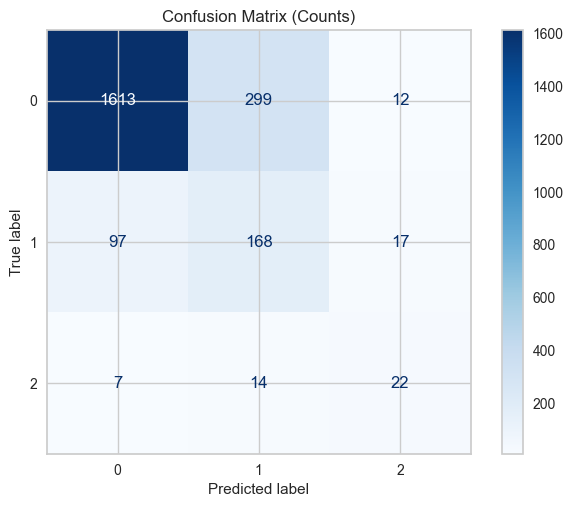

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 혼동행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues", values_format="d")  # values_format="d" → 정수 카운트 표시
plt.title("Confusion Matrix (Counts)")
plt.show()


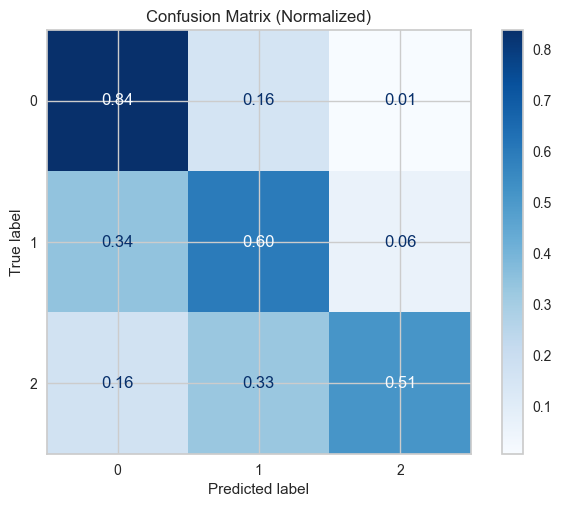

In [ ]:
# 정규화 (row-normalized: 각 클래스별 비율)
cmn = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cmn, display_labels=clf.classes_)
disp.plot(cmap="Blues", values_format=".2f")  # 소수점 둘째자리까지
plt.title("Confusion Matrix (Normalized)")
plt.show()


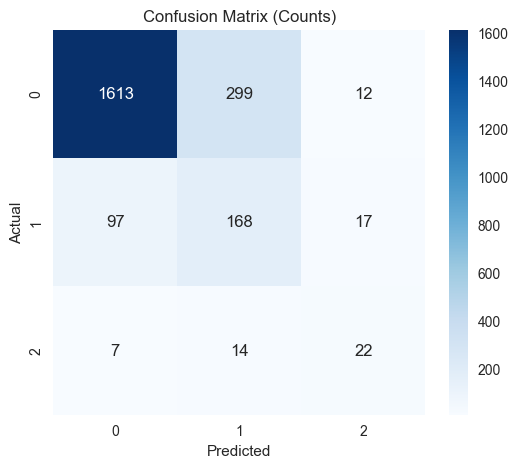

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts)")
plt.show()


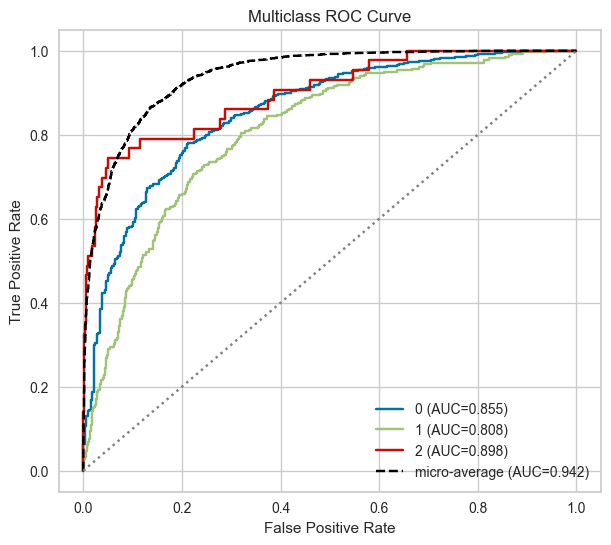

Per-class AUC: {0: 0.8553910123140892, 1: 0.8083015139878924, 2: 0.8983217019123321}
Micro AUC: 0.9416992997826612
Macro AUC: 0.8540047427381046


In [ ]:
# 1) 확률 예측값
y_prob = pipe.predict_proba(X_test)   # shape = (n_samples, n_classes)
classes = pipe.classes_               # 모델이 학습한 클래스들

# 2) 다중클래스 → one-hot 인코딩
y_bin = label_binarize(y_test, classes=classes)

# 3) 클래스별 ROC 곡선과 AUC
fpr, tpr, roc_auc = {}, {}, {}
for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

# 4) micro/macro 평균 AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
roc_auc["macro"] = np.mean([roc_auc[c] for c in classes])

# 5) 시각화
plt.figure(figsize=(7,6))
for c in classes:
    plt.plot(fpr[c], tpr[c], label=f"{c} (AUC={roc_auc[c]:.3f})")

plt.plot(fpr["micro"], tpr["micro"], linestyle="--",
         label=f"micro-average (AUC={roc_auc['micro']:.3f})", color="black")

plt.plot([0, 1], [0, 1], linestyle=":", color="gray")  # 기준선
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

print("Per-class AUC:", {c: roc_auc[c] for c in classes})
print("Micro AUC:", roc_auc["micro"])
print("Macro AUC:", roc_auc["macro"])


In [ ]:
# 1) 전처리 후 피처 이름 가져오기
pre = pipe.named_steps['pre']  # ColumnTransformer
try:
    feat_names = pre.get_feature_names_out()  # ex) ['num__age', 'cat__job_admin', ...]
except AttributeError:
    # sklearn < 1.0 등 구버전 대응 (필요 시 사용자 정의로 대체)
    raise RuntimeError("ColumnTransformer에서 get_feature_names_out을 지원하지 않습니다.")

# 보기 좋게 접두사 제거 (num__/cat__ 등)
feat_names = [name.split("__", 1)[-1] for name in feat_names]

# 2) MI 점수 & 선택 여부
mi_step = pipe.named_steps['mi']  # SelectKBest(mutual_info_classif)
mi_scores = mi_step.scores_                     # 각 변환 피처의 MI 점수
selected_mask = mi_step.get_support()           # True = 선택됨

# 3) DataFrame 정리
mi_df = pd.DataFrame({
    "feature": feat_names,
    "mi": mi_scores,
    "selected": selected_mask
}).sort_values("mi", ascending=False).reset_index(drop=True)

print(mi_df.head(15))          # 상위 15개 확인
print("총 피처 수:", len(mi_df), "/ 선택된 피처 수:", mi_df['selected'].sum())


           feature        mi  selected
0      wsituation8  0.057262      True
1     wsituation11  0.055493      True
2   emp_manaqual_a  0.053659      True
3      wsituation7  0.045362      True
4   emp_comp_ass_a  0.042940      True
5           wstat2  0.041581      True
6   emp_manaqual_e  0.041080      True
7      wsituation3  0.039399      True
8   emp_manaqual_b  0.038978      True
9           wstat5  0.037775      True
10     wsituation4  0.037551      True
11    wsituation13  0.035526      True
12  emp_comp_ass_b  0.035470      True
13          wstat1  0.035337      True
14  emp_comp_ass_f  0.034283      True
총 피처 수: 9178 / 선택된 피처 수: 50


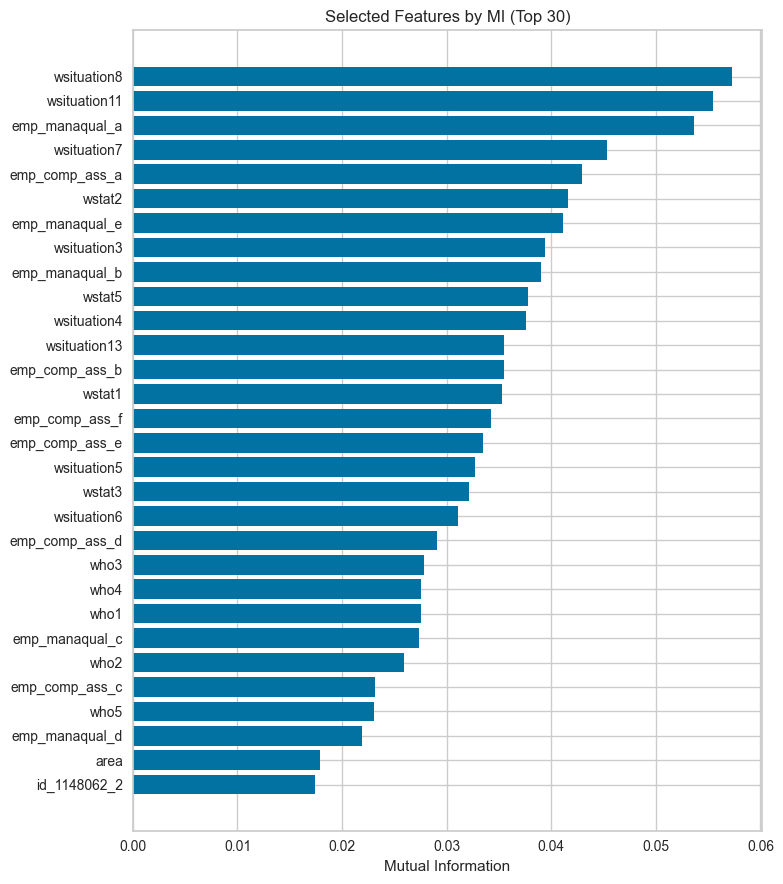

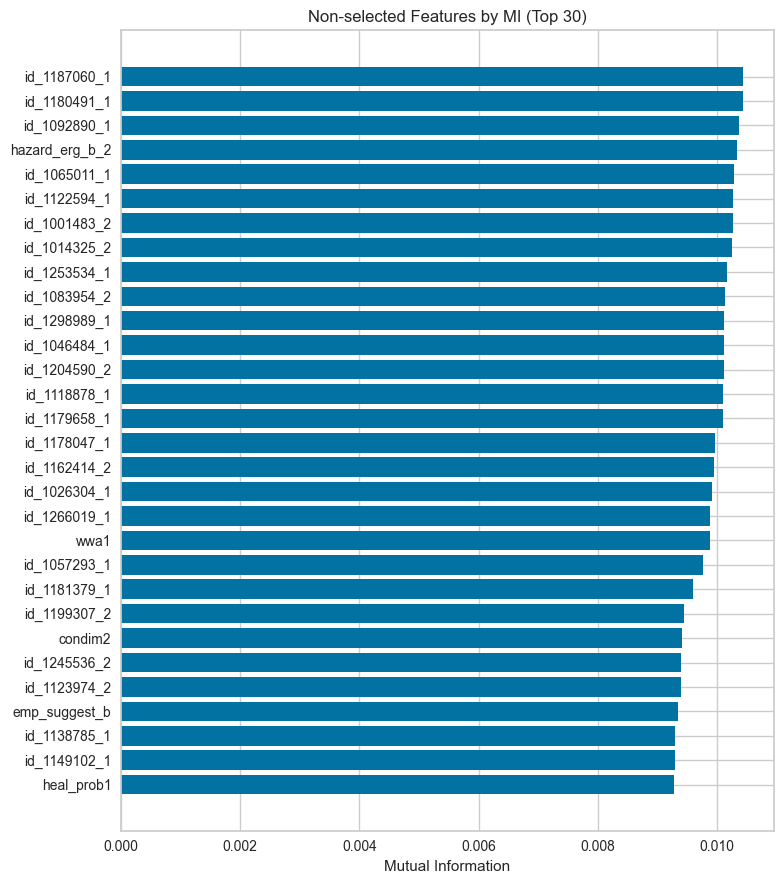

In [ ]:
sel = mi_df[mi_df["selected"]].copy()
not_sel = mi_df[~mi_df["selected"]].copy()

# (1) 선택된 피처만
TOP_SEL = min(30, len(sel))
plt.figure(figsize=(8, max(6, TOP_SEL * 0.3)))
tmp = sel.sort_values("mi", ascending=False).head(TOP_SEL).iloc[::-1]
plt.barh(tmp["feature"], tmp["mi"])
plt.xlabel("Mutual Information")
plt.title(f"Selected Features by MI (Top {TOP_SEL})")
plt.tight_layout()
plt.show()

# (2) 선택되지 않은 피처 중 상위
TOP_NS = min(30, len(not_sel))
plt.figure(figsize=(8, max(6, TOP_NS * 0.3)))
tmp2 = not_sel.sort_values("mi", ascending=False).head(TOP_NS).iloc[::-1]
plt.barh(tmp2["feature"], tmp2["mi"])
plt.xlabel("Mutual Information")
plt.title(f"Non-selected Features by MI (Top {TOP_NS})")
plt.tight_layout()
plt.show()


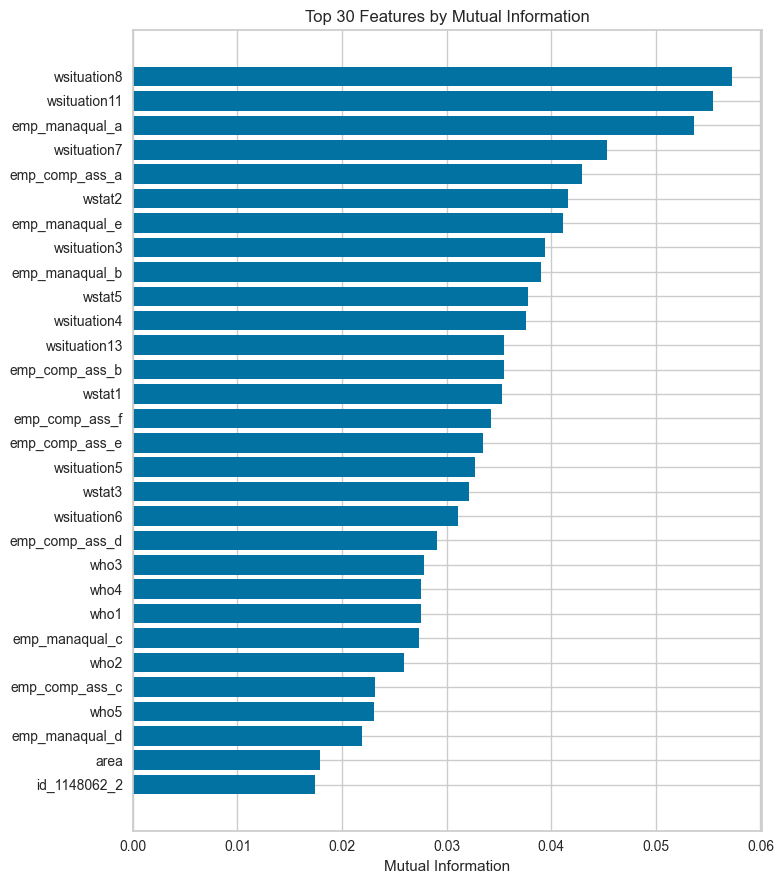

In [ ]:
import matplotlib.pyplot as plt

TOP_N = 30  # 보고 싶은 개수 조정 (예: 20, 30, 50)

topN = mi_df.head(TOP_N).iloc[::-1]  # 가로막대 위아래 순서 예쁘게
plt.figure(figsize=(8, max(6, TOP_N * 0.3)))
plt.barh(topN["feature"], topN["mi"])
plt.xlabel("Mutual Information")
plt.title(f"Top {TOP_N} Features by Mutual Information")
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
feature 이름 뽑기
# -----------------------------
def get_feature_names(preprocessor, num_cols, cat_cols):
    feature_names = []
    # 수치
    feature_names.extend(num_cols)
    # 범주
    ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names.extend(cat_feature_names)
    return feature_names

# Ensure the pipeline is fitted before extracting feature names
if not hasattr(clf.named_steps['pre'], 'named_transformers_'):
    # Fit with some data (X_train or similar)
    clf.fit(X_train, y_train)

final_feature_names = get_feature_names(
    clf.named_steps['pre'], num_cols, cat_cols
)
print("최종 특성 개수:", len(final_feature_names))

최종 특성 개수: 9177


In [ ]:
# -----------------------------
# Feature importance 추출
# -----------------------------
importances = clf.named_steps['model'].feature_importances_

# 길이 맞추기
n = min(len(final_feature_names), len(importances))
feat_imp = pd.DataFrame({
    'feature': final_feature_names[:n],
    'importance': importances[:n]
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(20))   # 상위 20개 중요 피처

              feature  importance
34    emp_boss_gender         806
71        wsituation7         773
72        wsituation8         762
149              who1         704
65         safeinform         688
150              who2         679
68        wsituation5         667
76             wstat3         664
126          wbalance         661
5         wtime_group         628
46            emp_rep         623
77             wstat5         616
12   earning2_group_b         608
127              wwa1         607
75             wstat2         600
147        heal_prob8         600
47       emp_winflu_a         598
164       decla_group         589
74             wstat1         587
3           age_group         581


In [ ]:
import re

# 그룹 매핑 함수 (예: 알파벳/언더바 기준 앞부분만 추출)
def get_group_name(feat):
    # 숫자/인덱스 제거하고 접두사만 추출
    m = re.match(r"([a-zA-Z_]+)", feat)
    if m:
        return m.group(1)
    return feat  # 매칭 안 되면 원래 이름 반환

# 그룹 컬럼 생성
feat_imp["group"] = feat_imp["feature"].apply(get_group_name)

# 그룹별 중요도 합산
group_imp = feat_imp.groupby("group")["importance"].sum().sort_values(ascending=False)

print(group_imp.head(20))


group
wsituation         4688
wstat              3057
who                2909
imte               2184
wwa                1434
heal_prob          1369
woutside            883
condim              834
hazard_erg_a_       824
emp_boss_gender     806
wplace              776
wtime_length        713
safeinform          688
wbalance            661
wtime_group         628
emp_rep             623
earning             608
emp_winflu_a        598
hazard_erg_b_       589
decla_group         589
Name: importance, dtype: int32


In [ ]:
G = 10  # 상위 10개 그룹
group_imp = (feat_imp.groupby("group")["importance"]
             .sum().sort_values(ascending=False))
selected_groups = set(group_imp.head(G).index)
print("선택된 그룹:", selected_groups)


선택된 그룹: {'wsituation', 'heal_prob', 'imte', 'wstat', 'hazard_erg_a_', 'who', 'woutside', 'emp_boss_gender', 'wwa', 'condim'}


In [ ]:
alpha = 0.80  # 누적 80%까지
gi = (feat_imp.groupby("group")["importance"]
      .sum().sort_values(ascending=False))
cum = gi.cumsum() / gi.sum()
selected_groups = set(cum[cum <= alpha].index)
print("선택된 그룹(누적 80%):", selected_groups)


선택된 그룹(누적 80%): {'hazard_erg_d', 'decla_group', 'emp_manaqual_d', 'occ_t', 'emp_comp_ass_c', 'hazard_erg_c', 'wplace', 'income_bal', 'emp_comp_ass_d', 'emp_winflu_a', 'wstat', 'who', 'woutside', 'emp_boss_gender', 'emp_winflu_b', 'wteam', 'emp_manaqual_c', 'earning', 'wtime_group', 'wtime_private', 'comp_female', 'age_group', 'heal_prob', 'hazard_erg_a_', 'decla_c', 'emp_manaqual_a', 'emp_comp_ass_a', 'emp_manaqual_b', 'wbalance', 'wsituation', 'wtime_length', 'income_con', 'imte', 'wtime_ftwork', 'hazard_erg_b_', 'sleep', 'emp_comp_ass_b', 'wwa', 'condim', 'safeinform', 'emp_rep', 'asb'}


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006665 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 470
[LightGBM] [Info] Number of data points in the train set: 8994, number of used features: 100
[LightGBM] [Info] Start training from score -0.156247
[LightGBM] [Info] Start training from score -2.075225
[LightGBM] [Info] Start training from score -3.956818
Selected groups: {'hazard_erg_d', 'decla_group', 'emp_manaqual_d', 'occ_t', 'emp_comp_ass_c', 'hazard_erg_c', 'wplace', 'income_bal', 'emp_comp_ass_d', 'emp_winflu_a', 'wstat', 'who', 'woutside', 'emp_boss_gender', 'emp_winflu_b', 'wteam', 'emp_manaqual_c', 'earning', 'wtime_group', 'wtime_private', 'comp_female', 'age_group', 'heal_prob', 'hazard_erg_a_', 'decla_c', 'emp_manaqual_a', 'emp_comp_ass_a', 'emp_manaqual_b', 'wbalance', 'wsituation', 'wtime_length', 'income_con', 'imte', 'wtime_ftwork', 'hazard_erg_b_', 'sleep', 'emp_comp_ass_b', 'w

In [ ]:
# # (옵션1) 선택 그룹의 모든 피처 사용
# selected_features = (feat_imp
#     .loc[feat_imp["group"].isin(selected_groups)]
#     .sort_values("importance", ascending=False)["feature"].tolist())

# (옵션2) 선택 그룹 내에서 각 그룹별 상위 m개만 사용
m = 5
selected_features = (feat_imp.sort_values("importance", ascending=False)
    .loc[feat_imp["group"].isin(selected_groups)]
    .groupby("group").head(m)["feature"].tolist())

# 전처리 통과한 행렬에서 해당 컬럼만 슬라이싱
Xtr_trans = pipe_model.named_steps['pre'].transform(X_train)
Xte_trans = pipe_model.named_steps['pre'].transform(X_test)
Xtr_df = pd.DataFrame(Xtr_trans, columns=final_feature_names)
Xte_df = pd.DataFrame(Xte_trans, columns=final_feature_names)

# 혹시 선택 목록에 전처리 컬럼에 없는 이름이 섞였을 때 교집합으로 안전하게
selected_features = [c for c in selected_features if c in Xtr_df.columns]

Xtr_sel = Xtr_df[selected_features].values
Xte_sel = Xte_df[selected_features].values

# 새 모델로 재학습/평가
model_sel = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42)
model_sel.fit(Xtr_sel, y_train)
y_pred = model_sel.predict(Xte_sel)

print("Selected groups:", selected_groups)
print("Selected features:", len(selected_features))
print("Test F1(macro):",
      f1_score(y_test, y_pred, average='macro'))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 421
[LightGBM] [Info] Number of data points in the train set: 8994, number of used features: 87
[LightGBM] [Info] Start training from score -0.156247
[LightGBM] [Info] Start training from score -2.075225
[LightGBM] [Info] Start training from score -3.956818
Selected groups: {'hazard_erg_d', 'decla_group', 'emp_manaqual_d', 'occ_t', 'emp_comp_ass_c', 'hazard_erg_c', 'wplace', 'income_bal', 'emp_comp_ass_d', 'emp_winflu_a', 'wstat', 'who', 'woutside', 'emp_boss_gender', 'emp_winflu_b', 'wteam', 'emp_manaqual_c', 'earning', 'wtime_group', 'wtime_private', 'comp_female', 'age_group', 'heal_prob', 'hazard_erg_a_', 'decla_c', 'emp_manaqual_a', 'emp_comp_ass_a', 'emp_manaqual_b', 'wbalance', 'wsituation', 'wtime_length', 'income_con', 'imte', 'wtime_ftwork', 'hazard_erg_b_', 'sleep', 'emp_comp_ass_b', 'ww

In [ ]:
from sklearn.model_selection import cross_validate
from lightgbm import LGBMClassifier
lgb = LGBMClassifier(random_state=42)


In [ ]:
### Feature Selection - Embedded 방식 ###
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from lightgbm import LGBMClassifier

In [ ]:
# ----- 데이터 분리 (예시) -----
# df: 전처리 전 데이터프레임, target 컬럼명은 'burnout60'이라고 가정
X = df_new.drop(columns=['burnout60'], errors='ignore')
y = df_new['burnout60']

In [ ]:
# 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# ----- 컬럼 타입 구분 -----
num_cols = X_train.select_dtypes(include=[np.number, 'bool']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


In [ ]:
# ----- 전처리 파이프라인 -----
# 수치: 평균 대치 → 그대로
num_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])


In [ ]:
# 범주: 최빈 대치 → 원핫 (미지정 카테고리 무시)
cat_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_tf, num_cols),
        ('cat', cat_tf, cat_cols),
    ],
    remainder='drop'
)

In [ ]:
# ----- 모델 -----
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

In [ ]:

# ----- 전체 파이프라인 (전처리 → LGBM) -----
pipe_model = Pipeline(steps=[
    ('pre', preprocess),
    ('model', lgbm)
])


In [ ]:
# ----- 원핫 이후 최종 피처 이름 추출 -----
def get_final_feature_names(preprocessor, num_cols, cat_cols):
    feature_names = []
    # 수치 파이프라인은 이름 그대로
    feature_names.extend(num_cols)

In [ ]:
# ----- SelectFromModel: 중요도 기준 피처 선택 -----
selector = SelectFromModel(
    estimator=pipe_model.named_steps['model'],
    threshold='median',     # 'mean' 또는 수치(예: 0.001)로 조절 가능
    prefit=True
)

In [ ]:
# 먼저 ColumnTransformer를 fit해야 transform이 가능합니다.
# pd.NA → np.nan 변환 (파이프라인에서 처리 가능하게)
X_train_clean = X_train.replace({pd.NA: np.nan})
X_test_clean  = X_test.replace({pd.NA: np.nan})

pipe_model.named_steps['pre'].fit(X_train_clean)

X_train_trans = pipe_model.named_steps['pre'].transform(X_train_clean)
X_test_trans  = pipe_model.named_steps['pre'].transform(X_test_clean)

# Fit the model before using SelectFromModel with prefit=True
pipe_model.named_steps['model'].fit(X_train_trans, y_train)

# Use the same selector instance for both train and test
selector = SelectFromModel(
	estimator=pipe_model.named_steps['model'],
	threshold='median',
	prefit=True
)

X_train_sel = selector.transform(X_train_trans)
X_test_sel  = selector.transform(X_test_trans)

# Ensure X_test_sel has the same number of features as X_train_sel
assert X_train_sel.shape[1] == X_test_sel.shape[1], \
	f"Train and test feature mismatch: {X_train_sel.shape[1]} vs {X_test_sel.shape[1]}"

# Refit the model using only the selected features
sel_model = LGBMClassifier(
	n_estimators=500,
	learning_rate=0.05,
	random_state=42
)
sel_model.fit(X_train_sel, y_train)

# Predict using the model trained on selected features
y_pred_sel = sel_model.predict(X_test_sel)

ValueError: X has 9178 features, but LGBMClassifier is expecting 12148 features as input.

In [ ]:
# ----- 원핫 이후 최종 피처 이름 추출 -----
def get_final_feature_names(preprocessor, num_cols, cat_cols):
	feature_names = []
	# 수치 파이프라인은 이름 그대로
	feature_names.extend(num_cols)
	# 범주형 파이프라인은 원핫 인코더에서 추출
	cat_ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
	cat_feature_names = cat_ohe.get_feature_names_out(cat_cols)
	feature_names.extend(cat_feature_names)
	return feature_names

final_feature_names = get_final_feature_names(preprocess, num_cols, cat_cols)

# ----- 선택된 피처 이름 추출 -----
mask = selector.get_support()
selected_features = [f for f, m in zip(final_feature_names, mask) if m]

print("원핫 후 전체 피처 수:", len(final_feature_names))
print("선택된 피처 수:", len(selected_features))
print("선택된 피처 샘플:", selected_features[:20])


원핫 후 전체 피처 수: 12148
선택된 피처 수: 12148
선택된 피처 샘플: ['area', 'gender', 'wtime_length5', 'age_group', 'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group', 'compsize_group_a', 'wday_week_group_a', 'woutside4_group_a', 'occ_t2_group_a', 'earning2_group_b', 'occ_group_a', 'emp_stat', 'emp_con_term', 'emp_keep', 'emp_own_mgmt', 'emp_fptime', 'emp_wage']


In [ ]:
# 2) Embedded Feature Selection
# Use final_feature_names and selector mask to get selected feature names
selected_mask = selector.get_support()
selected_cols = [f for f, m in zip(final_feature_names, selected_mask) if m]

# Ensure missing values are np.nan (not pd.NA) before transformation
# Add missing columns with np.nan before reindexing
# Ensure all columns required by the preprocessor exist in X_train and X_val
required_cols = set(final_feature_names) | {'id', 'hazard_erg_a', 'hazard_erg_b', 'ctime_group'}
missing_cols_train = required_cols - set(X_train.columns)
missing_cols_val = required_cols - set(X_val.columns)

for col in missing_cols_train:
	X_train[col] = np.nan
for col in missing_cols_val:
	X_val[col] = np.nan

X_train_clean = X_train.replace({pd.NA: np.nan}).reindex(columns=list(required_cols))
X_val_clean   = X_val.replace({pd.NA: np.nan}).reindex(columns=list(required_cols))

# Transform X_train and X_val using the preprocessor
X_train_trans = preprocess.transform(X_train_clean)
X_val_trans   = preprocess.transform(X_val_clean)

# Convert to DataFrame with correct feature names
import pandas as pd
X_train_sel_df = pd.DataFrame(X_train_trans, columns=final_feature_names)[selected_cols].copy()
X_val_sel_df   = pd.DataFrame(X_val_trans, columns=final_feature_names)[selected_cols].copy()

print(f"\n선택된 특성 개수: {len(selected_cols)} / {len(final_feature_names)}")
print("선택된 특성 리스트:", selected_cols)


선택된 특성 개수: 12148 / 12148
선택된 특성 리스트: ['area', 'gender', 'wtime_length5', 'age_group', 'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group', 'compsize_group_a', 'wday_week_group_a', 'woutside4_group_a', 'occ_t2_group_a', 'earning2_group_b', 'occ_group_a', 'emp_stat', 'emp_con_term', 'emp_keep', 'emp_own_mgmt', 'emp_fptime', 'emp_wage', 'emp_stat_sp', 'income_pos_a', 'income_pos_b', 'income_pos_c', 'income_pos_d', 'income_pos_e', 'income_pos_f', 'income_pos_g', 'income_pos_h', 'income_pos_i', 'income_pos_j', 'emp_place', 'emp_suggest_a', 'emp_suggest_b', 'emp_boss_gender', 'emp_manaqual_a', 'emp_manaqual_b', 'emp_manaqual_c', 'emp_manaqual_d', 'emp_manaqual_e', 'emp_comp_ass_a', 'emp_comp_ass_b', 'emp_comp_ass_c', 'emp_comp_ass_d', 'emp_comp_ass_e', 'emp_comp_ass_f', 'emp_rep', 'emp_winflu_a', 'emp_winflu_b', 'emp_winflu_c', 'emp_tra_b', 'emp_tra_c', 'emp_tra_d', 'wsector', 'comp_size_a', 'comp_female', 'comp_sjob', 'ch_tech', 'ch_me', 'ch_ps', 'imte1', 'imte2', 'imte3'

In [ ]:
# 기존 선택된 피처
mask = selector.get_support()
selected_features = [f for f, m in zip(final_feature_names, mask) if m]

# 특정 피처 제외하기
exclude_cols = ['area']   # 뺄 컬럼 리스트
selected_features = [f for f in selected_features if f not in exclude_cols]

print("최종 선택된 피처 수:", len(selected_features))
print("최종 선택된 피처 샘플:", selected_features[:20])


최종 선택된 피처 수: 12147
최종 선택된 피처 샘플: ['gender', 'wtime_length5', 'age_group', 'emp_period_group', 'wtime_group', 'compsize_group', 'woutside_group', 'compsize_group_a', 'wday_week_group_a', 'woutside4_group_a', 'occ_t2_group_a', 'earning2_group_b', 'occ_group_a', 'emp_stat', 'emp_con_term', 'emp_keep', 'emp_own_mgmt', 'emp_fptime', 'emp_wage', 'emp_stat_sp']


In [ ]:
# 3) 선택된 특성으로 재학습
sel_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
sel_model.fit(X_train_sel_df, y_train)

y_pred_sel = sel_model.predict(X_val_sel_df)

acc_sel = accuracy_score(y_val, y_pred_sel)
prec_sel = precision_score(y_val, y_pred_sel, average="weighted")

print("\n=== Selected Features (임베디드 선택) ===")
print(f"Accuracy : {acc_sel:.4f}")
print(f"Precision: {prec_sel:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002526 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 900
[LightGBM] [Info] Number of data points in the train set: 11964, number of used features: 178
[LightGBM] [Info] Start training from score -0.171845
[LightGBM] [Info] Start training from score -1.998859
[LightGBM] [Info] Start training from score -3.798670

=== Selected Features (임베디드 선택) ===
Accuracy : 0.8760
Precision: 0.8587


In [ ]:
from sklearn.metrics import accuracy_score, precision_score

# base model 예측값이 y_pred_base, 실제값이 y_val 또는 y_test라고 가정
# selected features 예측값이 y_pred_sel, 실제값이 y_val 또는 y_test

# base model 성능 계산 (예시: y_pred_base, y_val 사용)
# Ensure y_pred_base and y_val have the same length

# 1. y_val을 숫자형으로 변환 (lv1→0, lv2→1, lv3→2)
label_map = {"lv1": 0, "lv2": 1, "lv3": 2}
y_val_num = y_val.map(label_map)

# 2. y_pred_base도 숫자형이어야 함 (이미 숫자면 그대로 사용)
acc_base = accuracy_score(y_val_num, y_pred_base[:len(y_val_num)])
prec_base = precision_score(y_val_num, y_pred_base[:len(y_val_num)], average="weighted")

# 이미 selected features 성능은 acc_sel, prec_sel로 계산됨

# 4) 성능 비교 표
summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision"],
    "All features": [acc_base, prec_base],
    "Selected features": [acc_sel, prec_sel]
})
print("\n=== 성능 비교 ===")
print(summary)



=== 성능 비교 ===
      metric  All features  Selected features
0   Accuracy      0.738971           0.876003
1  Precision      0.725162           0.858716


In [ ]:
### 시각화
# 1) 중요도 테이블 만들기 (선택됨/제외됨 표시)

# 학습된 모델의 중요도 정리 (LightGBM의 전체 특성 중요도)
imp_df = pd.DataFrame({
    "feature": final_feature_names,
    "importance": lgbm.feature_importances_.astype(float)
}).sort_values("importance", ascending=False)

# 선택 여부 컬럼 추가
support_mask = selector.get_support()
imp_df["selected"] = support_mask

# 중요도 정규화(퍼센트)
imp_df["importance_pct"] = 100 * imp_df["importance"] / (imp_df["importance"].sum() + 1e-12)

imp_df.head(10)


,feature,importance,selected,importance_pct
0,area,1090.0,True,2.422222
73,wsituation13,757.0,True,1.682222
69,wsituation11,755.0,True,1.677778
72,wsituation8,747.0,True,1.660000
35,emp_manaqual_a,710.0,True,1.577778
165,winten2_group,657.0,True,1.460000
13,occ_group_a,653.0,True,1.451111
66,wsituation3,645.0,True,1.433333
6,compsize_group,634.0,True,1.408889
77,wstat5,630.0,True,1.400000


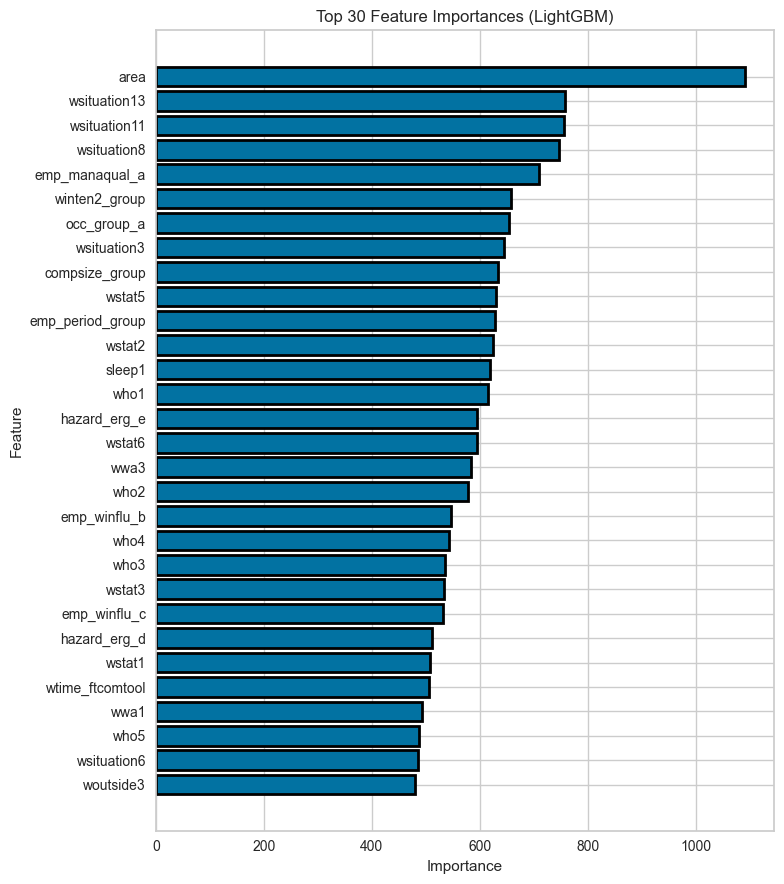

In [ ]:
# 2) 상위 N개 중요도 막대 그래프 (선택된 특성 하이라이트)

import matplotlib.pyplot as plt

N = 30  # 상위 몇 개를 볼지
top = imp_df.head(N).iloc[::-1]  # barh는 뒤집어 주면 보기 좋아짐

plt.figure(figsize=(8, max(6, N*0.3)))
bars = plt.barh(top["feature"], top["importance"])

# 선택된 특성은 두께/외곽선으로 하이라이트
for i, sel in enumerate(top["selected"]):
    if sel:
        bars[i].set_linewidth(2.0)
        bars[i].set_edgecolor("black")  # matplotlib 기본 팔레트 내 색 사용
    else:
        bars[i].set_alpha(0.5)

plt.title(f"Top {N} Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


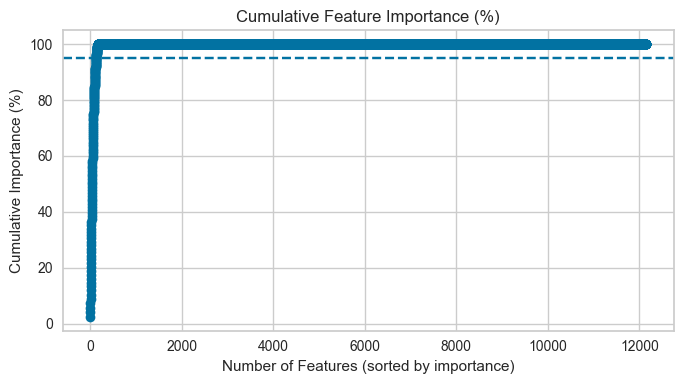

In [ ]:
# 3) 누적 중요도 그래프 (얼마나 줄여도 되는지 감 잡기)

cum = imp_df.copy()
cum["cum_importance_pct"] = cum["importance_pct"].cumsum()

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(cum)+1), cum["cum_importance_pct"], marker="o")
plt.axhline(95, linestyle="--")  # 95% 선
plt.title("Cumulative Feature Importance (%)")
plt.xlabel("Number of Features (sorted by importance)")
plt.ylabel("Cumulative Importance (%)")
plt.tight_layout()
plt.show()


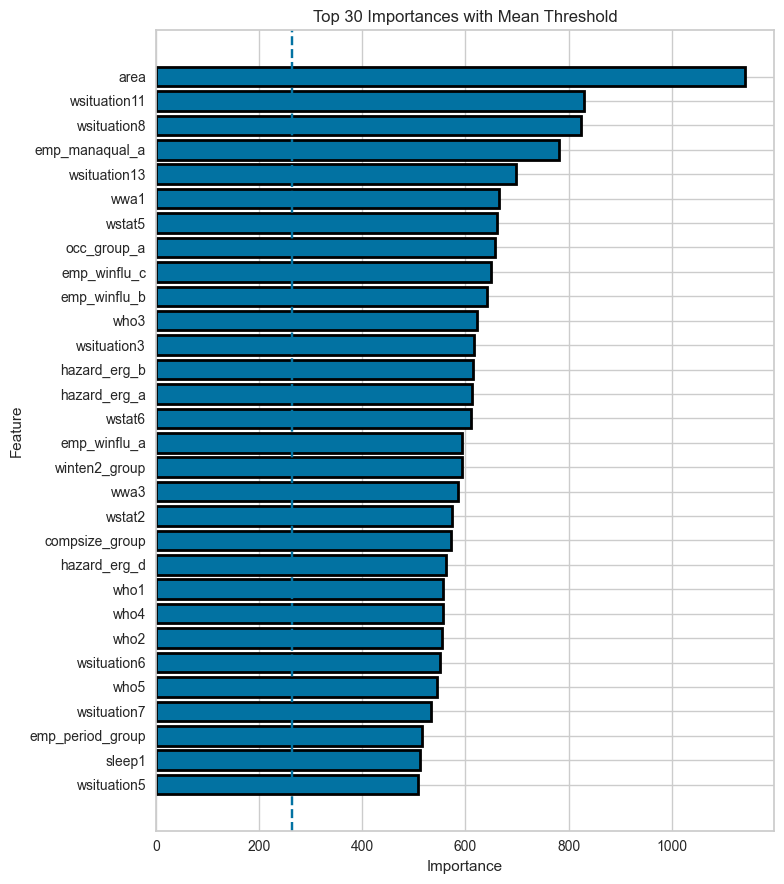

In [ ]:
# 4) 선택 임계값(평균 중요도)과의 비교 시각화

thresh = imp_df["importance"].mean()

plt.figure(figsize=(8, max(6, N*0.3)))
top = imp_df.head(N).iloc[::-1]
bars = plt.barh(top["feature"], top["importance"])

# 평균선
plt.axvline(thresh, linestyle="--")

# 선택된 특성 강조
for i, sel in enumerate(top["selected"]):
    if sel:
        bars[i].set_linewidth(2.0)
        bars[i].set_edgecolor("black")
    else:
        bars[i].set_alpha(0.5)

plt.title(f"Top {N} Importances with Mean Threshold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


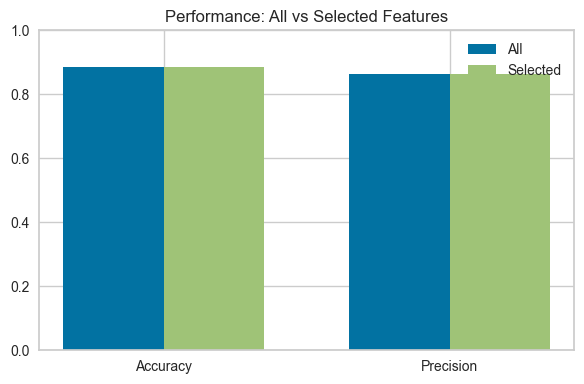

In [ ]:
# 5) 선택 전/후 성능 및 특성 수 비교(요약 바차트)

# 이미 이전 단계에서 계산했을 것으로 가정:
# acc_base, prec_base, acc_sel, prec_sel

labels = ["Accuracy", "Precision"]
all_features_scores = [acc_base, prec_base]
selected_features_scores = [acc_sel, prec_sel]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, all_features_scores, width, label="All")
plt.bar(x + width/2, selected_features_scores, width, label="Selected")
plt.xticks(x, labels)
plt.ylim(0, 1.0)
plt.title("Performance: All vs Selected Features")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 선택된 특성만 따로 보기 (표/리스트)

selected_only = imp_df[imp_df["selected"]].copy().sort_values("importance", ascending=False)
print("선택된 특성 개수:", selected_only.shape[0])
selected_only.head(20)


선택된 특성 개수: 70


,feature,importance,selected,importance_pct
1,area,1141.0,True,2.535556
70,wsituation11,829.0,True,1.842222
73,wsituation8,824.0,True,1.831111
36,emp_manaqual_a,781.0,True,1.735556
74,wsituation13,698.0,True,1.551111
130,wwa1,666.0,True,1.480000
78,wstat5,662.0,True,1.471111
14,occ_group_a,658.0,True,1.462222
50,emp_winflu_c,650.0,True,1.444444
49,emp_winflu_b,641.0,True,1.424444


In [ ]:
!pip install shap


In [ ]:

# 설명할 데이터 (선택된 특성만)
X_val_used = X_val[selected_cols].copy()

# LightGBM용 TreeExplainer
explainer = shap.TreeExplainer(sel_model)

# 큰 데이터면 샘플링(속도/가독성)
N = min(2000, len(X_val_used))
idx = np.random.RandomState(42).choice(len(X_val_used), N, replace=False)
X_val_sample = X_val_used.iloc[idx]

# SHAP 값 계산
# (경고 억제를 원하면 check_additivity=False 사용 가능)
shap_values = explainer.shap_values(X_val_sample)


In [ ]:
# 다중/이진 자동 분기
is_multiclass = isinstance(shap_values, list)

if is_multiclass:
    # 클래스별 SHAP 배열을 쓴다. (예: 평균 절댓값 최대 클래스, 또는 특정 클래스 선택)
    # 1) 평균 절댓값이 가장 큰 클래스를 대표로 시각화 (전반적 경향 확인용)
    mean_abs = [np.abs(v).mean() for v in shap_values]
    target_class = int(np.argmax(mean_abs))
    sv_for_plot = shap_values[target_class]
    class_info = f"(multi-class, class={target_class})"
else:
    sv_for_plot = shap_values
    class_info = "(binary)"


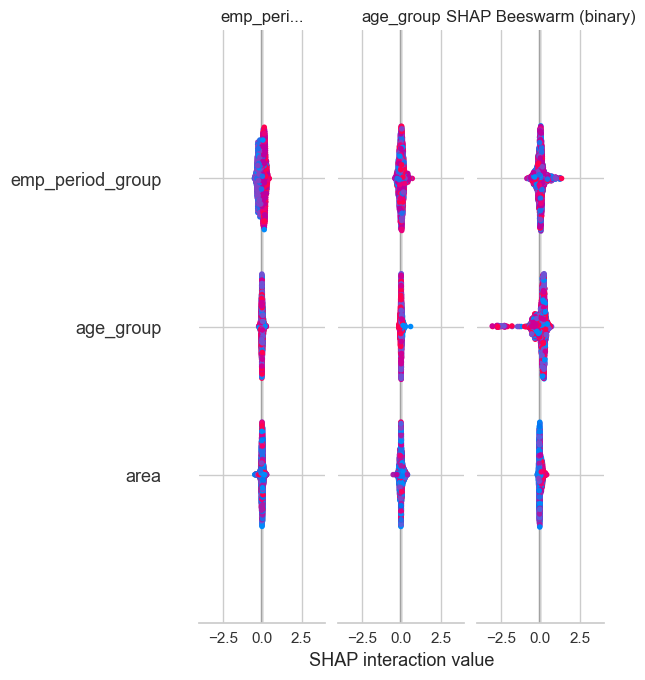

In [ ]:
# Beeswarm (개별 샘플 분포 + 영향)

shap.summary_plot(sv_for_plot, X_val_sample, show=False)
import matplotlib.pyplot as plt
plt.title(f"SHAP Beeswarm {class_info}")
plt.show()


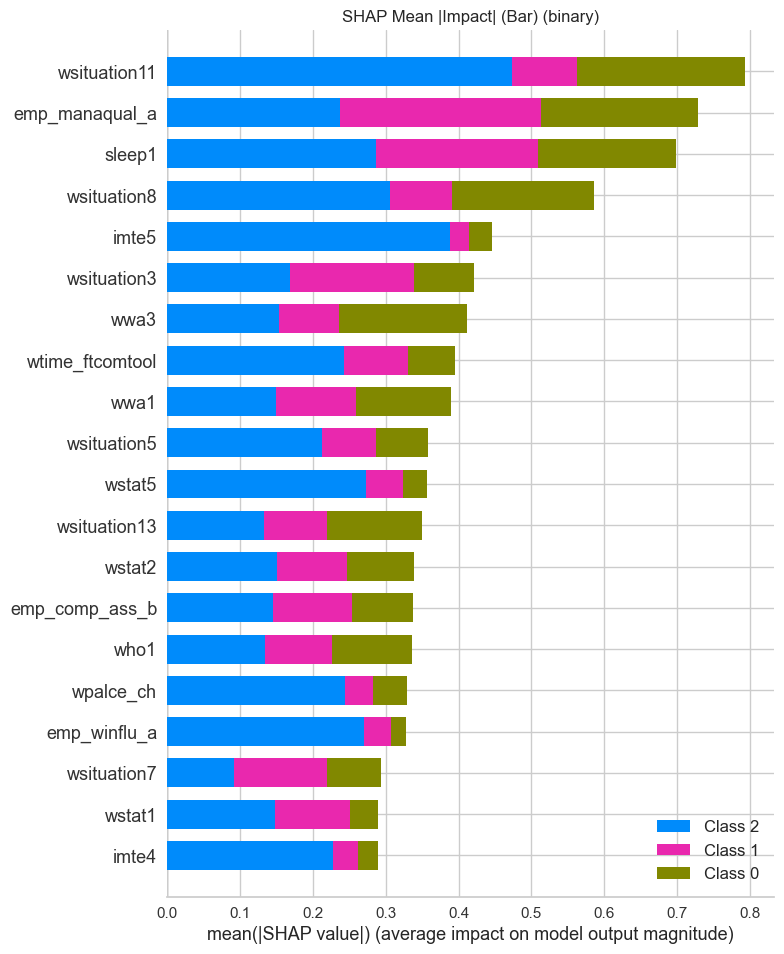

In [ ]:
# Bar (평균 절댓값 중요도)

shap.summary_plot(sv_for_plot, X_val_sample, plot_type="bar", show=False)
import matplotlib.pyplot as plt
plt.title(f"SHAP Mean |Impact| (Bar) {class_info}")
plt.show()


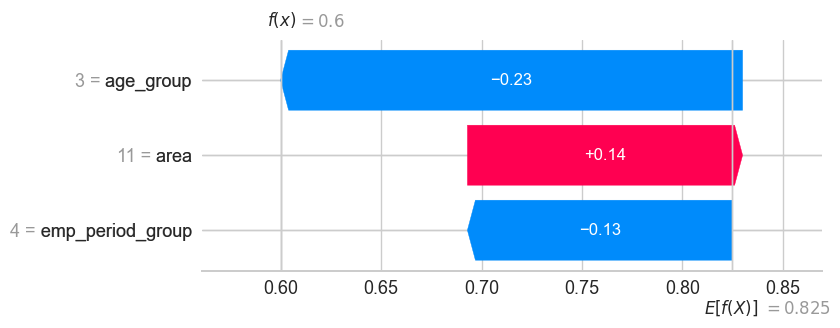

In [ ]:
# 하나의 인스턴스 Waterfall 

i = 0              # 샘플 인덱스
target_class = 0   # 분석할 클래스 인덱스 지정

ex = shap.Explanation(
    values = shap_values[target_class][i],           # 선택 클래스의 shap 값
    base_values = explainer.expected_value[target_class], # 선택 클래스의 expected value (스칼라)
    data = X_val_sample.iloc[i],
    feature_names = X_val_sample.columns
)

shap.plots.waterfall(ex, max_display=20)


In [ ]:
### feature selection + shap

import shap
import re
from scipy import sparse

In [ ]:
# 함수 호출 전에 딱 2줄만 추가
import numpy as np, pandas as pd
X_train = X_train.replace({pd.NA: np.nan})  # NAType → np.nan


In [ ]:
def build_preprocess(X):
    num_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    pre = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ]
    )
    return pre, num_cols, cat_cols

def get_feature_names(pre, num_cols, cat_cols):
    # ColumnTransformer + OneHotEncoder의 출력 이름
    # scikit-learn 1.0+ 에서 제공
    names = []
    # 숫자 특성: 'num__col'
    names += [f'num__{c}' for c in num_cols]
    # 범주 특성: 'cat__원본특성=카테고리'
    if len(cat_cols) > 0:
        ohe = pre.named_transformers_['cat']
        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
        names += [f'cat__{n}' for n in ohe_names]
    return np.array(names)

def _to_dense(X_mat):
    if sparse.issparse(X_mat):
        return X_mat.toarray()
    return X_mat

def _mean_abs_shap_values(explainer, X_mat):
    # shap_values는 버전에 따라 모양이 다름:
    # - 바이너리: (n_samples, n_features)
    # - 멀티클래스: (n_classes, n_samples, n_features) 또는 (n_samples, n_features, n_classes)
    sv = explainer(X_mat, check_additivity=False).values
    if sv is None:
        # 구버전 API 호환
        sv = explainer.shap_values(X_mat)
    sv = np.asarray(sv)

    if sv.ndim == 2:
        # (n_samples, n_features)
        return np.mean(np.abs(sv), axis=0)
    elif sv.ndim == 3:
        # (n_classes, n_samples, n_features) OR (n_samples, n_features, n_classes)
        # 두 경우를 모두 커버
        if sv.shape[0] < 10 and sv.shape[0] != X_mat.shape[0]:
            # (n_classes, n_samples, n_features) 로 가정
            sv_abs = np.abs(sv)  # (C, N, F)
            sv_abs = sv_abs.mean(axis=1)  # (C, F)
            return sv_abs.mean(axis=0)    # (F,)
        else:
            # (n_samples, n_features, n_classes)
            sv_abs = np.abs(sv).mean(axis=2)  # (N, F)
            return sv_abs.mean(axis=0)        # (F,)
    else:
        raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

def _group_to_original_cols(feature_names, importances):
    """
    OHE된 'cat__col=value'들을 원본 'col' 기준으로 합산.
    또한 'num__col'은 그대로 사용.
    """
    base_names = []
    for name in feature_names:
        # 패턴: 'num__col' 또는 'cat__원본=값'
        m = re.match(r'^(?:num|cat)__(.*)$', name)
        inner = m.group(1) if m else name
        # OHE면 '원본=값' → '원본'으로 축약
        if '=' in inner:
            base_names.append(inner.split('=')[0])
        else:
            base_names.append(inner)
    df = pd.DataFrame({'feature_expanded': feature_names,
                       'base_feature': base_names,
                       'importance': importances})
    grouped = df.groupby('base_feature', as_index=False)['importance'].sum()
    grouped.sort_values('importance', ascending=False, inplace=True)
    grouped['rank'] = np.arange(1, len(grouped)+1)
    return grouped[['base_feature', 'importance', 'rank']]

def shap_feature_selection(
    X, y,
    model=None,
    preprocess=None,
    n_splits=5,
    random_state=42,
    top_k=30,
    group_ohe=True
):
    """
    반환:
      - df_importance_expanded: OHE 포함(확장) 피처 중요도
      - df_importance_grouped: 원본 피처 기준 집계 중요도 (group_ohe=True일 때)
      - selected_features: 최종 선택된 top_k 피처 리스트 (원본 피처 기준)
    """
    if model is None:
        model = LGBMClassifier(random_state=random_state)

    if preprocess is None:
        preprocess, num_cols, cat_cols = build_preprocess(X)
    else:
        # 가능하면 자동 추출 시도
        try:
            num_cols = preprocess.transformers_[0][2]
            cat_cols = preprocess.transformers_[1][2]
        except Exception:
            num_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
            cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # 확장 피처 이름/중요도 누적
    expanded_names_global = None
    expanded_importance_sum = None

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        # 전처리 학습 & 변환
        preprocess_fitted = preprocess.fit(X_tr)
        X_tr_t = _to_dense(preprocess_fitted.transform(X_tr))
        X_va_t = _to_dense(preprocess_fitted.transform(X_va))

        # 확장 피처 이름
        feat_names = get_feature_names(preprocess_fitted, num_cols, cat_cols)
        if expanded_names_global is None:
            expanded_names_global = feat_names

        # 모델 학습 (전처리 결과에 직접 학습)
        clf = LGBMClassifier(random_state=random_state)
        clf.fit(X_tr_t, y_tr)

        # SHAP 설명자
        explainer = shap.TreeExplainer(clf, feature_perturbation="tree_path_dependent")
        imp_fold = _mean_abs_shap_values(explainer, X_va_t)  # (n_features,)

        # 길이 체크 (SHAP-이름 불일치 방지)
        if len(imp_fold) != len(feat_names):
            raise ValueError(f"Mismatch: SHAP features={len(imp_fold)} vs names={len(feat_names)}")

        if expanded_importance_sum is None:
            expanded_importance_sum = np.zeros_like(imp_fold, dtype=float)
        expanded_importance_sum += imp_fold

    # 폴드 평균
    expanded_importance_mean = expanded_importance_sum / n_splits
    df_importance_expanded = pd.DataFrame({
        'feature_expanded': expanded_names_global,
        'importance': expanded_importance_mean
    }).sort_values('importance', ascending=False, ignore_index=True)
    df_importance_expanded['rank'] = df_importance_expanded.index + 1

    if group_ohe:
        df_importance_grouped = _group_to_original_cols(
            df_importance_expanded['feature_expanded'].values,
            df_importance_expanded['importance'].values
        )
        selected_features = df_importance_grouped.head(top_k)['base_feature'].tolist()
        return df_importance_expanded, df_importance_grouped, selected_features
    else:
        selected_features = df_importance_expanded.head(top_k)['feature_expanded'].tolist()
        return df_importance_expanded, None, selected_features

# ================================
# 사용 예시
# ================================
# X_train, y_train 이 준비되어 있다고 가정
# 전처리 자동 구성 + LGBM + 5-Fold CV로 SHAP 기반 중요도 집계
# OHE는 원본 피처로 묶어서(top_k=30) 선택
# df_expanded: OHE 확장 피처별 중요도 / df_grouped: 원본 피처별 중요도
# selected: 최종 선택 피처(원본 기준)
# df_grouped를 보고 top_k 조정하면 됨.

# preprocess, _, _ = build_preprocess(X_train)  # (선택) 직접 만들고 싶으면
# model = LGBMClassifier(random_state=42)       # (선택) 하이퍼파라미터 설정 가능

df_expanded, df_grouped, selected = shap_feature_selection(
    X_train, y_train,
    model=None,
    preprocess=None,
    n_splits=5,
    random_state=42,
    top_k=30,
    group_ohe=True
)

print("▶ 확장 피처 상위 10개")
print(df_expanded.head(10))
print("\n▶ 원본 피처(묶음) 상위 10개")
print(df_grouped.head(10))
print("\n▶ 최종 선택 피처 목록 (top_k):")
print(selected)


TypeError: float() argument must be a string or a real number, not 'NAType'